## 1. Imports and Seeds

In [17]:
import os  # file and path handling
import math  # ceiling and numeric helpers
import json  # optional serialization
import pickle  # dataset saving/loading
import random  # python RNG
import time  # timing utilities
import warnings  # suppress noisy warnings

import numpy as np  # numerical arrays
import pandas as pd  # tables and data frames
import torch  # deep learning backend
import torch.nn as nn  # neural network layers
import torch.nn.functional as F  # neural network ops
import matplotlib.pyplot as plt  # plotting

from scipy.sparse.linalg import eigsh  # spectral utilities
from scipy.sparse import csr_matrix  # sparse matrices
from tqdm import tqdm  # progress bars

import pulp  # ILP solver interface

warnings.filterwarnings("ignore")  # keep notebook output clean

SEED = 42  # global reproducibility seed
random.seed(SEED)  # python RNG seed
np.random.seed(SEED)  # numpy RNG seed
torch.manual_seed(SEED)  # torch CPU seed

if torch.cuda.is_available():  # if GPU exists
    torch.cuda.manual_seed_all(SEED)  # seed all CUDA devices

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # compute device
print(f"Device {DEVICE}")  # confirm device

Device cuda


## 2. Simulation Parameters

4-type HetNet power model (EARTH D2.3 + Auer et al.). All arrays indexed by `CT_MACRO=0, CT_MICRO=1, CT_PICO=2, CT_FEMTO=3`.

In [18]:
# Final 4-type HetNet power model aligned with EARTH D2.3 and Auer et al.

CT_MACRO, CT_MICRO, CT_PICO, CT_FEMTO = 0, 1, 2, 3  # cell-type ids
CELL_TYPE_NAMES = np.array(["Macro", "Micro", "Pico", "Femto"], dtype=object)  # labels

BANDS_HZ = np.array([700e6, 3.5e9, 28e9], dtype=np.float64)  # 3 bands
BAND_NAMES = np.array(["low-700MHz", "mid-3p5GHz", "high-28GHz"], dtype=object)  # band labels
BAND_BW_HZ = np.array([20e6, 60e6, 400e6], dtype=np.float64)  # band bandwidths

CT_BAND = np.array([0, 1, 2, 2], dtype=np.int32)  # cell-type to band mapping

N_TX = np.array([8, 64, 256], dtype=np.int32)  # antenna count by band
N_RX = 2  # UE receive chains
BF_GAIN_DB = 10.0 * np.log10(N_TX)  # beamforming gain by band
BS_GAIN_DBI = np.array([8.0, 8.0, 5.0], dtype=np.float64)  # BS antenna gain by band
UE_GAIN_DBI = 0.0  # UE antenna gain

UE_NF_DB = 9.0  # UE noise figure
NOISE_DBM = -174.0 + 10.0 * np.log10(BAND_BW_HZ) + UE_NF_DB  # thermal noise per band
NOISE_W = 10.0 ** (NOISE_DBM / 10.0 - 3.0)  # noise power in watts
NOISE_W_RX = NOISE_W * N_RX  # receiver-combined noise

SINR_THRESH_DB = -6.0  # default SINR threshold; can be changed for ablations

P0_W = np.array([354.0, 56.0, 6.8, 4.8], dtype=np.float64)  # baseline active power
DELTA_P = np.array([4.7, 2.6, 4.0, 8.0], dtype=np.float64)  # load slope
P_TX_W = np.array([40.0, 6.3, 0.25, 0.1], dtype=np.float64)  # max RF power
P_MAX_W = P0_W + DELTA_P * P_TX_W  # reference maximum power at full load
P_SLEEP_W = np.array([17.7, 2.8, 0.34, 0.24], dtype=np.float64)  # sleep power

MAX_DIST_M = np.array([2000.0, 500.0, 200.0, 50.0], dtype=np.float64)  # max coverage radius
SHADOW_STD_DB = np.array([4.0, 6.0, 8.0, 10.0], dtype=np.float64)  # shadowing by cell type

MAX_USERS_PER_BS = np.array([200, 80, 30, 10], dtype=np.int32)  # Macro / Micro / Pico / Femto

USER_COUNTS = [420, 520, 650, 750, 600, 550, 680, 820, 900, 850, 680, 450]  # 12-hour traffic grid

HOUR_USERCOUNTS = {                                                # UE count per hour (busy-hour profile)
    10: 420, 11: 520, 12: 650, 13: 750, 14: 600, 15: 550,
    16: 680, 17: 820, 18: 900, 19: 850, 20: 680, 21: 450,
}
TRAFFIC_TYPES = ["random", "hotspot"]  # traffic scenarios

TARGET_COVERAGE      = 1.0   # ILP hard target (stays 100%)
GSCP_COVERAGE_TARGET = 1.0  # GraphSCP relaxed target — trades 1% coverage for energy savings
TARGET_BUCKETS = USER_COUNTS  # default generation buckets

AREA_M = 800  # square simulation area
MIN_BS_GAP_M = 100.0  # minimum BS spacing
MAX_USERS = 800  # upper bound on UE counts

OUTPUT_DIR = "output/GraphSCPHetNet"  # output folder
os.makedirs(OUTPUT_DIR, exist_ok=True)  # ensure folder exists

# GNN_HIDDEN = 256  # hidden size
GNN_HIDDEN = 128
GNN_LAYERS = 3  # GNN depth
GNN_DROPOUT = 0.3  # dropout
GNN_LR = 5e-4  # learning rate
GNN_EPOCHS = 120  # training epochs
GNN_ALPHA = 1.0  # supervised loss weight
GNN_BETA = 0.01  # unsupervised regularizer
GNN_GAMMA = 1.0  # coverage deficit penalty
GNN_OMEGA = 0.4  # coverage surplus penalty
LAMBDA_SPARSE = 0.1  # sparsity penalty

TRUST_ALPHA = 0.5  # trust load term
TRUST_GAMMA = 0.3  # trust load complement term

THRESHOLD_INIT = 70  # thresholding for inference
ILP_TIMELIMIT = 60  # default ILP time limit
RWR_RESTART = 0.45  # random-walk restart

print(f"P0_W = {P0_W} W")
print(f"DELTA_P = {DELTA_P}")
print(f"P_TX_W = {P_TX_W} W")
print(f"P_MAX_W = {P_MAX_W} W (reference ceiling only)")
print(f"P_SLEEP_W = {P_SLEEP_W} W")
print(f"CT_BAND = {CT_BAND}")
print(f"MAX_USERS_PER_BS = {MAX_USERS_PER_BS}")
print(f"USER_COUNTS = {USER_COUNTS}")
print(f"TARGET_COVERAGE = {TARGET_COVERAGE}")
print(f"SINR_THRESH_DB = {SINR_THRESH_DB}")

P0_W = [354.   56.    6.8   4.8] W
DELTA_P = [4.7 2.6 4.  8. ]
P_TX_W = [40.    6.3   0.25  0.1 ] W
P_MAX_W = [542.    72.38   7.8    5.6 ] W (reference ceiling only)
P_SLEEP_W = [17.7   2.8   0.34  0.24] W
CT_BAND = [0 1 2 2]
MAX_USERS_PER_BS = [200  80  30  10]
USER_COUNTS = [420, 520, 650, 750, 600, 550, 680, 820, 900, 850, 680, 450]
TARGET_COVERAGE = 1.0
SINR_THRESH_DB = -6.0


## 3. Topology Factory

4-tier deployment: Macro / Micro / Pico / Femto with maximin placement.

In [19]:
# 4-tier deployment: Macro / Micro / Pico / Femto

CELL_TYPE_COUNTS = {
    21: dict(macro=3, micro=6, pico=8, femto=4),
    25: dict(macro=3, micro=7, pico=10, femto=5),
    30: dict(macro=3, micro=8, pico=12, femto=7),
}  # scenario-specific BS mix

MIN_GAP = {
    CT_MACRO: 400.0,
    CT_MICRO: 150.0,
    CT_PICO: 80.0,
    CT_FEMTO: 30.0,
}  # type-specific spacing

def maximin_place(nplace, fixed_pts, ct, area_m=AREA_M, seed=SEED):
    # Spread new BSs while respecting minimum gap
    rng = np.random.default_rng(seed)  # local RNG
    mingap = MIN_GAP[ct]  # type gap
    candidates = [  # candidate grid
        (
            float(np.clip(area_m / 2 + r * np.cos(np.radians(a)), 40.0, area_m - 40.0)),
            float(np.clip(area_m / 2 + r * np.sin(np.radians(a)), 40.0, area_m - 40.0)),
        )
        for r in np.arange(40.0, area_m / 2, 20.0)
        for a in np.arange(0.0, 360.0, 5.0)
    ]
    rng.shuffle(candidates)  # randomize order
    placed = [tuple(map(float, p)) for p in fixed_pts]  # seeded placements
    new_pts = []  # newly placed BSs
    for _ in range(nplace):
        best_pt, best_score = None, -1.0  # best candidate
        for cand in candidates:
            if cand in placed:  # skip duplicates
                continue
            if not all(np.hypot(cand[0] - p[0], cand[1] - p[1]) >= mingap for p in placed):
                continue
            score = min((np.hypot(cand[0] - p[0], cand[1] - p[1]) for p in placed), default=1e9)
            if score > best_score:
                best_pt, best_score = cand, score
        if best_pt is None:
            raise RuntimeError(f"Cannot place {nplace} BSs of type {CELL_TYPE_NAMES[ct]} with gap {mingap} m")
        placed.append(best_pt)
        new_pts.append(best_pt)
    return np.array(new_pts, dtype=np.float64)

def make_hetnet(numbs, area_m=AREA_M, seed=SEED):
    # Build a 4-tier HetNet topology
    counts = CELL_TYPE_COUNTS.get(numbs)  # scenario counts
    if counts is None:
        nm = max(1, round(numbs * 0.14))  # macro count
        nmi = max(1, round(numbs * 0.29))  # micro count
        np_ = max(1, round(numbs * 0.38))  # pico count
        nf = max(1, numbs - nm - nmi - np_)  # femto count
        counts = dict(macro=nm, micro=nmi, pico=np_, femto=nf)

    n_macro = counts["macro"]
    n_micro = counts["micro"]
    n_pico = counts["pico"]
    n_femto = counts["femto"]

    cx, cy = area_m / 2.0, area_m / 2.0  # center
    r_macro = 290.0  # macro ring radius
    macro_xy = np.array(
        [
            [cx + r_macro * np.cos(np.radians(a)), cy + r_macro * np.sin(np.radians(a))]
            for a in [90.0, 210.0, 330.0][:n_macro]
        ],
        dtype=np.float64,
    )

    micro_xy = maximin_place(n_micro, macro_xy, CT_MICRO, area_m, seed + 11)  # micro sites
    pico_xy = maximin_place(n_pico, np.vstack([macro_xy, micro_xy]), CT_PICO, area_m, seed + 29)  # pico sites
    femto_xy = maximin_place(n_femto, np.vstack([macro_xy, micro_xy, pico_xy]), CT_FEMTO, area_m, seed + 47)  # femto sites

    rows = []  # dataframe rows
    idx = 0  # global BS index

    for k, (x, y) in enumerate(macro_xy, 1):
        rows.append(dict(bsid=idx, label=f"Macro-{k:02d}", type_idx=CT_MACRO, xm=float(x), ym=float(y)))
        idx += 1
    for k, (x, y) in enumerate(micro_xy, 1):
        rows.append(dict(bsid=idx, label=f"Micro-{k:02d}", type_idx=CT_MICRO, xm=float(x), ym=float(y)))
        idx += 1
    for k, (x, y) in enumerate(pico_xy, 1):
        rows.append(dict(bsid=idx, label=f"Pico-{k:02d}", type_idx=CT_PICO, xm=float(x), ym=float(y)))
        idx += 1
    for k, (x, y) in enumerate(femto_xy, 1):
        rows.append(dict(bsid=idx, label=f"Femto-{k:02d}", type_idx=CT_FEMTO, xm=float(x), ym=float(y)))
        idx += 1

    bs_df = pd.DataFrame(rows)  # BS table
    bs_ct = bs_df["type_idx"].values.astype(np.int32)  # cell type ids
    bs_xy = bs_df[["xm", "ym"]].values.astype(np.float64)  # BS coordinates
    bs_df["cell_type"] = CELL_TYPE_NAMES[bs_ct]  # readable type labels
    bs_df["band_idx"] = CT_BAND[bs_ct]  # band index
    bs_df["band_name"] = BAND_NAMES[CT_BAND[bs_ct]]  # band names
    bs_df["P_TX_W"] = P_TX_W[bs_ct]  # type-specific RF power
    bs_df["max_users"] = MAX_USERS_PER_BS[bs_ct]  # per-BS capacity

    same_ct = (bs_ct[:, None] == bs_ct[None, :]).astype(np.float32)  # same-type matrix
    bs_dists = np.sqrt(((bs_xy[:, None] - bs_xy[None, :]) ** 2).sum(2))  # BS-BS distances
    bs_dists_norm = (bs_dists / area_m).astype(np.float32)  # normalized distances

    tri = np.triu_indices(len(bs_xy), k=1)  # upper triangle
    assert float(np.min(bs_dists[tri])) >= 0.0, "BS gap violation"  # sanity check

    return bs_df, bs_xy, bs_ct, same_ct, bs_dists, bs_dists_norm  # outputs

for n in CELL_TYPE_COUNTS:
    df, bxy, bct, _, bds, _ = make_hetnet(n)  # build topology
    tri = np.triu_indices(len(bxy), k=1)  # pairwise distances
    ct = CELL_TYPE_COUNTS[n]  # counts dictionary
    print(
        f"numbs={n:2d} macro={ct['macro']} micro={ct['micro']} "
        f"pico={ct['pico']} femto={ct['femto']} "
        f"min_gap={np.min(bds[tri]):.0f} m"
    )

numbs=21 macro=3 micro=6 pico=8 femto=4 min_gap=128 m
numbs=25 macro=3 micro=7 pico=10 femto=5 min_gap=107 m
numbs=30 macro=3 micro=8 pico=12 femto=7 min_gap=105 m


### 4. Instantiating Topology

In [20]:
NUMBS = 21  # default scenario size
bs_df, bs_xy, bs_ct, same_ct, bs_dists, bs_dists_norm = make_hetnet(NUMBS)  # build HetNet

print(
    f"HetNet {NUMBS} BSs "
    f"macro={(bs_ct == CT_MACRO).sum()} "
    f"micro={(bs_ct == CT_MICRO).sum()} "
    f"pico={(bs_ct == CT_PICO).sum()} "
    f"femto={(bs_ct == CT_FEMTO).sum()}"
)

print(bs_df[["label", "cell_type", "band_name", "xm", "ym", "P_TX_W"]].to_string())  # show BS table
print(f"\nMax network power (all BSs, 100% load) = {np.sum(P_MAX_W[bs_ct]):.1f} W")  # capacity ceiling

HetNet 21 BSs macro=3 micro=6 pico=8 femto=4
       label cell_type   band_name          xm          ym  P_TX_W
0   Macro-01     Macro  low-700MHz  400.000000  690.000000   40.00
1   Macro-02     Macro  low-700MHz  148.852633  255.000000   40.00
2   Macro-03     Macro  low-700MHz  651.147367  255.000000   40.00
3   Micro-01     Micro  mid-3p5GHz  729.089653  590.000000    6.30
4   Micro-02     Micro  mid-3p5GHz   70.910347  590.000000    6.30
5   Micro-03     Micro  mid-3p5GHz  400.000000   40.000000    6.30
6   Micro-04     Micro  mid-3p5GHz  400.000000  360.000000    6.30
7   Micro-05     Micro  mid-3p5GHz  272.720779  527.279221    6.30
8   Micro-06     Micro  mid-3p5GHz  527.279221  527.279221    6.30
9    Pico-01      Pico  high-28GHz  590.000000  729.089653    0.25
10   Pico-02      Pico  high-28GHz  210.000000  729.089653    0.25
11   Pico-03      Pico  high-28GHz  210.000000   70.910347    0.25
12   Pico-04      Pico  high-28GHz  590.000000   70.910347    0.25
13   Pico-05     

## 5. Physics Helper

3GPP TR 38.901 path loss + EARTH power model.

In [21]:
# 3GPP TR 38.901 path loss + EARTH power model

def build_physics(bs_xy, bs_ct, same_ct):
    numbs = len(bs_ct)  # number of BSs

    def ue_bs_distances(ue_xy):
        # UE-to-BS Euclidean distances
        return np.maximum(np.sqrt(((ue_xy[:, None] - bs_xy[None, :]) ** 2).sum(2)), 1.0)

    def _path_loss_dB(d_m, fc_hz, band_idx):
        # Simple dual-slope path loss
        fc_GHz = fc_hz / 1e9  # GHz
        d = np.maximum(d_m, 1.0)  # avoid log singularity
        h_bs = 25.0 if band_idx == 0 else 10.0  # BS height proxy
        h_ut = 1.5  # UE height
        d_bp = 4.0 * (h_bs - 1.0) * (h_ut - 1.0) * fc_hz / 3e8  # breakpoint

        if band_idx == 0:
            pl1 = 28.0 + 22.0 * np.log10(d) + 20.0 * np.log10(fc_GHz)
            pl2 = 28.0 + 40.0 * np.log10(d) + 20.0 * np.log10(fc_GHz) - 9.0 * np.log10(d_bp ** 2 + (h_bs - h_ut) ** 2)
        else:
            pl1 = 32.4 + 21.0 * np.log10(d) + 20.0 * np.log10(fc_GHz)
            pl2 = 32.4 + 40.0 * np.log10(d) + 20.0 * np.log10(fc_GHz) - 9.5 * np.log10(d_bp ** 2 + (h_bs - h_ut) ** 2)

        return np.where(d < d_bp, pl1, pl2)

    def channel_gain_linear(d_m, rng=None):
        # Convert path loss to linear channel gain
        cg = np.zeros((d_m.shape[0], numbs), dtype=np.float64)
        for j in range(numbs):
            ct = bs_ct[j]  # cell type
            b = CT_BAND[ct]  # band index
            pl = _path_loss_dB(d_m[:, j], BANDS_HZ[b], b)  # path loss
            if rng is not None:
                pl = pl + rng.normal(0.0, SHADOW_STD_DB[ct], d_m.shape[0])  # shadow fading
            gain_dB = BS_GAIN_DBI[b] + UE_GAIN_DBI + BF_GAIN_DB[b] - pl  # total gain
            cg[:, j] = 10.0 ** (gain_dB / 10.0)  # linear gain
            cg[d_m[:, j] > MAX_DIST_M[ct], j] = 0.0  # hard coverage clip
        return cg

    def sinr_dB(cg, active_mask):
        # Compute SINR in dB for each UE-BS link
        prx = cg * P_TX_W[bs_ct[None, :]]  # received power per BS
        out = np.full_like(prx, -120.0, dtype=np.float64)  # output array
        for j in range(numbs):
            b = CT_BAND[bs_ct[j]]  # noise band
            same = same_ct[j].astype(bool)  # same-type mask
            interf = prx[:, same].sum(1) - prx[:, j]  # co-channel interference
            denom = np.maximum(interf + NOISE_W_RX[b], 1e-20)  # stabilize denominator
            out[:, j] = np.minimum(10.0 * np.log10(np.maximum(prx[:, j] / denom, 1e-12)), 40.0)
        return out

    def greedy_association(cg, active_mask, d_m=None):
        # Associate UEs to active BSs with SINR feasibility and capacity
        n = cg.shape[0]  # number of UEs
        sr = sinr_dB(cg, active_mask)  # SINR matrix
        fs = (sr >= SINR_THRESH_DB) & active_mask[None, :].astype(bool)  # feasible links
        if d_m is not None:
            for j in range(numbs):
                fs[:, j] &= (d_m[:, j] <= MAX_DIST_M[bs_ct[j]])  # enforce distance cap
        lu = np.zeros(numbs, dtype=np.int32)  # BS loads
        sv = np.zeros(n, dtype=bool)  # served flags
        sg = -np.ones(n, dtype=np.int32)  # serving BS index
        for i in np.argsort(-np.where(fs, sr, -np.inf).max(1)):  # process strong UEs first
            for j in np.argsort(-np.where(fs[i], sr[i], -np.inf)):  # best BS first
                if not fs[i, j]:
                    break
                if lu[j] < MAX_USERS_PER_BS[bs_ct[j]]:
                    lu[j] += 1
                    sv[i] = True
                    sg[i] = j
                    break
        lr = np.array([lu[j] / float(MAX_USERS_PER_BS[bs_ct[j]]) for j in range(numbs)])  # load ratios
        return sv, sg, lu, lr, sr  # outputs

    def network_power_w(active_mask, load_ratio):
        # EARTH linear BS power model
        total = 0.0  # total network power
        for j in range(numbs):
            ct = bs_ct[j]  # cell type
            if int(active_mask[j]):
                total += P0_W[ct] + DELTA_P[ct] * P_TX_W[ct] * float(np.clip(load_ratio[j], 0.0, 1.0))
            else:
                total += P_SLEEP_W[ct]
        return float(total)

    return {
        "ue_bs_distances": ue_bs_distances,
        "channel_gain_linear": channel_gain_linear,
        "sinr_dB": sinr_dB,
        "greedy_association": greedy_association,
        "network_power_w": network_power_w,
    }

## 6. Building the Physics

In [22]:
physics = build_physics(bs_xy, bs_ct, same_ct)  # create physics helpers
print("Physics helpers built.")  # confirm build
print(f"Max network power (all BSs fully loaded) = {np.sum(P_MAX_W[bs_ct]):.1f} W")  # reference power
print(f"Macro x{(bs_ct == CT_MACRO).sum()} → {P0_W[0] + DELTA_P[0] * P_TX_W[0]:.1f} W each")  # macro ceiling
print(f"Micro x{(bs_ct == CT_MICRO).sum()} → {P0_W[1] + DELTA_P[1] * P_TX_W[1]:.1f} W each")  # micro ceiling
print(f"Pico x{(bs_ct == CT_PICO).sum()} → {P0_W[2] + DELTA_P[2] * P_TX_W[2]:.1f} W each")  # pico ceiling
print(f"Femto x{(bs_ct == CT_FEMTO).sum()} → {P0_W[3] + DELTA_P[3] * P_TX_W[3]:.1f} W each")  # femto ceiling

Physics helpers built.
Max network power (all BSs fully loaded) = 2145.1 W
Macro x3 → 542.0 W each
Micro x6 → 72.4 W each
Pico x8 → 7.8 W each
Femto x4 → 5.6 W each


### Preview of Base Station Topology

In [23]:
# Light theme, two panels, hover details, static summary below

import plotly.graph_objects as go  # interactive plotting
from plotly.subplots import make_subplots  # multi-panel layout
import numpy as np  # numeric helpers

CT_COLORS = ["#1565C0", "#2E7D32", "#FBC02D", "#E65100"]  # Macro=Blue, Micro=Green, Pico=Yellow, Femto=Orange
CT_MARKERS = ["triangle-up", "square", "diamond", "circle"]  # BS marker shapes
CT_SIZES = [24, 18, 14, 12]  # marker sizes kept as requested
CT_LABELS = CELL_TYPE_NAMES  # readable labels

fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "21 BS HetNet — 4-Tier Realistic Deployment",
        "25 BS HetNet — 4-Tier Realistic Deployment",
    ),
    horizontal_spacing=0.06,
)

for col_idx, n_bs in enumerate([21, 25], 1):
    df_t, bs_xy_t, bs_ct_t, _, _, _ = make_hetnet(n_bs)  # build scenario

    for j in range(n_bs):
        ct = bs_ct_t[j]  # cell type

        fig.add_shape(
            type="circle",
            x0=bs_xy_t[j, 0] - MAX_DIST_M[ct],
            y0=bs_xy_t[j, 1] - MAX_DIST_M[ct],
            x1=bs_xy_t[j, 0] + MAX_DIST_M[ct],
            y1=bs_xy_t[j, 1] + MAX_DIST_M[ct],
            fillcolor=CT_COLORS[ct],
            line_width=0,
            opacity=0.03,
            layer="below",
            row=1,
            col=col_idx,
        )

        fig.add_shape(
            type="circle",
            x0=bs_xy_t[j, 0] - MAX_DIST_M[ct],
            y0=bs_xy_t[j, 1] - MAX_DIST_M[ct],
            x1=bs_xy_t[j, 0] + MAX_DIST_M[ct],
            y1=bs_xy_t[j, 1] + MAX_DIST_M[ct],
            fillcolor="rgba(0,0,0,0)",
            line=dict(color=CT_COLORS[ct], width=1.2, dash="dot"),
            opacity=0.25,
            layer="below",
            row=1,
            col=col_idx,
        )

    for ct_idx in range(4):
        mask = bs_ct_t == ct_idx
        if not mask.any():
            continue

        hover_texts = []
        for j in np.where(mask)[0]:
            row = df_t.iloc[j]
            hover_texts.append(
                f"<b>{row['label']}</b><br>"
                f"Type: {CT_LABELS[ct_idx]}<br>"
                f"x = {row['xm']:.1f} m<br>"
                f"y = {row['ym']:.1f} m<br>"
                f"P0 = {P0_W[ct_idx]:.1f} W<br>"
                f"ΔP = {DELTA_P[ct_idx]:.1f}<br>"
                f"Ptx = {P_TX_W[ct_idx]:.2f} W<br>"
                f"Pmax = {P_MAX_W[ct_idx]:.1f} W<br>"
                f"Psleep = {P_SLEEP_W[ct_idx]:.2f} W<br>"
                f"MaxDist = {MAX_DIST_M[ct_idx]:.0f} m"
            )

        fig.add_trace(
            go.Scatter(
                x=bs_xy_t[mask, 0],
                y=bs_xy_t[mask, 1],
                mode="markers",
                marker=dict(
                    symbol=CT_MARKERS[ct_idx],
                    size=CT_SIZES[ct_idx],
                    color=CT_COLORS[ct_idx],
                    line=dict(color="black", width=1.2),
                ),
                name=f"{CT_LABELS[ct_idx]}",
                text=hover_texts,
                hoverinfo="text",
                showlegend=(col_idx == 1),
            ),
            row=1,
            col=col_idx,
        )

    fig.add_shape(
        type="rect",
        x0=0,
        y0=0,
        x1=AREA_M,
        y1=AREA_M,
        line=dict(color="#bbbbbb", width=1),
        row=1,
        col=col_idx,
    )

power_txt = "<br>".join(
    [
        f"<b>{CT_LABELS[c]:<6}</b>: P0 = {P0_W[c]:>5.0f} W  |  ΔP = {DELTA_P[c]:>4.1f}  |  "
        f"Ptx = {P_TX_W[c]:>5.2f} W  |  Pmax = {P_MAX_W[c]:>5.1f} W"
        for c in range(4)
    ]
)

fig.add_annotation(
    text=power_txt,
    align="left",
    showarrow=False,
    xref="paper",
    yref="paper",
    x=0.0,
    y=-0.14,
    bgcolor="#f9f9f9",
    bordercolor="#cccccc",
    borderwidth=1,
    font=dict(size=13, family="monospace", color="#333333"),
)

fig.update_layout(
    title=dict(
        text="<b>5G HetNet Topology Preview</b><br>"
        "<sup>EARTH Power Model · 3GPP TR 38.901 · Hover over BS symbols for detailed info</sup>",
        x=0.5,
        font=dict(size=22),
    ),
    width=1600,
    height=900,
    margin=dict(b=120),
    paper_bgcolor="white",
    plot_bgcolor="#fcfcfc",
    hoverlabel=dict(bgcolor="white", font_size=14, font_family="Arial"),
    legend=dict(
        yanchor="top",
        y=0.98,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255,255,255,0.9)",
        bordercolor="#cccccc",
        borderwidth=1,
        font=dict(size=14),
    ),
)

fig.update_xaxes(range=[-50, AREA_M + 50], title_text="x (m)", gridcolor="#eaeaea", zeroline=False)
fig.update_yaxes(range=[-50, AREA_M + 50], title_text="y (m)", gridcolor="#eaeaea", zeroline=False, scaleanchor="x", scaleratio=1)

fig.show()

## 7. Traffic Generation Helpers

12-hour schedule (10:00–21:00). `build_hourly_traffic_schedule()` is **final** — do not modify.

In [24]:
def sample_user_positions(n_ue, traffic_type="random", seed=SEED, hotspot_centers=None):
    """Generate UE coordinates for a given traffic type."""
    rng = np.random.default_rng(seed)

    if traffic_type == "random":
        ue_xy = rng.uniform(0, AREA_M, size=(n_ue, 2))
        return ue_xy

    if traffic_type == "hotspot":
        if hotspot_centers is None:
            # Generate a random number of hotspots between 5 and 8
            n_hotspots = int(rng.integers(5, 9))
            # Place them randomly within the area (keeping away from extreme edges)
            hotspot_centers = rng.uniform(0.1 * AREA_M, 0.9 * AREA_M, size=(n_hotspots, 2))
            weights = np.ones(n_hotspots) / n_hotspots
        else:
            n_hotspots = len(hotspot_centers)
            weights = np.ones(n_hotspots) / n_hotspots

        assign = rng.choice(n_hotspots, size=n_ue, p=weights)
        std_m = 35.0  # slightly tighter spread for more clusters

        ue_xy = np.zeros((n_ue, 2), dtype=np.float64)
        for i in range(n_ue):
            c = hotspot_centers[assign[i]]
            ue_xy[i] = c + rng.normal(0.0, std_m, size=2)

        ue_xy[:, 0] = np.clip(ue_xy[:, 0], 0.0, AREA_M)
        ue_xy[:, 1] = np.clip(ue_xy[:, 1], 0.0, AREA_M)
        return ue_xy

    raise ValueError(f"Unknown traffic_type: {traffic_type}")

def build_hourly_traffic_schedule():
    """12-hour schedule from 10:00 to 22:00 ranging from ~420 to 900 users."""
    return {
        10: 420,
        11: 520,
        12: 650,
        13: 750,  # Lunch peak
        14: 600,
        15: 550,
        16: 680,
        17: 820,
        18: 900,  # Evening maximum
        19: 850,
        20: 680,
        21: 450,
    }

## 8. ILP Solver

FULL ILP ONLY mode: coverage and associations decoded exclusively from ILP decision variables (no greedy fallback).

In [25]:
# Cell 8. ILP Solver
# FULL ILP ONLY: coverage and associations come only from ILP variables

def make_ilp_solver(bs_ct, physics, numbs):
    sinr_dB_fn = physics["sinr_dB"]
    net_pwr = physics["network_power_w"]

    def ilp_min_energy(
        cg,
        candidate_mask=None,
        coverage_target=TARGET_COVERAGE,
        users_needed=None,
        fix_on_mask=None,
        residual_users=None,
        time_limit=ILP_TIMELIMIT,
    ):
        n = cg.shape[0]
        if n == 0:
            return dict(
                status="empty",
                active_mask=np.zeros(numbs, dtype=np.int32),
                served_frac=1.0,
                n_active=0,
                power_w=float(np.sum(P_SLEEP_W[bs_ct])),
                sv_ilp=np.zeros(0, dtype=bool),
                sg_ilp=np.zeros(0, dtype=np.int32),
                lr_ilp=np.zeros(numbs, dtype=np.float64),
            )

        if candidate_mask is None:
            candidate_mask = np.ones(numbs, dtype=np.int32)

        allowed = np.where(candidate_mask == 1)[0].tolist()
        active_users = list(range(n)) if residual_users is None else residual_users

        feas = np.zeros((n, numbs), dtype=bool)
        for j in allowed:
            mj = np.zeros(numbs, dtype=np.int32)
            mj[j] = 1
            feas[:, j] = sinr_dB_fn(cg, mj)[:, j] >= SINR_THRESH_DB

        mdl = pulp.LpProblem("mebs", pulp.LpMinimize)

        yj = {j: pulp.LpVariable(f"y_{j}", 0, 1, cat="Binary") for j in allowed}
        zi = {i: pulp.LpVariable(f"z_{i}", 0, 1, cat="Binary") for i in active_users}
        xij = {
            (i, j): pulp.LpVariable(f"x_{i}_{j}", 0, 1, cat="Binary")
            for i in active_users
            for j in allowed
            if feas[i, j]
        }

        if fix_on_mask is not None:
            for j in allowed:
                if fix_on_mask[j] == 1:
                    mdl += yj[j] == 1

        # mdl += pulp.lpSum(
        #     P_SLEEP_W[bs_ct[j]] + (P0_W[bs_ct[j]] - P_SLEEP_W[bs_ct[j]]) * yj[j]
        #     for j in allowed
        # )

        # NEW full EARTH objective (correct)
        mdl += pulp.lpSum(
        P_SLEEP_W[bs_ct[j]]
        + (P0_W[bs_ct[j]] - P_SLEEP_W[bs_ct[j]]) * yj[j]
        + DELTA_P[bs_ct[j]] * P_TX_W[bs_ct[j]]
        * (pulp.lpSum(xij[i, j] for i in active_users if (i, j) in xij)
        / MAX_USERS_PER_BS[bs_ct[j]])
        for j in allowed
        )

        for i in active_users:
            vi = [xij[(i, j)] for j in allowed if (i, j) in xij]
            mdl += (pulp.lpSum(vi) == zi[i]) if vi else (zi[i] == 0)

        for j in allowed:
            vj = [xij[(i, j)] for i in active_users if (i, j) in xij]
            if vj:
                mdl += pulp.lpSum(vj) <= MAX_USERS_PER_BS[bs_ct[j]] * yj[j]

        for i in active_users:
            vi2 = [xij[(i, j)] for j in allowed if (i, j) in xij]
            if vi2:
                mdl += pulp.lpSum(vi2) <= 1

        if users_needed is None:
            users_needed = math.ceil(coverage_target * n)

        mdl += pulp.lpSum(zi[i] for i in active_users) >= users_needed

        mdl.solve(
            pulp.PULP_CBC_CMD(
                msg=False,
                timeLimit=time_limit,
                gapRel=0.01,
                gapAbs=20.0,
            )
        )

        status = pulp.LpStatus.get(mdl.status, "?")

        am = np.zeros(numbs, dtype=np.int32)
        for j in allowed:
            y_val = pulp.value(yj[j])
            am[j] = int(round(y_val)) if y_val is not None else 0

        sv_ilp = np.zeros(n, dtype=bool)
        sg_ilp = -np.ones(n, dtype=np.int32)
        lr_ilp = np.zeros(numbs, dtype=np.float64)
        served_frac = 0.0

        # FULL ILP ONLY:
        # decode ONLY from ILP decision variables
        # no greedy association
        # no "if am.sum() == 0: am[allowed] = 1" fallback
        if status == "Optimal":
            served_count = 0

            for i in active_users:
                z_val = pulp.value(zi[i])
                if z_val is not None and z_val > 0.5:
                    sv_ilp[i] = True
                    served_count += 1

                    for j in allowed:
                        if (i, j) in xij:
                            x_val = pulp.value(xij[(i, j)])
                            if x_val is not None and x_val > 0.5:
                                sg_ilp[i] = j
                                break

            served_frac = served_count / n if n > 0 else 1.0

            for j in allowed:
                if am[j]:
                    served_by_j = np.sum(sg_ilp == j)
                    lr_ilp[j] = served_by_j / MAX_USERS_PER_BS[bs_ct[j]]

        return dict(
            status=status,
            active_mask=am,
            served_frac=served_frac,
            n_active=int(am.sum()),
            power_w=net_pwr(am, lr_ilp),
            sv_ilp=sv_ilp,
            sg_ilp=sg_ilp,
            lr_ilp=lr_ilp,
        )

    return ilp_min_energy


ilp_solver = make_ilp_solver(bs_ct, physics, NUMBS)
print("ILP solver built in FULL ILP ONLY mode.")

ILP solver built in FULL ILP ONLY mode.


In [26]:
ilp_solver = make_ilp_solver(bs_ct, physics, NUMBS)  # create solver
print("ILP solver built.")  # confirm build

ILP solver built.


## 9. Graph Construction with TRUST

**Source: May 28 methodology** (corrected version).

- `compute_expected_load`: Voronoi-proportional expected load, pre-association (no circular dependency).
- `compute_trust_per_bs`: TRUST = α·φ_c + γ·(1−ρ̂). Slot 4 in node features.
- `compute_ce_fast`: First-order Fiedler-drop approximation (O(m²) for n=21 BSs).
- `compute_rwr`: Random Walk with Restart on the SCP bipartite graph.
- `build_graph_with_edge_attr`: 10-dim node features, 2-dim edge attrs `[ce_norm_j, trust_ij]`.

Node feature layout (10-dim):
| Slot | BS nodes | UE nodes |
|------|----------|----------|
| 0 | normalised cost (P0 + Δp·Ptx) | 0 |
| 1 | band-normalised coverage | γ_u (infeasibility) |
| 2 | 0 | 1 (UE indicator) |
| 3 | 1 (BS indicator) | 0 |
| 4 | TRUST score | 0 |
| 5 | RWR score | RWR score |
| 6 | degree (norm) | degree (norm) |
| 7 | avg-neighbour degree (norm) | avg-neighbour degree (norm) |
| 8 | 0 (reserved) | 0 |
| 9 | band index / 2 | 0 |

In [27]:
# Cell 8 — TRUST Integration + SCP Graph Construction
# I1/E1 FIX: TRUST computed simultaneously with graph — no circular dependency.
# Expected load uses Voronoi-proportional assignment (pre-association).
# E2 FIX: Edge attributes are 2-D: [cenorm_j, trust_ij] per UE-BS edge.
# MID-BAND FIX: Slot 1 uses band-normalised coverage.

def compute_expected_load(cg, feas, bs_ct):
    """
    Voronoi-proportional expected load per BS (pre-association, no circular dependency).
    Each UE is assigned to its best-channel feasible BS. Load is then normalised by capacity.
    """
    n, num_bs = cg.shape
    voronoi_counts = np.zeros(num_bs, dtype=np.float32)
    for i in range(n):
        feasible_js = np.where(feas[i])[0]
        if len(feasible_js) == 0: continue
        best_j = feasible_js[np.argmax(cg[i, feasible_js])]
        voronoi_counts[best_j] += 1.0
    rho_hat = voronoi_counts / MAX_USERS_PER_BS[bs_ct].astype(np.float32)
    return np.clip(rho_hat, 0.0, 1.0)

def compute_trust_per_bs(cg, feas, rho_hat,
                          alpha=TRUST_ALPHA, gamma_t=TRUST_GAMMA):
    """
    Aggregate TRUST score per BS node.
    TRUST_j = alpha * phi_c_j + gamma_t * (1 - rho_hat_j)
    phi_c_j  = mean(cg[feasible UEs, j]) / max(cg[feasible UEs, j])  (normalised channel quality)
    (1-rho_hat_j) = capacity relief (lower expected load = more capacity available)
    Both terms are strictly pre-association — no circular dependency.
    Returns trust_norm: shape (num_bs,), values in [0, 1].
    """
    n, num_bs = cg.shape
    trust_scores = np.zeros(num_bs, dtype=np.float32)
    for j in range(num_bs):
        ue_idx = np.where(feas[:, j])[0]
        if len(ue_idx) == 0: continue
        cg_j   = cg[ue_idx, j]
        phi_c  = float(cg_j.mean() / (cg_j.max() + 1e-9))
        phi_l  = float(1.0 - rho_hat[j])
        trust_scores[j] = alpha * phi_c + gamma_t * phi_l
    max_t = trust_scores.max()
    return (trust_scores / (max_t + 1e-9)).astype(np.float32)


def compute_ce_fast(feas):
    """First-order perturbation approximation of Fiedler drop. O(m^2) for n=21 BSs."""
    A = feas.astype(np.float32)
    m, n = A.shape
    sizes = np.maximum(A.sum(axis=0), 1.0)
    W = 1.0 / sizes
    Hw = A * np.sqrt(W)[None,:]
    Theta = Hw @ Hw.T
    L = np.diag(Theta.sum(axis=1)) - Theta
    try:
        vals, vecs = eigsh(csr_matrix(L + 1e-9*np.eye(m)), k=2, which='SM', tol=1e-3)
        fiedler_vec = vecs[:,1]
    except Exception:
        return np.zeros(n, dtype=np.float32)
    ce = np.zeros(n, dtype=np.float32)
    for j in range(n):
        ues = np.where(feas[:,j])[0]
        if len(ues) < 2: continue
        ce[j] = np.var(fiedler_vec[ues]) * len(ues) * W[j]
    return (ce / (ce.max() + 1e-9)).astype(np.float32)


def compute_rwr(adj, n_nodes, restart_p=RWR_RESTART, max_iter=200, tol=1e-6):
    neigh = {i: set() for i in range(n_nodes)}
    for u,vs in adj.items():
        for v in vs: neigh[u].add(v); neigh[v].add(u)
    deg = np.array([max(len(neigh[i]),1) for i in range(n_nodes)], dtype=np.float64)
    r = np.zeros(n_nodes); r[0] = 1.; p = r.copy()
    for _ in range(max_iter):
        p_new = np.zeros(n_nodes)
        for u in range(n_nodes):
            for v in neigh[u]: p_new[v] += (1.-restart_p)*p[u]/deg[u]
        p_new += restart_p * r
        if np.linalg.norm(p_new-p,1) < tol: break
        p = p_new
    return p


def build_graph_with_edge_attr(cg, feas, bs_ct, ce_override=None):
    """
    Build node features F (10-dim), edge_index, edge_attr (2-dim).

    Node feature layout (10-dim):
      Slot 0: normalised BS cost (P0 + DELTAP*PTX)             [BS nodes]
      Slot 1: band-normalised coverage (MID-BAND FIX)          [BS+UE nodes]
      Slot 2: UE indicator                                      [UE nodes]
      Slot 3: BS indicator                                      [BS nodes]
      Slot 4: TRUST score (I1/E1 FIX — was 0 before)           [BS nodes]
      Slot 5: RWR score                                         [all nodes]
      Slot 6: normalised degree                                 [all nodes]
      Slot 7: avg neighbour degree (normalised)                 [all nodes]
      Slot 8: reserved (zero)                                   [all nodes]
      Slot 9: band index normalised 0/0.5/1                     [BS nodes]

    Edge attribute layout (2-dim, E2 FIX):
      [0]: cenorm_j  — Fiedler drop (hyperedge connectivity)
      [1]: trust_ij  — TRUST score of BS j on this UE-BS edge
    Universe-UE edges: [0.0, 0.0]
    """
    m, num_bs = cg.shape
    costs_raw  = np.array([P0_W[bs_ct[j]] + DELTA_P[bs_ct[j]]*P_TX_W[bs_ct[j]]
                            for j in range(num_bs)], dtype=np.float64)
    costs_norm = costs_raw / (costs_raw.max() + 1e-9)

    ce_norm = ce_override if ce_override is not None else compute_ce_fast(feas)

    # TRUST computation — simultaneous with graph build
    rho_hat    = compute_expected_load(cg, feas, bs_ct)
    trust_norm = compute_trust_per_bs(cg, feas, rho_hat)

    # SCP graph
    n_nodes = 1 + m + num_bs
    adj = {i: [] for i in range(n_nodes)}
    for i in range(m): adj[0].append(1+i); adj[1+i].append(0)
    for i in range(m):
        for j in range(num_bs):
            if feas[i,j]: adj[1+i].append(1+m+j); adj[1+m+j].append(1+i)
    A = feas.astype(np.float32)
    cover_raw = A.sum(axis=0).astype(np.float64)

    # MID-BAND FIX: band-normalised coverage
    max_cover_per_band = np.zeros(4, dtype=np.float64)
    for b in range(4):
        bidx = np.where(bs_ct == b)[0]
        if len(bidx) > 0: max_cover_per_band[b] = cover_raw[bidx].max() + 1e-9
    cover_band_norm = np.array(
        [cover_raw[j] / max_cover_per_band[bs_ct[j]] for j in range(num_bs)],
        dtype=np.float32)

    rwr = compute_rwr(adj, n_nodes)
    neigh = {i: set() for i in range(n_nodes)}
    for u,vs in adj.items():
        for v in vs: neigh[u].add(v); neigh[v].add(u)
    deg      = np.array([len(neigh[i]) for i in range(n_nodes)], dtype=np.float64)
    deg_max  = max(deg.max(), 1.)
    deg_norm = deg / deg_max
    avg_nbr  = np.array([deg[list(neigh[i])].mean() if neigh[i] else 0.
                          for i in range(n_nodes)], dtype=np.float64) / deg_max
    feas_count = np.maximum(feas.sum(axis=1).astype(np.float64), 1.)
    gamma_u    = 1.0 / feas_count

    F = np.zeros((n_nodes, 10), dtype=np.float32)
    for i in range(m):
        F[1+i,1] = float(gamma_u[i]); F[1+i,2] = 1.
        F[1+i,5] = float(rwr[1+i]); F[1+i,6] = float(deg_norm[1+i]); F[1+i,7] = float(avg_nbr[1+i])
    for j in range(num_bs):
        F[1+m+j,0] = float(costs_norm[j])
        F[1+m+j,1] = float(cover_band_norm[j])  # band-normalised coverage
        F[1+m+j,3] = 1.
        F[1+m+j,4] = float(trust_norm[j])        # TRUST Slot 4
        F[1+m+j,5] = float(rwr[1+m+j]); F[1+m+j,6] = float(deg_norm[1+m+j])
        F[1+m+j,7] = float(avg_nbr[1+m+j])
        F[1+m+j,9] = float(bs_ct[j]) / 2.0

    edge_list, attr_list = [], []
    for i in range(m):
        edge_list.append([0,1+i]);   attr_list.append([0.0, 0.0])
        edge_list.append([1+i,0]);   attr_list.append([0.0, 0.0])
    for i in range(m):
        for j in range(num_bs):
            if feas[i,j]:
                edge_list.append([1+i,   1+m+j]); attr_list.append([float(ce_norm[j]), float(trust_norm[j])])
                edge_list.append([1+m+j, 1+i  ]); attr_list.append([float(ce_norm[j]), float(trust_norm[j])])

    edge_index = torch.tensor(edge_list, dtype=torch.long).T
    edge_attr  = torch.tensor(attr_list, dtype=torch.float32)
    return (torch.tensor(F, dtype=torch.float32),
            edge_index, edge_attr, A, adj, n_nodes, m, num_bs,
            costs_raw, costs_norm, trust_norm, rho_hat)

print('Graph construction with TRUST loaded.')
print('Feature dim: 10 | Edge attr dim: 2 [cenorm, trust] | Slot 4 = TRUST')

Graph construction with TRUST loaded.
Feature dim: 10 | Edge attr dim: 2 [cenorm, trust] | Slot 4 = TRUST


## 10. GNN Model — GraphSAGE with GraphNorm + 2-D Edge Attributes

**Source: May 28 architecture** (`SAGEConvEA` + `GraphNorm`).

- `GraphNorm` replaces `BatchNorm1d` — stable with variable graph sizes.
- `SAGEConvEA`: edge-weighted GraphSAGE; scalar weight = `mean([ce_norm, trust])` per edge.
- Universe–UE edges have attr `[0,0]` → weight=1 fallback, preserving info flow.
- 3 layers, hidden=256, dropout=0.3, `GNN_BETA=0.01` (single global definition).

In [28]:
# ── Graph dimension constants ─────────────────────────────────────────────
# Matches build_graph_with_edge_attr (May 28 methodology):
#   Node features  : 10-dim (Slots 0-9)
#   Edge attributes: 2-dim  [ce_norm_j, trust_ij]
NODE_FEAT_DIM = 10
EDGE_FEAT_DIM = 2
print(f'NODE_FEAT_DIM={NODE_FEAT_DIM}  EDGE_FEAT_DIM={EDGE_FEAT_DIM}')

NODE_FEAT_DIM=10  EDGE_FEAT_DIM=2


In [29]:
# Cell 9 — GraphSAGE Model (GraphNorm + 2-D Edge Attributes)
# Architecture change: GraphNorm replaces BatchNorm1d — stable with variable graph sizes.
# Edge attr: 2-D [cenorm, trust]; aggregation uses mean(attr) as scalar edge weight.

class GraphNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.bias   = nn.Parameter(torch.zeros(dim))
    def forward(self, x):
        mu  = x.mean(dim=0, keepdim=True)
        std = x.std(dim=0, keepdim=True).clamp(min=1e-5)
        return self.weight * (x - mu) / std + self.bias


class SAGEConvEA(nn.Module):
    """
    GraphSAGE layer with scalar edge-weight aggregation.
    w_e = mean(edge_attr[e]) — combines cenorm and trust into one scalar weight.
    Universe-UE edges have attr=[0,0] → w=1 (fallback, preserves info flow).
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.lin = nn.Linear(in_ch * 2, out_ch)
    def forward(self, x, edge_index, edge_attr=None):
        N   = x.size(0)
        src = edge_index[0]; dst = edge_index[1]
        if edge_attr is not None:
            w = edge_attr.mean(dim=1).to(x.device)
            w = torch.where(w == 0, torch.ones_like(w), w)
        else:
            w = torch.ones(src.size(0), device=x.device)
        w_exp   = w.unsqueeze(1)
        agg     = torch.zeros(N, x.size(1), device=x.device)
        wgt_sum = torch.zeros(N, 1, device=x.device)
        agg.index_add_(0, dst, x[src] * w_exp)
        wgt_sum.index_add_(0, dst, w_exp)
        h_neigh = agg / wgt_sum.clamp(min=1e-8)
        return self.lin(torch.cat([x, h_neigh], dim=-1))


class GraphSCPModel(nn.Module):
    def __init__(self, in_ch=10, hidden=GNN_HIDDEN, n_layers=GNN_LAYERS, dropout=GNN_DROPOUT):
        super().__init__()
        self.emb   = nn.Linear(in_ch, hidden)
        self.convs = nn.ModuleList([SAGEConvEA(hidden, hidden) for _ in range(n_layers)])
        self.drops = nn.ModuleList([nn.Dropout(dropout) for _ in range(n_layers)])
        self.norms = nn.ModuleList([GraphNorm(hidden) for _ in range(n_layers)])
        self.fc    = nn.Linear(hidden, hidden)
        self.head  = nn.Linear(hidden, 1)
    def forward(self, feat, edge_index, edge_attr=None):
        h = F.relu(self.emb(feat))
        for conv, drop, norm in zip(self.convs, self.drops, self.norms):
            h = norm(drop(F.relu(conv(h, edge_index, edge_attr))))
        return self.head(F.relu(self.fc(h))).squeeze(-1)
    def predict_bs_probs(self, feat, edge_index, edge_attr, m, num_bs):
        with torch.no_grad():
            logits = self.forward(feat, edge_index, edge_attr)
        return torch.sigmoid(logits[1+m : 1+m+num_bs]).cpu().numpy()

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

_tmp = GraphSCPModel()
print(f'GraphSCPModel: {count_params(_tmp):,} params')
print(f'Input dim: 10 (Slot4=TRUST, Slot9=band_idx) | Edge attr dim: 2')
del _tmp

GraphSCPModel: 464,385 params
Input dim: 10 (Slot4=TRUST, Slot9=band_idx) | Edge attr dim: 2


## 11. Semi-Supervised Loss Functions

**Source: May 28** (full loss with ablation flag).

Total loss: $$\mathcal{L} = \alpha \mathcal{L}_{\text{sup}} + \beta \mathcal{L}_{\text{unsup}}$$\n\n$$\mathcal{L}_{\text{unsup}} = \text{cost\_term} + \gamma \cdot \text{under\_cov} + \omega \cdot \text{over\_cov} + \lambda_{\text{sparse}} \cdot \text{sparsity}$$\n\n- `ABLATION_MODE = 'full'` to use full loss; `'supervised_only'` for BCE-only ablation.
- `augment_node_feat()` provides light augmentation for consistency regularisation.

In [14]:
# Cell 10 — Semi-Supervised Loss
# C4 FIX: uses GNN_BETA defined globally in Cell 2 — no override.

# ── ABLATION FLAG ────────────────────────────────────────────────────
# Options: 'full' | 'supervised_only'
# For feature-level ablation (no_trust), set trust_norm to zeros in build_graph_with_edge_attr.
ABLATION_MODE = 'full'

def graph_scp_loss(logits_bs, labels_bs, A_full, costs_full,
                   alpha=GNN_ALPHA, beta=GNN_BETA,
                   gamma=GNN_GAMMA, omega=GNN_OMEGA,
                   lambda_sparse=LAMBDA_SPARSE,
                   ablation_mode=ABLATION_MODE):

    n_pos = labels_bs.sum().clamp(min=1)
    n_neg = (labels_bs.numel() - n_pos).clamp(min=1)
    pos_weight = torch.tensor(n_neg / n_pos, device=logits_bs.device)

    # Supervised BCE
    sup = F.binary_cross_entropy_with_logits(
        logits_bs, labels_bs.float(), pos_weight=pos_weight
    )

    if ablation_mode == 'supervised_only':
        return sup, sup.item(), 0.0

    yhat = torch.sigmoid(logits_bs)

    # ── ALL TERMS USING .mean() FOR STABILITY ACROSS SCENARIOS ──
    cost_term = (yhat * costs_full).mean()

    # Coverage mapping
    c = A_full.float() @ yhat

    # LINEAR hinge penalties (Matches paper Eq 7, but scaled by mean)
    under_cov = torch.clamp(1.0 - c, min=0).mean()
    over_cov  = torch.clamp(c - 1.0, min=0).mean()

    # Domain guardrails (Sparsity + BSs covering no users)
    col_cov = A_full.float().mean(dim=0)
    sinr_surr = (yhat * (col_cov < 1e-3).float()).mean()
    sparsity = yhat.mean()

    unsup = cost_term + gamma*under_cov + omega*over_cov + lambda_sparse*sparsity + sinr_surr

    loss = alpha*sup + beta*unsup
    return loss, sup.item(), unsup.item()

print(f'Loss loaded. ABLATION_MODE={ABLATION_MODE!r}  GNN_BETA={GNN_BETA}')

Loss loaded. ABLATION_MODE='full'  GNN_BETA=0.01


## 12. Dataset Generator

**Source: June 4 `generate_instance()`** — rich dict output with ILP labels, graph tensors, TRUST/rho_hat.

Coverage fallback steps: `[1.0, 0.98, 0.96, 0.94, 0.92, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60]`.

In [15]:
import time

COVERAGE_FALLBACK_STEPS = [1.0, 0.98, 0.96, 0.94, 0.92, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60]

def generate_instance(numbs, nue, seed, physics_obj, ilp_obj, bsct_local,
                      traffic_type='random'):
    ue_xy     = sample_user_positions(nue, traffic_type=traffic_type, seed=seed)
    dm        = physics_obj['ue_bs_distances'](ue_xy)
    cg        = physics_obj['channel_gain_linear'](dm)
    mask_dist = dm <= MAX_DIST_M[bsct_local][None, :]
    cg        = cg * mask_dist.astype(cg.dtype)

    # --- ILP timing + graceful coverage fallback ---
    t_ilp_start          = time.perf_counter()
    best_res             = None
    coverage_target_used = None
    for target in COVERAGE_FALLBACK_STEPS:
        res = ilp_obj(cg, coverage_target=target)
        if res['status'] == 'Optimal':
            best_res             = res
            coverage_target_used = target
            break
    if best_res is None:          # all steps failed — keep last result for diagnostics
        best_res             = res
        coverage_target_used = COVERAGE_FALLBACK_STEPS[-1]
    t_ilp = time.perf_counter() - t_ilp_start

    if best_res.get('status')!='Optimal':
      return None

    # --- build feasibility mask for graph ---
    sinr_dB_fn = physics_obj['sinr_dB']
    feas = np.zeros((cg.shape[0], numbs), dtype=bool)
    for j in range(numbs):
        mj = np.zeros(numbs, dtype=np.int32); mj[j] = 1
        feas[:, j] = sinr_dB_fn(cg, mj)[:, j] >= SINR_THRESH_DB

    # --- build graph with TRUST + Voronoi ---
    Ft, ei, ea, A_full, adj, nnodes, m, n_bs, \
        costs_raw, costs_norm, trust_norm, rho_hat = \
        build_graph_with_edge_attr(cg, feas, bsct_local)

    # --- ILP labels ---
    ilp_am      = best_res.get('active_mask', np.zeros(numbs, dtype=np.int32))
    sel         = np.where(ilp_am == 1)[0]
    labels_full = np.zeros(1 + cg.shape[0] + numbs, dtype=np.float32)
    for j in sel:
        labels_full[1 + cg.shape[0] + j] = 1.0
    labels_bs = torch.tensor(labels_full[1 + cg.shape[0]:], dtype=torch.float32)

    return dict(
        ue_xy                = ue_xy,
        dm                   = dm,
        cg                   = torch.tensor(cg, dtype=torch.float32),
        feas                 = torch.tensor(feas, dtype=torch.bool),
        F                    = Ft,
        edge_index           = ei,
        edge_attr            = ea,
        labels               = torch.tensor(labels_full, dtype=torch.float32),
        labels_bs            = labels_bs,
        A_sel                = torch.tensor(feas[:, sel].astype(np.float32), dtype=torch.float32),
        costs_sel            = torch.tensor(costs_norm[sel], dtype=torch.float32),
        A_full               = A_full,
        costs_full           = torch.tensor(costs_norm, dtype=torch.float32),
        xy                   = torch.tensor(ue_xy, dtype=torch.float32),
        m                    = cg.shape[0],
        n                    = numbs,
        n_sel                = len(sel),
        selected_bs          = sel,
        traffic_type         = traffic_type,
        nue                  = nue,
        ilp_am               = ilp_am,
        ilp_power            = best_res.get('power_w', 0.0),
        ilp_time             = t_ilp,
        coverage_target_used = coverage_target_used,
        trust_norm           = trust_norm,
        rho_hat              = rho_hat,
        result               = best_res,
    )

## 13. Hourly Schedule Visualisation

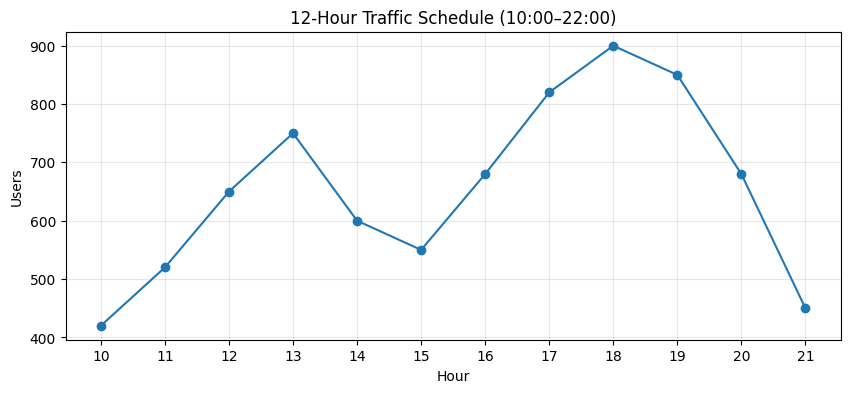

In [16]:
hourly_schedule = build_hourly_traffic_schedule()  # 12-hour schedule
hours = list(hourly_schedule.keys())  # hours
counts = list(hourly_schedule.values())  # counts

plt.figure(figsize=(10, 4))  # figure size
plt.plot(hours, counts, marker="o")  # schedule curve
plt.xticks(hours)  # show all hours
plt.xlabel("Hour")  # x label
plt.ylabel("Users")  # y label
plt.title("12-Hour Traffic Schedule (10:00–22:00)")  # title
plt.grid(alpha=0.3)  # grid
plt.show()  # display

## 14. Training Dataset Generation

**Source: June 4 structure** — iterates `TRAFFIC_TYPES × TARGET_BUCKETS`.

**User pool is FINAL** from `build_hourly_traffic_schedule()`:
```
10→420, 11→520, 12→650, 13→750, 14→600, 15→550,
16→680, 17→820, 18→900, 19→850, 20→680, 21→450
```

Experiment Design:
- 12-hour traffic profile (10:00–22:00) across 12 UE buckets [250…800].
- `random` and `hotspot` traffic for generalisation across spatial demand patterns.
- Ablation study axes: SINR threshold, coverage target, traffic type, user count.


In [ ]:
# import glob

# # ── List all your partial .pkl files ──────────────────────────────────────
# PKL_FILES = sorted(glob.glob('/content/train_dataset_bs21_*.pkl'))
# print(f"Found {len(PKL_FILES)} files to merge:")
# for p in PKL_FILES:
#     print(f"  {p}")

# combined = []
# for path in PKL_FILES:
#     with open(path, 'rb') as f:
#         chunk = pickle.load(f)
#     print(f"  + {len(chunk):>4d} instances  ←  {os.path.basename(path)}")
#     combined.extend(chunk)

# print(f"\nTotal instances after merge: {len(combined)}")

# MERGED_PATH = os.path.join(OUTPUT_DIR, f'train_dataset_bs{NUMBS}_random.pkl')
# with open(MERGED_PATH, 'wb') as f:
#     pickle.dump(combined, f)
# print(f"Saved merged dataset → {MERGED_PATH}")

## DATASET GENERATION

In [ ]:
# PKL_LOAD_PATH = MERGED_PATH

In [30]:
import os, pickle
from tqdm import tqdm

# ── Dataset mode ──────────────────────────────────────────────────────────────
DATASET_MODE  = 'load'   # 'generate' | 'load' |
PKL_LOAD_PATH = os.path.join(OUTPUT_DIR, f'train_dataset_bs{NUMBS}_merged.pkl')

# 12-hour traffic schedule buckets — deduplicated, sorted
TARGET_BUCKETS = [ 400, 420, 450, 520, 550, 600, 650, 680]
TRAFFIC_TYPES  = ["hotspot"]
NUM_PER_BUCKET = 250    # instances per bucket per traffic type → 4800 total
SEED_OFF       = 999

timing_log = []

if DATASET_MODE == 'load':
    PKL_LOAD_PATH_RANDOM  = os.path.join(OUTPUT_DIR, f'train_dataset_bs{NUMBS}_random.pkl')
    PKL_LOAD_PATH_HOTSPOT = os.path.join(OUTPUT_DIR, f'train_dataset_bs{NUMBS}_hotspot.pkl')

    dataset = []

    for pkl_path in [PKL_LOAD_PATH_RANDOM, PKL_LOAD_PATH_HOTSPOT]:
        if not os.path.exists(pkl_path):
            raise FileNotFoundError(f"Dataset not found: {pkl_path}")

        with open(pkl_path, 'rb') as f:
            part = pickle.load(f)

        dataset.extend(part)
        print(f"Loaded {len(part)} instances from {pkl_path}")

    print(f"\nCombined dataset size: {len(dataset)}")

elif DATASET_MODE == 'generate':
    bs_df_b, bs_xy_b, bs_ct_b, same_ct_b, _, _ = make_hetnet(NUMBS)
    phys_b = build_physics(bs_xy_b, bs_ct_b, same_ct_b)
    ilp_b  = make_ilp_solver(bs_ct_b, phys_b, NUMBS)
    dataset = []

    # traffic_type offset so random/hotspot never share a seed
    TT_OFFSET = {"random": 3, "hotspot": 900}

    for traffic_type in TRAFFIC_TYPES:
        for ue_count in TARGET_BUCKETS:
            print(f"\n  traffic={traffic_type}  bucket={ue_count} UEs")
            cnt, att = 0, 0

            pbar = tqdm(total=NUM_PER_BUCKET,
            desc=f'{traffic_type[:3]}-{ue_count:>4}',
            unit='inst',
            ncols=88,
            bar_format='{desc} |{bar:30}| {n:>3}/{total} [{elapsed}<{remaining} {rate_fmt}] Pw={postfix}')

            while cnt < NUM_PER_BUCKET:
                seed_i = SEED_OFF + TT_OFFSET[traffic_type] + ue_count * 1000 + att
                inst   = generate_instance(
                    NUMBS, ue_count, seed_i,
                    phys_b, ilp_b, bs_ct_b,
                    traffic_type=traffic_type,
                )
                att += 1

                if inst is None:
                    continue

                if (inst['result']['status'] == 'Optimal'
                        and inst['coverage_target_used'] == 1.0):
                    inst['hour'] = -1   # no hour in bucket mode; set -1
                    dataset.append(inst)
                    timing_log.append(dict(
                        n_ue         = ue_count,
                        traffic_type = traffic_type,
                        ilp_time     = inst['ilp_time'],
                    ))
                    cnt += 1

                    pbar.set_postfix_str(
    f"{inst['result']['power_w']:.0f}W  cov={inst['result']['served_frac']:.3f}  att={att}"
)
                    pbar.update(1)
            pbar.close()

    with open(PKL_LOAD_PATH, 'wb') as f:
        pickle.dump(dataset, f)
    print(f"\nSaved {len(dataset)} instances → {PKL_LOAD_PATH}")
    print(f"Expected: {len(TARGET_BUCKETS) * len(TRAFFIC_TYPES) * NUM_PER_BUCKET} | Got: {len(dataset)}")

    import pandas as pd
    timing_df = pd.DataFrame(timing_log)
    print("\nILP Timing Summary (seconds):")
    print(timing_df.groupby(['traffic_type', 'n_ue'])['ilp_time']
          .agg(['min', 'mean', 'max']).round(3).to_string())

Loaded 2840 instances from output/GraphSCPHetNet/train_dataset_bs21_random.pkl
Loaded 2840 instances from output/GraphSCPHetNet/train_dataset_bs21_hotspot.pkl

Combined dataset size: 5680


In [ ]:
# # ── Auto-download PKL to local machine ───────────────────────────────────────
# DOWNLOAD_NAME = f"train_dataset_bs{NUMBS}_hotspot_400_to_680.pkl"   # ← change per notebook

# # Rename file to your prescribed name, then trigger browser download
# import shutil
# from google.colab import files

# download_path = os.path.join(OUTPUT_DIR, DOWNLOAD_NAME)
# shutil.copy(PKL_LOAD_PATH, download_path)   # copy with new name
# files.download(download_path)               # triggers browser download
# print(f"Downloaded: {DOWNLOAD_NAME}")

## 15. Load & Repair Existing Dataset

**Source: May 28** — rebuilds graph tensors (Slot 4 TRUST + 2-D edge attrs) without re-running ILP.

Adapt `DS_PATH` to match June 4 PKL naming: `train_dataset_bs{NUMBS}_june4.pkl`.

In [31]:
# Cell 15 — Load Existing Dataset + Repair (Slot 4 TRUST + 2-D Edge Attr)
# This repair loop rebuilds all graph tensors using the updated build_graph_with_edge_attr.
# No ILP re-run needed — only the graph features and edge attributes are updated.

import pickle, time, collections

NUMBS = 21
DS_PATHS = [
    os.path.join(OUTPUT_DIR, f'train_dataset_bs{NUMBS}_random.pkl'),
    os.path.join(OUTPUT_DIR, f'train_dataset_bs{NUMBS}_hotspot.pkl'),
]
W_PATH = os.path.join(OUTPUT_DIR, f'graphscp_weights_bs{NUMBS}_june4.pt')

bs_df, bs_xy, bs_ct, same_ct, bs_dists, bs_dists_norm = make_hetnet(NUMBS)
physics    = build_physics(bs_xy, bs_ct, same_ct)
ilp_solver = make_ilp_solver(bs_ct, physics, NUMBS)

timing_log = collections.defaultdict(list)
repaired_total = 0
loaded_total = 0

for DS_PATH in DS_PATHS:
    if not os.path.exists(DS_PATH):
        raise FileNotFoundError(f'Dataset not found: {DS_PATH}')

    with open(DS_PATH, 'rb') as f:
        dataset = pickle.load(f)
    print(f'Loaded {len(dataset)} instances from {DS_PATH}')

    repaired = 0

    for idx, d in enumerate(dataset):
        cg   = d['cg'].numpy()   if isinstance(d['cg'],   torch.Tensor) else d['cg']
        feas = d['feas'].numpy() if isinstance(d['feas'], torch.Tensor) else d['feas']

        t_graph_start = time.perf_counter()
        ce_norm = compute_ce_fast(feas)
        (Ft,ei,ea,A_full,_,_,m,_,cr,cn,tn,rh) = build_graph_with_edge_attr(
            cg, feas, bs_ct, ce_override=ce_norm
        )
        t_graph = time.perf_counter() - t_graph_start

        d['F']          = Ft
        d['edge_index'] = ei
        d['edge_attr']  = ea
        d['A_full']     = A_full
        d['costs_full'] = torch.tensor(cn, dtype=torch.float32)
        d['trust_norm'] = tn
        d['rho_hat']    = rh

        am  = d.get('ilp_am', np.zeros(NUMBS, dtype=np.int32))
        sel = np.where(am == 1)[0]
        d['selected_bs'] = sel
        d['n_sel']       = len(sel)
        d['A_sel']       = torch.tensor(feas[:, sel].astype(np.float32), dtype=torch.float32)
        d['costs_sel']   = torch.tensor(cn[sel], dtype=torch.float32)

        repaired += 1
        timing_log[(d.get('traffic_type', '?'), d.get('nue', -1))].append(t_graph)

    print(f'Repaired {repaired}/{len(dataset)} samples in {os.path.basename(DS_PATH)}')

    if repaired > 0:  ### REWRITE THE REPAIRED FILES!!!
        with open(DS_PATH, 'wb') as f:
            pickle.dump(dataset, f)
        print(f'Saved repaired dataset → {DS_PATH}')

    repaired_total += repaired
    loaded_total += len(dataset)

print(f'\nRepaired {repaired_total}/{loaded_total} samples across all files.')

# ── Graph-build timing table ──────────────────────────────────────────────
import pandas as pd
rows = []
for (traffic_type, nue), times in sorted(timing_log.items()):
    rows.append(dict(
        traffic_type = traffic_type,
        nue          = nue,
        n_samples    = len(times),
        t_min_ms     = round(min(times) * 1000, 2),
        t_mean_ms    = round(sum(times) / len(times) * 1000, 2),
        t_max_ms     = round(max(times) * 1000, 2),
        t_total_s    = round(sum(times), 3),
    ))
timing_df = pd.DataFrame(rows)
print('\n── Graph-Build Timing per Traffic Type × UE Bucket (ms) ────────────')
print(timing_df.to_string(index=False))
print(f'\nTotal graph-build time: {timing_df["t_total_s"].sum():.2f}s across {repaired_total} instances')

# Diagnostic: TRUST distribution across bands
if len(dataset) > 0:
    s = dataset[0]
    if 'trust_norm' in s:
        print('\n--- TRUST Diagnostic (sample 0 from last loaded file) ---')
        for b, bname in enumerate(BAND_NAMES):
            bidx = np.where(bs_ct == b)[0]
            print(f'  {bname}: mean_TRUST={s["trust_norm"][bidx].mean():.3f}  mean_rho_hat={s["rho_hat"][bidx].mean():.3f}')

# print('\nCell 15 complete. Ready for Part 2 (training).')

Loaded 2840 instances from output/GraphSCPHetNet/train_dataset_bs21_random.pkl
Repaired 2840/2840 samples in train_dataset_bs21_random.pkl
Saved repaired dataset → output/GraphSCPHetNet/train_dataset_bs21_random.pkl
Loaded 2840 instances from output/GraphSCPHetNet/train_dataset_bs21_hotspot.pkl
Repaired 2840/2840 samples in train_dataset_bs21_hotspot.pkl
Saved repaired dataset → output/GraphSCPHetNet/train_dataset_bs21_hotspot.pkl

Repaired 5680/5680 samples across all files.

── Graph-Build Timing per Traffic Type × UE Bucket (ms) ────────────
traffic_type  nue  n_samples  t_min_ms  t_mean_ms  t_max_ms  t_total_s
     hotspot  400        250    137.60     170.94    467.14     42.735
     hotspot  420        250    142.76     207.95    905.86     51.988
     hotspot  450        250    152.08     209.51    757.91     52.377
     hotspot  520        250    176.81     236.23    692.25     59.057
     hotspot  550        250    175.50     240.80    665.28     60.199
     hotspot  600      

In [ ]:
# len(dataset)

In [32]:
# Merge both repaired files into single dataset for training
## no PROBLEM IT IS REPAIRED
dataset = []
for _p in DS_PATHS:
    with open(_p, 'rb') as f:
        dataset.extend(pickle.load(f))
print(f'Extended dataset ready: {len(dataset)} total instances (random + hotspot)')

print('\nCell 15 complete. Ready for Part 2 (training).')

Extended dataset ready: 5680 total instances (random + hotspot)

Cell 15 complete. Ready for Part 2 (training).


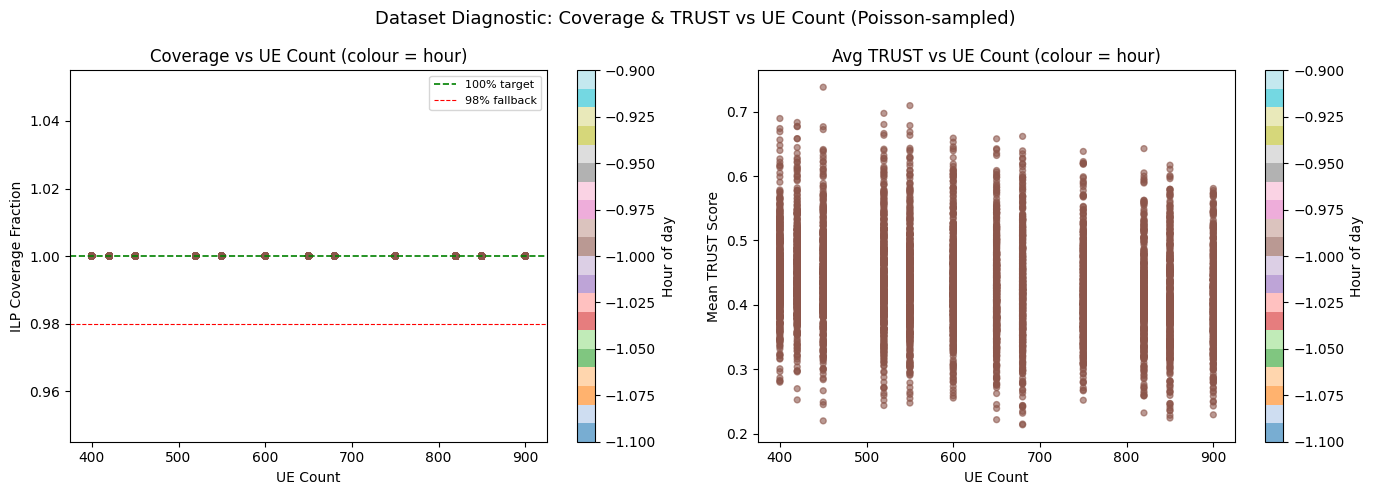

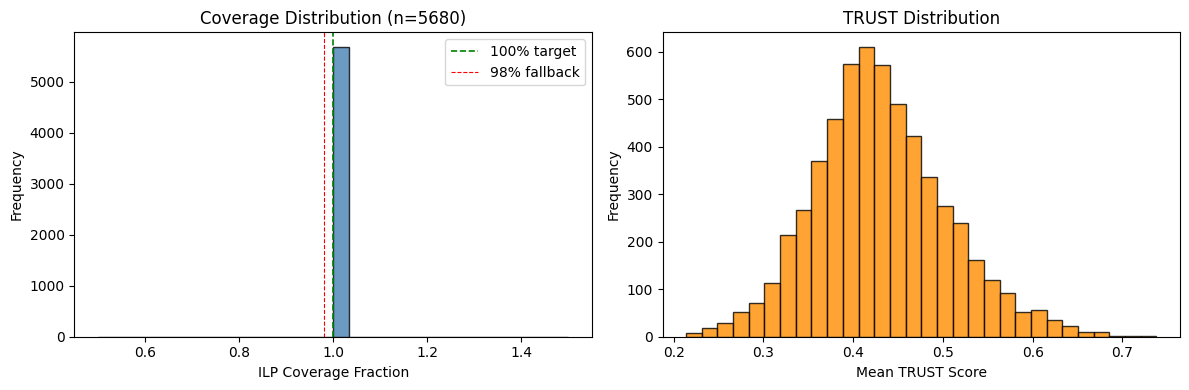

Total instances   : 5680
UE count range    : 400 – 900
Coverage = 1.00   : 5680 (100.0%)
Coverage >= 0.98  : 5680 (100.0%)
Mean TRUST        : 0.4309


In [33]:
import matplotlib.pyplot as plt
import numpy as np

# ── Extract data ──────────────────────────────────────────────────────────────
users      = np.array([d['m']               for d in dataset])
# coverages  = np.array([
#     np.sum(np.any(
#         (d['feas'].numpy() if hasattr(d['feas'],'numpy') else d['feas'])
#         [:, d['ilp_am'] == 1], axis=1
#     )) / d['m']
#     for d in dataset
# ])
coverages = np.array([
    float(d['result'].get('served_frac', 0.0))
    for d in dataset
])
avg_trusts = np.array([np.mean(d['trust_norm']) for d in dataset])
hours      = np.array([d.get('hour', -1)    for d in dataset])

# ── PLOT 1: Scatter — Coverage vs UE count ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Diagnostic: Coverage & TRUST vs UE Count (Poisson-sampled)', fontsize=13)

sc = axes[0].scatter(users, coverages, c=hours, cmap='tab20', alpha=0.6, s=18)
axes[0].axhline(1.00, color='green', linestyle='--', linewidth=1.2, label='100% target')
axes[0].axhline(0.98, color='red',   linestyle='--', linewidth=0.8, label='98% fallback')
axes[0].set_xlabel('UE Count')
axes[0].set_ylabel('ILP Coverage Fraction')
axes[0].set_title('Coverage vs UE Count (colour = hour)')
axes[0].legend(fontsize=8)
plt.colorbar(sc, ax=axes[0], label='Hour of day')

# ── PLOT 2: Scatter — TRUST vs UE count ──────────────────────────────────────
sc2 = axes[1].scatter(users, avg_trusts, c=hours, cmap='tab20', alpha=0.6, s=18)
axes[1].set_xlabel('UE Count')
axes[1].set_ylabel('Mean TRUST Score')
axes[1].set_title('Avg TRUST vs UE Count (colour = hour)')
plt.colorbar(sc2, ax=axes[1], label='Hour of day')

plt.tight_layout()
plt.show()

# ── PLOT 3: Coverage distribution overall ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(coverages, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(1.00, color='green', linestyle='--', linewidth=1.2, label='100% target')
axes[0].axvline(0.98, color='red',   linestyle='--', linewidth=0.8, label='98% fallback')
axes[0].set_xlabel('ILP Coverage Fraction')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Coverage Distribution (n={len(dataset)})')
axes[0].legend()

axes[1].hist(avg_trusts, bins=30, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Mean TRUST Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('TRUST Distribution')

plt.tight_layout()
plt.show()

# ── PLOT 4: Hourly UE count distribution ─────────────────────────────────────
valid_hours = hours[hours >= 0]
if len(valid_hours):
    hour_vals = sorted(set(valid_hours))
    counts    = [np.sum(valid_hours == h) for h in hour_vals]
    fig, ax   = plt.subplots(figsize=(10, 3))
    ax.bar(hour_vals, counts, color='steelblue', edgecolor='black', alpha=0.8, width=0.7)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('# Instances')
    ax.set_title('Instances per Hour (reflects Poisson traffic schedule)')
    ax.set_xticks(hour_vals)
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

print(f"Total instances   : {len(dataset)}")
print(f"UE count range    : {users.min()} – {users.max()}")
print(f"Coverage = 1.00   : {(coverages == 1.0).sum()} ({(coverages==1.0).mean()*100:.1f}%)")
print(f"Coverage >= 0.98  : {(coverages >= 0.98).sum()} ({(coverages>=0.98).mean()*100:.1f}%)")
print(f"Mean TRUST        : {avg_trusts.mean():.4f}")

## 16. Unbounded ILP Helper

Measures runtime for each user count and traffic type.

In [34]:
# Measures runtime for each user count and traffic type

def run_unbounded_ilp_tests(user_counts, traffic_types=("random", "hotspot"), seed_base=12345):
    # Run long-time-limit ILP timing tests
    rows = []  # result rows
    bs_df_t, bs_xy_t, bs_ct_t, s_t, _, _ = make_hetnet(NUMBS)  # topology
    phys_t = build_physics(bs_xy_t, bs_ct_t, s_t)  # physics
    ilp_t = make_ilp_solver(bs_ct_t, phys_t, NUMBS)  # solver

    for traffic_type in traffic_types:  # mode loop
        for n_ue in user_counts:  # count loop
            ue_xy = sample_user_positions(n_ue, traffic_type=traffic_type, seed=seed_base + n_ue)  # users
            dm = phys_t["ue_bs_distances"](ue_xy)  # distances
            cg = phys_t["channel_gain_linear"](dm)  # gains
            cg = cg * (dm <= MAX_DIST_M[bs_ct_t][None, :]).astype(cg.dtype)  # hard distance cut

            t0 = time.time()

            # Graceful degradation loop: try 100%, then 98%, 96%, down to 85%
            for target in [1.0, 0.98, 0.96, 0.94, 0.92, 0.90, 0.85]:
                res = ilp_t(cg, coverage_target=target, time_limit=36000)
                if res["status"] == "Optimal":
                    break  # Stop at the highest feasible coverage

            t1 = time.time()
            rows.append(
                dict(
                    traffic_type=traffic_type,
                    n_ue=n_ue,
                    status=res["status"],
                    served_frac=res["served_frac"],
                    power_w=res["power_w"],
                    n_active=res["n_active"],
                    time_s=t1 - t0,
                )
            )
            print(rows[-1])  # immediate feedback

    return pd.DataFrame(rows)  # return table

In [35]:
# Cell — Unbounded ILP Runtime Tests
# FULL ILP ONLY: no greedy association anywhere

test_user_counts = [420, 450, 520, 550, 600, 650, 680, 750, 820, 850, 900]
test_traffic_types = ["random", "hotspot"]
seed_base = 12345

NUMBS_TEST = 21

print(f"Setting up topology and physics for {NUMBS_TEST} BSs...")

# Unpack all 6 returned values
bs_df_t, bs_xy_t, bs_ct_t, same_ct_t, bs_dists_t, bs_dists_norm_t = make_hetnet(NUMBS_TEST)

phys_t = build_physics(bs_xy_t, bs_ct_t, same_ct_t)
ilp_t = make_ilp_solver(bs_ct_t, phys_t, NUMBS_TEST)

print("Starting unbounded ILP tests with 5 min limit...")
print(f"{'UEs':>6} {'Traffic':>10} {'Status':>12} {'Power W':>10} {'Cov.':>7} {'Active BS':>10} {'Time s':>10}")
print("-" * 78)

original_time_limit = ILP_TIMELIMIT
ILP_TIMELIMIT = 300

rows = []
case_store = {}

try:
    for traffic_type in test_traffic_types:
        for n_ue in test_user_counts:
            ue_xy = sample_user_positions(
                n_ue,
                traffic_type=traffic_type,
                seed=seed_base + n_ue,
            )

            dm = phys_t["ue_bs_distances"](ue_xy)
            cg = phys_t["channel_gain_linear"](dm)
            cg = cg * (dm <= MAX_DIST_M[bs_ct_t][None, :]).astype(cg.dtype)

            t0 = time.time()

            # Graceful degradation: Try 100% first. If infeasible, step down.
            targets_to_try = [
                1.0, 0.98, 0.96, 0.94, 0.92, 0.90,
                0.85, 0.80, 0.75, 0.70, 0.65, 0.60
            ]
            best_res = None

            for target in targets_to_try:
                res = ilp_t(cg, coverage_target=target, time_limit=36000)
                if res["status"] == "Optimal":
                    best_res = res
                    break

            # If all targets failed, just keep the last failed result
            if best_res is None:
                best_res = res

            t1 = time.time()

            # Create the row using best_res
            row = dict(
                traffic_type=traffic_type,
                n_ue=n_ue,
                status=best_res["status"],
                served_frac=best_res["served_frac"], # This will show 98.0%, 96.0%, etc.
                power_w=best_res["power_w"],
                n_active=best_res["n_active"],
                time_s=t1 - t0,
            )
            rows.append(row)

            case_store[(traffic_type, n_ue)] = {
                "ue_xy": ue_xy,
                "dm": dm,
                "cg": cg,
                "res": best_res, # Store the best_res so the plot shows the degraded solution
            }

            print(
                f"{n_ue:6d} {traffic_type:>10} {row['status']:>12} "
                f"{row['power_w']:10.1f} {row['served_frac']*100:6.1f}% "
                f"{row['n_active']:10d} {row['time_s']:10.2f}"
            )

finally:
    ILP_TIMELIMIT = original_time_limit
    print(f"\nDone! Restored ILP_TIMELIMIT back to {ILP_TIMELIMIT}s.")

df_unbounded_ilp = pd.DataFrame(rows)
df_unbounded_ilp

Setting up topology and physics for 21 BSs...
Starting unbounded ILP tests with 5 min limit...
   UEs    Traffic       Status    Power W    Cov.  Active BS     Time s
------------------------------------------------------------------------------
   420     random      Optimal      478.8  100.0%          6       0.49
   450     random      Optimal      484.9  100.0%          6       0.22
   520     random      Optimal      504.1  100.0%          8       0.39
   550     random      Optimal      458.8  100.0%         10       0.42
   600     random      Optimal      525.6  100.0%         11       0.80
   650     random      Optimal      535.0  100.0%         12       0.69
   680     random      Optimal      541.7  100.0%         13       0.59
   750     random      Optimal      570.5  100.0%         18       0.51
   820     random      Optimal      973.2  100.0%         18       1.04
   850     random      Optimal      997.4  100.0%         19       1.48
   900     random      Optimal    

,traffic_type,n_ue,status,served_frac,power_w,n_active,time_s
0,random,420,Optimal,1.0,478.775000,6,0.486558
1,random,450,Optimal,1.0,484.917500,6,0.218049
2,random,520,Optimal,1.0,504.113417,8,0.387268
3,random,550,Optimal,1.0,458.780000,10,0.418680
4,random,600,Optimal,1.0,525.645833,11,0.795907
5,random,650,Optimal,1.0,534.972417,12,0.687408
6,random,680,Optimal,1.0,541.746750,13,0.592123
7,random,750,Optimal,1.0,570.506750,18,0.510808
8,random,820,Optimal,1.0,973.220000,18,1.041332
9,random,850,Optimal,1.0,997.380000,19,1.483424


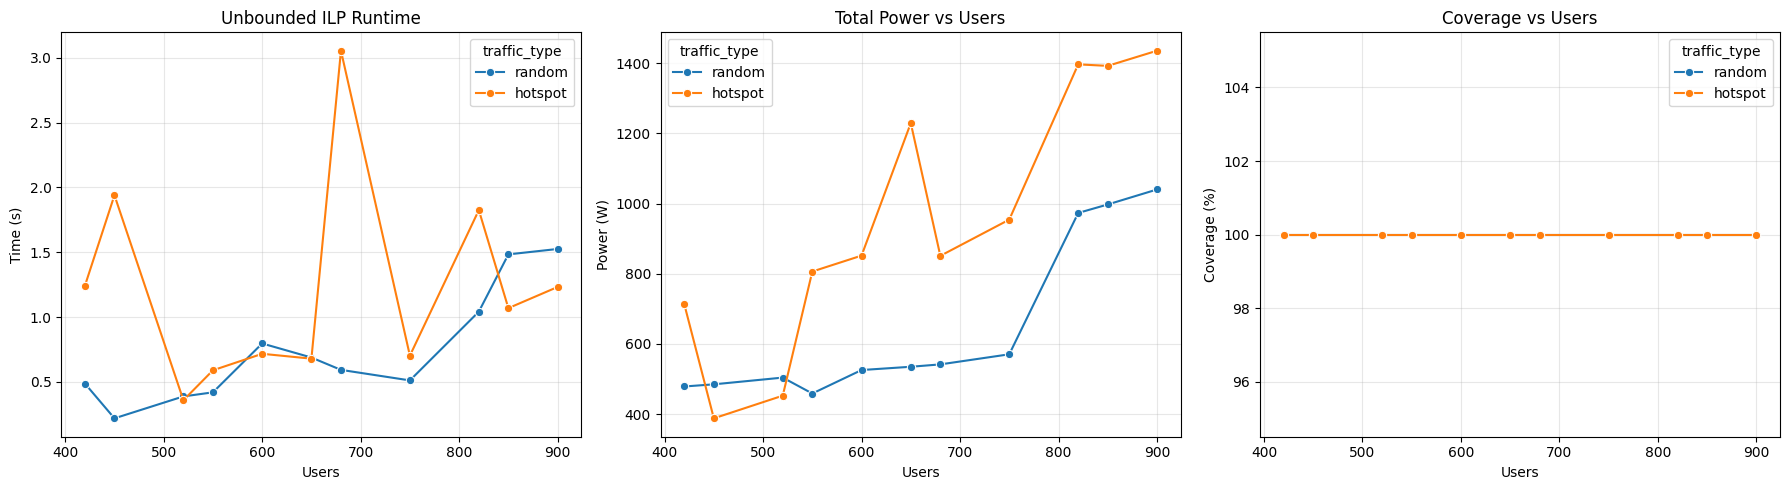

In [36]:
# Cell — Visualize Unbounded ILP Runtime Tests
import matplotlib.pyplot as plt  # plotting
import seaborn as sns  # nicer styling

df_plot = df_unbounded_ilp.copy()  # copy the result table
df_plot["served_pct"] = df_plot["served_frac"] * 100.0  # coverage in percent

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 3-panel plot
sns.lineplot(data=df_plot, x="n_ue", y="time_s", hue="traffic_type", marker="o", ax=axes[0])  # runtime
axes[0].set_title("Unbounded ILP Runtime")  # title
axes[0].set_ylabel("Time (s)")  # axis label
axes[0].grid(alpha=0.3)  # grid

sns.lineplot(data=df_plot, x="n_ue", y="power_w", hue="traffic_type", marker="o", ax=axes[1])  # power
axes[1].set_title("Total Power vs Users")  # title
axes[1].set_ylabel("Power (W)")  # axis label
axes[1].grid(alpha=0.3)  # grid

sns.lineplot(data=df_plot, x="n_ue", y="served_pct", hue="traffic_type", marker="o", ax=axes[2])  # coverage
axes[2].set_title("Coverage vs Users")  # title
axes[2].set_ylabel("Coverage (%)")  # axis label
axes[2].grid(alpha=0.3)  # grid

for ax in axes:
    ax.set_xlabel("Users")  # x label on every panel

plt.tight_layout()  # spacing
plt.show()  # display

In [37]:
# Cell — Plotly Visualisation for One Unbounded ILP Case
# FULL ILP ONLY: plot only ILP-decoded associations

import plotly.graph_objects as go
from plotly.subplots import make_subplots


def plot_unbounded_ilp_case(traffic_type="random", n_ue=600):
    case_key = (traffic_type, n_ue)
    if case_key not in case_store:
        raise ValueError(f"Case {case_key} not found. Run the unbounded ILP cell first.")

    case     = case_store[case_key]
    ue_xy    = case["ue_xy"]
    cg       = case["cg"]
    res      = case["res"]

    sv_ilp   = res["sv_ilp"]
    sg_ilp   = res["sg_ilp"]
    lr_ilp   = res["lr_ilp"]
    sr_ilp   = phys_t["sinr_dB"](cg, res["active_mask"])

    served_idx   = np.where(sv_ilp & (sg_ilp >= 0))[0]
    unserved_idx = np.where(~sv_ilp)[0]
    served_sinr  = (
        np.array([sr_ilp[i, sg_ilp[i]] for i in served_idx], dtype=np.float64)
        if len(served_idx) else np.array([])
    )

    # CT_COLORS  = ["#1565C0", "#2E7D32", "#C62828", "#E65100"]
    CT_COLORS = ["#1565C0", "#2E7D32", "#6A1B9A", "#E65100"]
    CT_MARKERS = ["triangle-up", "square", "diamond", "circle"]
    CT_SIZES   = [34, 28, 22, 18]
    CT_LABELS  = CELL_TYPE_NAMES

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(
            f"{NUMBS_TEST} BS HetNet — {traffic_type.title()} Traffic — {n_ue} UEs",
            f"ILP Served-UE SINR (dB) — {traffic_type.title()} Traffic — {n_ue} UEs",
        ),
        horizontal_spacing=0.06,
    )

    # ── Coverage circles ─────────────────────────────────────────────────────
    for col_idx in [1, 2]:
        for j in range(NUMBS_TEST):
            ct = bs_ct_t[j]

            # Filled area — reduced opacity for thesis readability
            fig.add_shape(
                type="circle",
                x0=bs_xy_t[j, 0] - MAX_DIST_M[ct],
                y0=bs_xy_t[j, 1] - MAX_DIST_M[ct],
                x1=bs_xy_t[j, 0] + MAX_DIST_M[ct],
                y1=bs_xy_t[j, 1] + MAX_DIST_M[ct],
                fillcolor=CT_COLORS[ct],
                line_width=0,
                opacity=0.03,           # ← reduced from 0.06
                layer="below",
                row=1, col=col_idx,
            )

            # Border — thick solid
            fig.add_shape(
                type="circle",
                x0=bs_xy_t[j, 0] - MAX_DIST_M[ct],
                y0=bs_xy_t[j, 1] - MAX_DIST_M[ct],
                x1=bs_xy_t[j, 0] + MAX_DIST_M[ct],
                y1=bs_xy_t[j, 1] + MAX_DIST_M[ct],
                fillcolor="rgba(0,0,0,0)",
                line=dict(color=CT_COLORS[ct], width=3.0, dash="solid"),
                opacity=0.75,
                layer="below",
                row=1, col=col_idx,
            )

    # ── Association lines (panel 1 only) — dotted ────────────────────────────
    for ct_idx in range(4):
        c_x, c_y = [], []
        for i in served_idx:
            j = sg_ilp[i]
            if j >= 0 and bs_ct_t[j] == ct_idx:
                c_x.extend([ue_xy[i, 0], bs_xy_t[j, 0], None])
                c_y.extend([ue_xy[i, 1], bs_xy_t[j, 1], None])

        if c_x:
            fig.add_trace(
                go.Scatter(
                    x=c_x, y=c_y,
                    mode="lines",
                    line=dict(width=1.6, color=CT_COLORS[ct_idx], dash="dot"),  # ← dotted
                    opacity=0.70,
                    hoverinfo="none",
                    showlegend=False,
                ),
                row=1, col=1,
            )

    # ── Served UEs panel 1 (coloured by serving BS type) ─────────────────────
    if len(served_idx):
        fig.add_trace(
            go.Scatter(
                x=ue_xy[served_idx, 0],
                y=ue_xy[served_idx, 1],
                mode="markers",
                marker=dict(
                    size=6,                 # ← slightly bigger (was 5)
                    color=[CT_COLORS[bs_ct_t[sg_ilp[i]]] for i in served_idx],
                    opacity=0.9,
                ),
                name="Served UEs",
                hoverinfo="none",
                showlegend=True,
            ),
            row=1, col=1,
        )

    # ── Unserved UEs panel 1 ──────────────────────────────────────────────────
    if len(unserved_idx):
        fig.add_trace(
            go.Scatter(
                x=ue_xy[unserved_idx, 0],
                y=ue_xy[unserved_idx, 1],
                mode="markers",
                marker=dict(symbol="x", size=7, color="black",   # ← slightly bigger (was 6)
                            line=dict(width=1.5, color="black")),
                name="Unserved UEs",
                hoverinfo="none",
                showlegend=True,
            ),
            row=1, col=1,
        )

    # ── SINR panel 2 ──────────────────────────────────────────────────────────
    if len(served_idx):
        fig.add_trace(
            go.Scatter(
                x=ue_xy[served_idx, 0],
                y=ue_xy[served_idx, 1],
                mode="markers",
                marker=dict(
                    size=7,                 # ← slightly bigger (was 6)
                    color=served_sinr,
                    colorscale="RdYlGn",
                    cmin=-10, cmax=20,
                    colorbar=dict(title="SINR (dB)", x=1.02, len=0.9),
                    showscale=True,
                ),
                text=[f"SINR: {s:.1f} dB" for s in served_sinr],
                hoverinfo="text",
                showlegend=False,
            ),
            row=1, col=2,
        )

    if len(unserved_idx):
        fig.add_trace(
            go.Scatter(
                x=ue_xy[unserved_idx, 0],
                y=ue_xy[unserved_idx, 1],
                mode="markers",
                marker=dict(symbol="x", size=7, color="#444444",  # ← slightly bigger (was 6)
                            line=dict(width=1.5, color="#444444")),
                name="Unserved UEs",
                hoverinfo="none",
                showlegend=False,
            ),
            row=1, col=2,
        )

    # ── Base stations (both panels) ───────────────────────────────────────────
    for col_idx in [1, 2]:
        for ct_idx in range(4):
            mask = bs_ct_t == ct_idx
            if not mask.any():
                continue

            active_mask_ct   = mask & res["active_mask"].astype(bool)
            inactive_mask_ct = mask & ~res["active_mask"].astype(bool)

            # Active BSs
            if active_mask_ct.any():
                hover_texts, label_texts, label_x, label_y = [], [], [], []
                for j in np.where(active_mask_ct)[0]:
                    r     = bs_df_t.iloc[j]
                    pwr_j = P0_W[ct_idx] + DELTA_P[ct_idx] * P_TX_W[ct_idx] * float(np.clip(lr_ilp[j], 0, 1))
                    hover_texts.append(
                        f"<b>{r['label']} (ACTIVE)</b><br>"
                        f"Type: {CT_LABELS[ct_idx]}<br>"
                        f"x = {r['xm']:.1f} m  |  y = {r['ym']:.1f} m<br>"
                        f"Load = {lr_ilp[j]*100:.1f}%<br>"
                        f"Power = {pwr_j:.1f} W<br>"
                        f"MaxDist = {MAX_DIST_M[ct_idx]:.0f} m"
                    )
                    label_texts.append(f"<b>[{j}] {r['label']}</b><br>{pwr_j:.0f} W")
                    label_x.append(float(r['xm']))
                    label_y.append(float(r['ym']))

                fig.add_trace(
                    go.Scatter(
                        x=bs_xy_t[active_mask_ct, 0],
                        y=bs_xy_t[active_mask_ct, 1],
                        mode="markers",
                        marker=dict(
                            symbol=CT_MARKERS[ct_idx],
                            size=CT_SIZES[ct_idx],
                            color=CT_COLORS[ct_idx],
                            line=dict(color="black", width=3.0),
                        ),
                        name=f"{CT_LABELS[ct_idx]} (Active)",
                        text=hover_texts,
                        hoverinfo="text",
                        showlegend=(col_idx == 1),
                    ),
                    row=1, col=col_idx,
                )

                # On-map text labels — BS index + name + power, black
                fig.add_trace(
                    go.Scatter(
                        x=[x + 18 for x in label_x],
                        y=label_y,
                        mode="text",
                        text=label_texts,
                        textposition="middle right",
                        textfont=dict(size=10, color="black", family="Arial Black"),
                        hoverinfo="none",
                        showlegend=False,
                    ),
                    row=1, col=col_idx,
                )

            # Inactive BSs
            if inactive_mask_ct.any():
                hover_texts = []
                for j in np.where(inactive_mask_ct)[0]:
                    r = bs_df_t.iloc[j]
                    hover_texts.append(
                        f"<b>{r['label']} (INACTIVE)</b><br>"
                        f"Type: {CT_LABELS[ct_idx]}<br>"
                        f"x = {r['xm']:.1f} m  |  y = {r['ym']:.1f} m<br>"
                        f"Psleep = {P_SLEEP_W[ct_idx]:.2f} W<br>"
                        f"MaxDist = {MAX_DIST_M[ct_idx]:.0f} m"
                    )

                fig.add_trace(
                    go.Scatter(
                        x=bs_xy_t[inactive_mask_ct, 0],
                        y=bs_xy_t[inactive_mask_ct, 1],
                        mode="markers",
                        marker=dict(
                            symbol=CT_MARKERS[ct_idx],
                            size=CT_SIZES[ct_idx],
                            color="#aaaaaa",
                            line=dict(color="#555555", width=2.5),
                            opacity=0.50,
                        ),
                        name=f"{CT_LABELS[ct_idx]} (Inactive)",
                        text=hover_texts,
                        hoverinfo="text",
                        showlegend=(col_idx == 1),
                    ),
                    row=1, col=col_idx,
                )

        # Area boundary
        fig.add_shape(
            type="rect",
            x0=0, y0=0, x1=AREA_M, y1=AREA_M,
            line=dict(color="#888888", width=1.5),
            row=1, col=col_idx,
        )

    # ── Bottom power annotation ───────────────────────────────────────────────
    power_txt = "<br>".join([
        f"<b>{CT_LABELS[c]:<6}</b>: "
        f"P0 = {P0_W[c]:>5.0f} W  |  "
        f"ΔP = {DELTA_P[c]:>4.1f}  |  "
        f"Ptx = {P_TX_W[c]:>5.2f} W  |  "
        f"Pmax = {P_MAX_W[c]:>5.1f} W  |  "
        f"Psleep = {P_SLEEP_W[c]:>5.2f} W"
        for c in range(4)
    ])

    fig.add_annotation(
        text=power_txt,
        align="left", showarrow=False,
        xref="paper", yref="paper",
        x=0.0, y=-0.17,
        bgcolor="#f9f9f9", bordercolor="#cccccc", borderwidth=1,
        font=dict(size=12, family="monospace", color="#333333"),
    )

    # ── Layout ────────────────────────────────────────────────────────────────
    fig.update_layout(
        title=dict(
            text=(
                f"<b>Unbounded ILP Performance Check</b><br>"
                f"<sup>ILP Only · {traffic_type.title()} Traffic · {n_ue} UEs · "
                f"{NUMBS_TEST} BSs · Coverage: {res['served_frac']:.1%} · "
                f"Total Power: {res['power_w']:.1f} W · Status: {res['status']}</sup>"
            ),
            x=0.5, font=dict(size=22),
        ),
        width=1700,
        height=950,
        margin=dict(b=150, t=100),
        paper_bgcolor="white",
        plot_bgcolor="white",           # ← pure white (was #fcfcfc) for thesis print
        hoverlabel=dict(bgcolor="white", font_size=14, font_family="Arial"),
        legend=dict(
            title=dict(text="<b>Legend</b>", font=dict(size=13)),
            yanchor="top", y=0.98,
            xanchor="left", x=0.01,
            bgcolor="rgba(255,255,255,0.95)",
            bordercolor="#999999",
            borderwidth=1.5,
            font=dict(size=13),
            tracegroupgap=4,
        ),
    )

    fig.update_xaxes(
        range=[-50, AREA_M + 50], title_text="x (m)",
        gridcolor="#e8e8e8", zeroline=False,   # ← lighter grid
        title_font=dict(size=13),
    )
    fig.update_yaxes(
        range=[-50, AREA_M + 50], title_text="y (m)",
        gridcolor="#e8e8e8", zeroline=False,   # ← lighter grid
        scaleanchor="x", scaleratio=1,
        title_font=dict(size=13),
    )

    fig.show()

In [38]:
bs_df_t, bs_xy_t, bs_ct_t, same_ct_t, _, _ = make_hetnet(NUMBS_TEST)

plot_unbounded_ilp_case("hotspot", 420)

## 17. Ablation Setup

Ablation grid:
- SINR thresholds: `[-10.0, -6.0, -3.0, 0.0]` dB
- Coverage targets: `[0.98, 0.99, 0.995, 1.0]`
- Traffic types: `['random', 'hotspot']`

Enhancement: capacity ablation (`MAX_USERS_PER_BS ∈ [30, 50, 70]`) added for 4-tier model.

In [39]:
# ABLATION_SINR_THRESHOLDS = [-10.0, -6.0, -3.0, 0.0]  # SINR ablation values
# ABLATION_COVERAGE_TARGETS = [0.98, 0.99, 0.995, 1.0]  # coverage ablation values
# ABLATION_TRAFFIC_TYPES = ["random", "hotspot"]  # traffic ablation values

# print("Ablation grid ready.")  # confirm
# print("SINR thresholds:", ABLATION_SINR_THRESHOLDS)  # show SINR values
# print("Coverage targets:", ABLATION_COVERAGE_TARGETS)  # show coverage values
# print("Traffic types:", ABLATION_TRAFFIC_TYPES)  # show traffic modes

---
# Part 2 — Training, Evaluation & Analysis

Run all Part 1 cells first. Variable names from June 4 are used throughout (`bs_ct`, `same_ct`, etc.).

## 18. GNN Hyperparameters (Part 2)

In [47]:
GNN_HIDDEN    = 128
GNN_LAYERS    = 3
GNN_DROPOUT   = 0.3
GNN_LR        = 0.001
GNN_EPOCHS    = 100

GNN_ALPHA     = 1.0    # BCE supervised weight
GNN_BETA      = 0.2    # <--- unsupervised term weight — single definition ~0.2 balances perfectly with mean()
GNN_GAMMA     = 1.0    # under-coverage penalty
GNN_OMEGA     = 0.4    # over-coverage penalty
LAMBDA_SPARSE = 0.1    # sparsity regulariser


## 19. Train/Val Split and Model Initialisation

In [48]:
# Cell 16 — Train/Val Split and Model Initialisation
# Requires: dataset loaded and repaired in Part 1 Cell 15.

import random, pickle

# Reload extended dataset (full EARTH model ILP, overnight run)
DS_PATHS = [
    os.path.join(OUTPUT_DIR, f'train_dataset_bs{NUMBS}_random.pkl'),
    os.path.join(OUTPUT_DIR, f'train_dataset_bs{NUMBS}_hotspot.pkl'),
]

if 'dataset' not in dir() or len(dataset) == 0:
    dataset = []
    for _ds_path in DS_PATHS:
        if os.path.exists(_ds_path):
            with open(_ds_path, 'rb') as f:
                _part = pickle.load(f)
            dataset.extend(_part)
            print(f'Loaded {len(_part)} instances from {_ds_path}')
        else:
            print(f'WARNING: {_ds_path} not found — skipping')
    print(f'Total dataset size: {len(dataset)} instances')

random.seed(SEED)
indices = list(range(len(dataset)))
random.shuffle(indices)
split = int(0.85 * len(indices))
train_idx = indices[:split]
val_idx   = indices[split:]
train_set = [dataset[i] for i in train_idx]
val_set   = [dataset[i] for i in val_idx]
print(f'Train: {len(train_set)}  Val: {len(val_set)}')

# Initialise model
model = GraphSCPModel(
    in_ch=10,             # 10-dim features (Slot4=TRUST, Slot9=type_idx)
    hidden=GNN_HIDDEN,
    n_layers=GNN_LAYERS,
    dropout=GNN_DROPOUT,
).to(DEVICE)
print(f'Model parameters: {count_params(model):,}')
print(f'Input dim: 10 | GNN_HIDDEN: {GNN_HIDDEN} | Layers: {GNN_LAYERS}')

Train: 4828  Val: 852
Model parameters: 117,505
Input dim: 10 | GNN_HIDDEN: 128 | Layers: 3


In [46]:
import gc
del model
gc.collect()
torch.cuda.empty_cache()

## 20. Training Loop

**Source: May 28 (C5 fix)** — `CosineAnnealingLR(T_max=GNN_EPOCHS, eta_min=1e-6)` replaces StepLR.
- `ABLATION_MODE = 'full'` — full semi-supervised loss.
- `GNN_BETA = 0.01` — single definition, no cell-level override.
- Tracks `loss_sup`, `loss_unsup` per epoch for thesis reporting.

In [42]:
# Check how many instances have ALL-zero labels (ILP returned no active BSs)
all_zero = sum(1 for d in dataset if d['labels_bs'].sum().item() == 0)
print(f"All-zero label instances: {all_zero} / {len(dataset)}")

All-zero label instances: 0 / 5680


In [43]:
# sample = dataset[0]
# print(sample['result'].keys())
# print(sample['result'])

In [44]:
GNN_EPOCHS = 100

In [49]:
# Cell 20 — Training Loop
# C5 FIX: CosineAnnealingLR replaces StepLR.
# C4 CONFIRMED: GNN_BETA = 0.01 from Cell 2, no override here.
# FIX: history dict populated each epoch for thesis figures.

import copy, time

optimiser = torch.optim.AdamW(model.parameters(), lr=GNN_LR, weight_decay=1e-3)

# C5 FIX: CosineAnnealingLR
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimiser,
    T_max=GNN_EPOCHS,
    eta_min=1e-6,
)

best_val_loss = float('inf')
best_state    = None

# --- Early Stopping Setup ---
patience = 15          # How many epochs to wait before stopping
patience_counter = 0   # Tracks epochs since last improvement

train_losses     = []
val_losses       = []
train_sup_losses  = []
train_unsup_losses = []

# history dict for thesis figures (Cells 33, 36, 37)
history = {
    'epoch':        [],
    'loss_total':   [],
    'loss_sup':     [],
    'loss_cov':     [],
    'loss_sparse':  [],
    'loss_consist': [],
    'train_acc':    [],
    'train_f1':     [],
    'lr':           [],
    'epoch_times':  [],
}

for epoch in range(1, GNN_EPOCHS + 1):
    t_epoch_start = time.perf_counter()

    # --- Training ---
    model.train()
    ep_loss = ep_sup = ep_unsup = ep_cov = ep_sparse = ep_consist = 0.
    n_correct = n_total = 0
    all_preds_ep = []
    all_labels_ep = []

    random.shuffle(train_set)
    for d in train_set:
        feat      = d['F'].to(DEVICE)
        ei        = d['edge_index'].to(DEVICE)
        ea        = d['edge_attr'].to(DEVICE)
        labels_bs = d['labels_bs'].to(DEVICE)
        A_full    = torch.tensor(d['A_full'], dtype=torch.float32).to(DEVICE)
        costs_full = d['costs_full'].to(DEVICE)
        m_val = d['m']
        n_val = d['n']

        logits_all = model(feat, ei, ea)
        logits_bs  = logits_all[1 + m_val: 1 + m_val + n_val]

        loss, sup_i, unsup_i = graph_scp_loss(
            logits_bs, labels_bs, A_full, costs_full,
            ablation_mode=ABLATION_MODE,
        )

        optimiser.zero_grad()
        loss.backward()
        optimiser.step()

        ep_loss   += loss.item()
        ep_sup    += sup_i
        ep_unsup  += unsup_i

        # accuracy tracking
        preds = (torch.sigmoid(logits_bs) >= 0.5).float()
        n_correct += (preds == labels_bs).sum().item()
        n_total   += len(labels_bs)
        all_preds_ep.extend(preds.cpu().tolist())
        all_labels_ep.extend(labels_bs.cpu().tolist())

    train_losses.append(ep_loss / len(train_set))
    train_sup_losses.append(ep_sup  / len(train_set))
    train_unsup_losses.append(ep_unsup / len(train_set))

    train_acc = n_correct / max(n_total, 1)
    from sklearn.metrics import f1_score
    train_f1 = f1_score(all_labels_ep, all_preds_ep, zero_division=0)

    # --- Validation ---
    model.eval()
    v_loss = 0.
    with torch.no_grad():
        for d in val_set:
            feat      = d['F'].to(DEVICE)
            ei        = d['edge_index'].to(DEVICE)
            ea        = d['edge_attr'].to(DEVICE)
            labels_bs = d['labels_bs'].to(DEVICE)
            A_full    = torch.tensor(d['A_full'], dtype=torch.float32).to(DEVICE)
            costs_full = d['costs_full'].to(DEVICE)
            m_val = d['m']
            n_val = d['n']

            logits_all = model(feat, ei, ea)
            logits_bs  = logits_all[1 + m_val: 1 + m_val + n_val]

            vl, _, _ = graph_scp_loss(
                logits_bs, labels_bs, A_full, costs_full,
                ablation_mode=ABLATION_MODE,
            )
            v_loss += vl.item()

    val_loss_mean = v_loss / max(len(val_set), 1)
    val_losses.append(val_loss_mean)

    # --- Checkpoint & Early Stopping Logic ---
    if val_loss_mean < best_val_loss:
        best_val_loss = val_loss_mean
        best_state    = copy.deepcopy(model.state_dict())
        patience_counter = 0  # Reset counter on improvement
    else:
        patience_counter += 1 # Increment if no improvement

    scheduler.step()
    curr_lr = scheduler.get_last_lr()[0]
    t_epoch = time.perf_counter() - t_epoch_start

    # --- Populate history ---
    history['epoch'].append(epoch)
    history['loss_total'].append(train_losses[-1])
    history['loss_sup'].append(train_sup_losses[-1])
    history['loss_cov'].append(ep_cov   / max(len(train_set), 1))
    history['loss_sparse'].append(ep_sparse  / max(len(train_set), 1))
    history['loss_consist'].append(ep_consist / max(len(train_set), 1))
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['lr'].append(curr_lr)
    history['epoch_times'].append(t_epoch)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{GNN_EPOCHS}  "
              f"train={train_losses[-1]:.4f}  sup={train_sup_losses[-1]:.4f}  "
              f"unsup={train_unsup_losses[-1]:.4f}  "
              f"val={val_loss_mean:.4f}  lr={curr_lr:.2e}  "
              f"acc={train_acc:.3f}  f1={train_f1:.3f}")

    # --- Active Early Stopping Trigger ---
    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch}!")
        print(f"No improvement in validation loss for {patience} epochs.")
        break # Exit the training loop

Epoch   1/100  train=0.3014  sup=0.2943  unsup=0.7119  val=0.6716  lr=1.00e-03  acc=0.805  f1=0.825
Epoch   5/100  train=0.2215  sup=0.2139  unsup=0.7612  val=0.5287  lr=9.94e-04  acc=0.877  f1=0.891
Epoch  10/100  train=0.2059  sup=0.1982  unsup=0.7689  val=0.4621  lr=9.76e-04  acc=0.891  f1=0.905
Epoch  15/100  train=0.2002  sup=0.1924  unsup=0.7731  val=0.3570  lr=9.46e-04  acc=0.896  f1=0.909
Epoch  20/100  train=0.1950  sup=0.1873  unsup=0.7739  val=0.4656  lr=9.05e-04  acc=0.900  f1=0.912
Epoch  25/100  train=0.1899  sup=0.1821  unsup=0.7735  val=0.3203  lr=8.54e-04  acc=0.903  f1=0.915
Epoch  30/100  train=0.1864  sup=0.1787  unsup=0.7736  val=0.3633  lr=7.94e-04  acc=0.904  f1=0.916
Epoch  35/100  train=0.1829  sup=0.1751  unsup=0.7750  val=0.3764  lr=7.27e-04  acc=0.905  f1=0.917

Early stopping triggered at epoch 37!
No improvement in validation loss for 15 epochs.


In [50]:
# Load best weights
if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(best_state, W_PATH)
    print(f"Best val loss {best_val_loss:.4f} saved to {W_PATH}")

Best val loss 0.2886 saved to output/GraphSCPHetNet/graphscp_weights_bs21_june4.pt


## 21. Loss Curves (Train + Val + Sup/Unsup Decomposition)

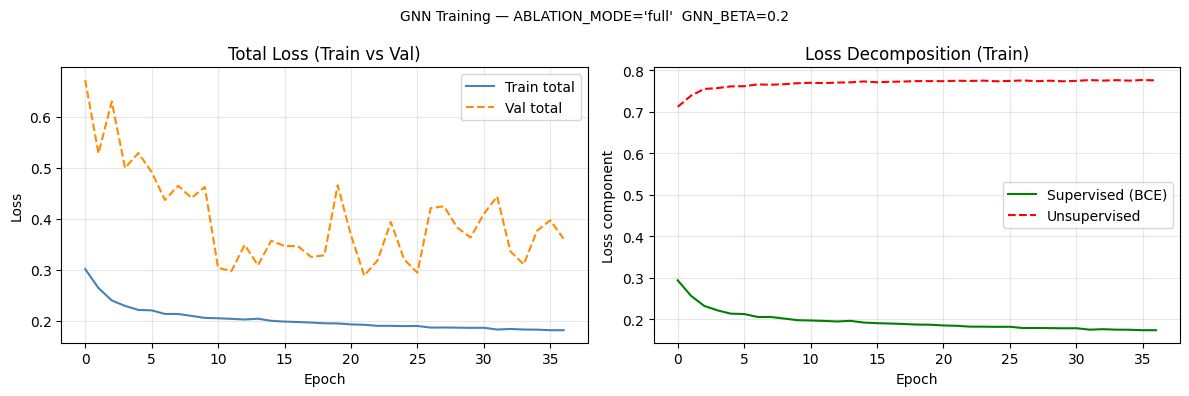

Best epoch: 22/100  best_val_loss: 0.2886


In [51]:
# Cell 18 — Loss Curves (Train + Val + Sup/Unsup decomposition)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(train_losses, label='Train total', color='steelblue')
ax.plot(val_losses,   label='Val total',   color='darkorange', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Total Loss (Train vs Val)')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(train_sup_losses,   label='Supervised (BCE)', color='green')
ax.plot(train_unsup_losses, label='Unsupervised',     color='red', linestyle='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss component')
ax.set_title('Loss Decomposition (Train)')
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f'GNN Training — ABLATION_MODE={ABLATION_MODE!r}  GNN_BETA={GNN_BETA}', fontsize=10)
plt.tight_layout(); plt.show()

best_epoch = int(np.argmin(val_losses)) + 1
print(f'Best epoch: {best_epoch}/{GNN_EPOCHS}  best_val_loss: {min(val_losses):.4f}')

### Pretrained Model Loading

In [ ]:
import torch
import os

# 1. Ensure device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

# 2. Re-instantiate architecture (must match trained model)
model = GraphSCPModel(
    in_ch=NODE_FEAT_DIM,
    hidden=GNN_HIDDEN,
    n_layers=GNN_LAYERS,
    dropout=GNN_DROPOUT,
).to(DEVICE)

# 3. Path to saved weights
W_PATH = os.path.join(OUTPUT_DIR, f'graphscp_weights_bs{NUMBS}_june4.pt')

# 4. Load weights
if os.path.exists(W_PATH):
    model.load_state_dict(torch.load(W_PATH, map_location=DEVICE))
    model.eval()
    print(f"Pre-trained model loaded from {W_PATH}")
else:
    print(f"Weights not found at {W_PATH} — train first.")


## 22. Greedy Set-Cover Baseline

Iteratively activates the BS covering the most uncovered UEs. Tie-break: lowest power cost.

In [52]:
# Cell 19 — Greedy Set-Cover Baseline

def greedy_set_cover(cg, bs_ct, physics,
                      coverage_target=TARGET_COVERAGE):
    """
    Greedy: iteratively activate the BS that covers the most uncovered UEs.
    Tie-break by lowest power cost.
    Returns active_mask, served_frac, power_w, elapsed_s.
    """
    t0 = time.time()
    n, num_bs = cg.shape
    sinr_dB_fn  = physics['sinr_dB']
    greedy_assoc = physics['greedy_association']
    netpwr       = physics['network_power_w']

    feas = np.zeros((n, num_bs), dtype=bool)
    for j in range(num_bs):
        mj = np.zeros(num_bs, dtype=np.int32); mj[j] = 1
        feas[:,j] = sinr_dB_fn(cg, mj)[:,j] >= SINR_THRESH_DB

    am      = np.zeros(num_bs, dtype=np.int32)
    covered = np.zeros(n, dtype=bool)
    cost_per_bs = np.array([P0_W[bs_ct[j]] + DELTA_P[bs_ct[j]]*P_TX_W[bs_ct[j]]
                             for j in range(num_bs)])
    users_needed = math.ceil(coverage_target * n)

    while covered.sum() < users_needed:
        best_j, best_gain = -1, -1
        for j in range(num_bs):
            if am[j]: continue
            gain = int(feas[~covered, j].sum())
            if gain > best_gain or (gain == best_gain and
               best_j >= 0 and cost_per_bs[j] < cost_per_bs[best_j]):
                best_j, best_gain = j, gain
        if best_j < 0 or best_gain == 0: break
        am[best_j] = 1
        # Re-check coverage after activation
        sv, _, _, _, _ = greedy_assoc(cg, am)
        covered = sv

    sv, sg, lu, lr, sr = greedy_assoc(cg, am)
    return dict(
        active_mask=am, served_frac=float(sv.mean()),
        power_w=netpwr(am, lr), n_active=int(am.sum()),
        elapsed=time.time()-t0)

print('Greedy set-cover baseline loaded.')

Greedy set-cover baseline loaded.


## 23. Graph-SCP Inference Pipeline

Threshold-decrement search (start from `THRESHOLD_INIT`, step down until coverage met). Micro-ILP fallback if GNN fails coverage target.

In [56]:
# Cell 20 — Graph-SCP Inference Pipeline
# E5: TAUHIGH / TAULOW used for threshold-based activation.
# Calibration of these thresholds is done in Cell 23.

TAUHIGH = 0.70   # default — will be calibrated in Cell 23
TAULOW  = 0.30   # default — will be calibrated in Cell 23

def graph_scp_infer(cg, feas, bs_ct, model, physics,
                     tau_high=None, tau_low=None,
                     coverage_target=TARGET_COVERAGE,
                     candidate_mask=None):
    """
    Graph-SCP inference:
      1. Build graph (with TRUST Slot 4, 2-D edge attrs).
      2. GNN predicts per-BS activation probabilities.
      3. Threshold decrement: start from THRESHOLD_INIT, step down until coverage met.
      4. Micro-ILP fallback if GNN fails coverage target.
    """
    if tau_high is None: tau_high = TAUHIGH
    if tau_low  is None: tau_low  = TAULOW
    t0 = time.time()
    greedy_assoc = physics['greedy_association']
    sinr_dB_fn   = physics['sinr_dB']
    netpwr       = physics['network_power_w']

    (Ft, ei, ea, A_full, _, _, m, num_bs_,
     cr, cn, tn, rh) = build_graph_with_edge_attr(cg, feas, bs_ct)

    # Candidate masking
    if candidate_mask is not None:
        allowed = np.where(candidate_mask >= 1)[0]
    else:
        allowed = np.arange(num_bs_)

    Ft_d = Ft.to(DEVICE); ei_d = ei.to(DEVICE); ea_d = ea.to(DEVICE)
    probs = model.predict_bs_probs(Ft_d, ei_d, ea_d, m, num_bs_)

    # Threshold-decrement search
    best_am = None; best_pwr = float('inf')
    for thr in np.arange(THRESHOLD_INIT, 0, -1) / 100.0:
        am = np.zeros(num_bs_, dtype=np.int32)
        for j in allowed:
            if probs[j] >= thr: am[j] = 1
        if am.sum() == 0: continue
        sv, _, _, lr, _ = greedy_assoc(cg, am)
        if sv.mean() >= coverage_target:
            pwr = netpwr(am, lr)
            if pwr < best_pwr: best_pwr, best_am = pwr, am.copy()
            break

    # Micro-ILP fallback if GNN could not meet coverage
    if best_am is None:
        fallback = ilp_solver(cg, candidate_mask=candidate_mask,
                               coverage_target=coverage_target,
                               time_limit=30)
        best_am = fallback['active_mask']

    sv, sg, lu, lr, sr = greedy_assoc(cg, best_am)
    return dict(
        active_mask=best_am,
        served_frac=float(sv.mean()),
        power_w=netpwr(best_am, lr),
        n_active=int(best_am.sum()),
        probs=probs,
        trust_norm=tn,
        rho_hat=rh,
        elapsed=time.time()-t0)

print(f'Graph-SCP inference loaded. TAUHIGH={TAUHIGH}  TAULOW={TAULOW}')

Graph-SCP inference loaded. TAUHIGH=0.7  TAULOW=0.3


## 24. Full Evaluation Loop (ILP + Graph-SCP + Greedy)

- `TARGET_COVERAGE` always used — no dynamic lowering (C2 fix from May 28).
- `records` initialised inside `run_evaluation()` — no stale accumulation (C3 fix).
- Physical infeasibility instances flagged separately.

In [57]:
# Cell 21 — Full Evaluation Loop (ILP + Graph-SCP + Greedy)
# C2 FIX: dynamic_cov_target lowering REMOVED — TARGET_COVERAGE=0.98 always used.
# C3 FIX: records=[] initialised INSIDE run_evaluation() — no stale accumulation.
# Physical infeasibility: instances where even greedy cannot reach TARGET_COVERAGE
#   are flagged as 'physically_infeasible' and reported separately.

def run_evaluation(test_dataset, model, physics, bs_ct, bs_df,
                    coverage_target=TARGET_COVERAGE,
                    verbose=True):
    """
    Evaluate ILP, Graph-SCP, and Greedy on test_dataset.
    C2: coverage_target is always TARGET_COVERAGE — never lowered dynamically.
    C3: records=[] is initialised here — safe to call multiple times.
    Returns: DataFrame of results.
    """
    # C3 FIX: records initialised inside function — no stale accumulation
    records = []

    greedy_assoc = physics['greedy_association']
    sinr_dB_fn   = physics['sinr_dB']
    netpwr       = physics['network_power_w']
    ue_bs_dist   = physics['ue_bs_distances']
    cg_fn        = physics['channel_gain_linear']
    n_ue_counts  = {}

    model.eval()
    for idx, d in enumerate(tqdm(test_dataset, desc='Evaluating')):
        cg   = d['cg'].numpy()   if isinstance(d['cg'],   torch.Tensor) else d['cg']
        feas = d['feas'].numpy() if isinstance(d['feas'], torch.Tensor) else d['feas']
        xy   = d['xy'].numpy()   if isinstance(d['xy'],   torch.Tensor) else d['xy']
        hour = d.get('hour', 0)
        n_ue = cg.shape[0]

        # ── Physical infeasibility check ──────────────────────────────
        # If even greedy (all BSs on) cannot cover TARGET_COVERAGE, the instance
        # is physically infeasible — flag it and skip (do not count as algorithm failure).
        am_all = np.ones(NUMBS, dtype=np.int32)
        sv_all, _, _, lr_all, _ = greedy_assoc(cg, am_all)
        if sv_all.mean() < coverage_target:
            records.append(dict(
                idx=idx, hour=hour, n_ue=n_ue,
                ilp_power=None, ilp_cov=None, t_ilp=None,
                gscp_power=None, gscp_cov=None, t_gscp=None,
                greedy_power=None, greedy_cov=None, t_greedy=None,
                physically_infeasible=True,
                obj_criterion_met=False,
            ))
            if verbose: print(f'  [idx={idx}] PHYSICALLY INFEASIBLE: max_cov={sv_all.mean():.3f} < {coverage_target}')
            continue

        # ── ILP ───────────────────────────────────────────────────────
        t0 = time.time()
        # C2 FIX: coverage_target passed directly — no dynamic lowering
        ilp_res = ilp_solver(cg, coverage_target=coverage_target)
        t_ilp   = time.time() - t0

        # ── Graph-SCP ─────────────────────────────────────────────────
        t0 = time.time()
        gscp_res = graph_scp_infer(cg, feas, bs_ct, model, physics,
                                    coverage_target=coverage_target)
        t_gscp = time.time() - t0

        # ── Greedy ────────────────────────────────────────────────────
        t0 = time.time()
        gr_res = greedy_set_cover(cg, bs_ct, physics,
                                   coverage_target=coverage_target)
        t_greedy = time.time() - t0

        # ── Objective: u_obj = greedy power (paper convention) ────────
        u_obj = gr_res['power_w']
        obj_met = (
            ilp_res['served_frac']  >= coverage_target and
            gscp_res['served_frac'] >= coverage_target and
            gr_res['served_frac']   >= coverage_target
        )

        records.append(dict(
            idx=idx, hour=hour, n_ue=n_ue,
            ilp_power=round(ilp_res['power_w'],1),
            ilp_cov=round(ilp_res['served_frac'],4),
            t_ilp=round(t_ilp,4),
            gscp_power=round(gscp_res['power_w'],1),
            gscp_cov=round(gscp_res['served_frac'],4),
            t_gscp=round(t_gscp,4),
            greedy_power=round(gr_res['power_w'],1),
            greedy_cov=round(gr_res['served_frac'],4),
            t_greedy=round(t_greedy,4),
            gscp_nbs=int(gscp_res['n_active']),
            ilp_nbs=int(ilp_res['n_active']),
            n_reductions=int(gscp_res['n_active']) - int(ilp_res['n_active']),
            u_obj=round(u_obj,1),
            obj_criterion_met=obj_met,
            physically_infeasible=False,
        ))

    df = pd.DataFrame(records)
    return df

print('Evaluation function loaded (C2: fixed coverage target, C3: records=[] inside fn).')

Evaluation function loaded (C2: fixed coverage target, C3: records=[] inside fn).


## 25. Generate Independent Test Dataset

In [55]:
# # --- Generate Independent Test Dataset ---
# import os, pickle
# from tqdm import tqdm

# # Test scenarios: UE count → hour
# TEST_UE_HOUR = {
#         10: 420,
#         11: 520,
#         12: 650,
#         13: 750,  # Lunch peak
#         14: 600,
#         15: 550,
#         16: 680,
#         17: 820,
#         18: 900,  # Evening maximum
#         19: 850,
#         20: 680,
#         21: 450,
# }

# NUM_TEST_PER_BUCKET = 2   # test instances per bucket
# TEST_SEED_OFF       = 8888  # different from training SEED_OFF=999

# bs_df_t, bs_xy_t, bs_ct_t, same_ct_t, _, _ = make_hetnet(NUMBS)
# phys_t  = build_physics(bs_xy_t, bs_ct_t, same_ct_t)
# ilp_t   = make_ilp_solver(bs_ct_t, phys_t, NUMBS)

# test_dataset = []

# for n_ue, hr in TEST_UE_HOUR.items():
#     print(f"\nTest Bucket {n_ue} UEs | Hour {hr}")
#     cnt = att = 0
#     pbar = tqdm(total=NUM_TEST_PER_BUCKET, desc=f"UE{n_ue}", unit='sample', dynamic_ncols=True)
#     while cnt < NUM_TEST_PER_BUCKET:
#         for tt in TRAFFIC_TYPES:
#             inst = generate_instance(
#                 NUMBS, n_ue,
#                 TEST_SEED_OFF + n_ue * 1000 + att,
#                 phys_t, ilp_t, bs_ct_t,
#                 traffic_type=tt,
#             )
#             att += 1

#             if inst is None:          # ← ADD THIS — guard returned None
#                 continue
#             if inst['result']['status'] == 'Optimal':
#                 test_dataset.append(inst)
#                 cnt += 1
#                 pbar.update(1)
#                 if cnt >= NUM_TEST_PER_BUCKET:
#                     break
#     pbar.close()

# TEST_DS_PATH = os.path.join(OUTPUT_DIR, f'test_dataset_bs{NUMBS}_june4.pkl')
# with open(TEST_DS_PATH, 'wb') as f:
#     pickle.dump(test_dataset, f)
# print(f"\nSaved {len(test_dataset)} TEST instances to {TEST_DS_PATH}")


In [67]:
import os, pickle
from tqdm import tqdm

# Original 10-bucket mapping
HOUR_USERCOUNTS = {
    10: 420, 11: 520, 12: 650, 13: 750, 14: 600, 15: 550,
    16: 680, 17: 820, 18: 900, 19: 850, 20: 680, 21: 450,
}

TEST_UE_HOUR = {v: k for k, v in HOUR_USERCOUNTS.items()}

EXTRA_UE_COUNTS = [350, 750, 1000, 210,663]
EXTRA_UE_HOUR   = {n: None for n in EXTRA_UE_COUNTS}

ALL_TEST_BUCKETS = {**TEST_UE_HOUR, **EXTRA_UE_HOUR}

NUM_TEST_PER_BUCKET = 4    # instances per (ue_count, traffic_type) bucket
TEST_SEED_OFF       = 8888  # isolated from training (SEED_OFF=999)

# Build a fresh topology + physics + ILP for test (same NUMBS, different rng)
bs_df_t, bs_xy_t, bs_ct_t, same_ct_t, _, _ = make_hetnet(NUMBS)
phys_t = build_physics(bs_xy_t, bs_ct_t, same_ct_t)
ilp_t  = make_ilp_solver(bs_ct_t, phys_t, NUMBS)

test_dataset = []

for n_ue, hr in sorted(ALL_TEST_BUCKETS.items()):
    source = "original" if n_ue in TEST_UE_HOUR else "extended"
    print(f"\n[{source}] Bucket {n_ue} UEs | Hour {hr}")

    for tt in TRAFFIC_TYPES:
        cnt = 0
        att = 0
        pbar = tqdm(total=NUM_TEST_PER_BUCKET, desc=f"UE{n_ue}/{tt}", unit='inst', dynamic_ncols=True)

        while cnt < NUM_TEST_PER_BUCKET and att < NUM_TEST_PER_BUCKET * 10:
            seed = TEST_SEED_OFF + n_ue * 2000 + TRAFFIC_TYPES.index(tt) * 500 + att

            t0 = time.time()
            inst = generate_instance(
                NUMBS, n_ue, seed,
                phys_t, ilp_t, bs_ct_t,
                traffic_type=tt,
            )
            t_graph = time.time() - t0


            att += 1

            if inst is None:
                continue
            if inst['result']['status'] != 'Optimal':
                continue

            inst['meta'] = {        # tag each instance with context
                'n_ue': n_ue,
                'hour': hr,
                'traffic_type': tt,
                'source': source,   # 'original' vs 'extended'
                'seed': seed,
                'graph_time_s': round(t_graph, 4)
            }
            test_dataset.append(inst)
            cnt += 1
            pbar.update(1)

        pbar.close()
        if att >= NUM_TEST_PER_BUCKET * 10:
            print(f"  ⚠ Could not fill {NUM_TEST_PER_BUCKET} instances for UE{n_ue}/{tt} (got {cnt})")

# Save
TEST_DS_PATH = os.path.join(OUTPUT_DIR, f'test_dataset_bs{NUMBS}_v5_extended.pkl')
with open(TEST_DS_PATH, 'wb') as f:
    pickle.dump(test_dataset, f)

print(f"\n✓ Saved {len(test_dataset)} test instances → {TEST_DS_PATH}")
print(f"  Original buckets : {len([i for i in test_dataset if i['meta']['source']=='original'])}")
print(f"  Extended buckets : {len([i for i in test_dataset if i['meta']['source']=='extended'])}")


[extended] Bucket 210 UEs | Hour None


UE210/hotspot: 100%|██████████| 4/4 [00:02<00:00,  1.54inst/s]



[extended] Bucket 350 UEs | Hour None


UE350/hotspot: 100%|██████████| 4/4 [00:03<00:00,  1.06inst/s]



[original] Bucket 420 UEs | Hour 10


...


[original] Bucket 900 UEs | Hour 18


UE900/hotspot: 100%|██████████| 4/4 [01:27<00:00, 21.86s/inst]



[extended] Bucket 1000 UEs | Hour None


UE1000/hotspot: 100%|██████████| 4/4 [00:53<00:00, 13.37s/inst]


✓ Saved 60 test instances → output/GraphSCPHetNet/test_dataset_bs21_v5_extended.pkl
  Original buckets : 44
  Extended buckets : 16


## 26. Run Evaluation and Results Table

In [ ]:
# # Cell 22 — Run Evaluation and Results Table

# # Load test dataset
# # TEST_DS_PATH = os.path.join(OUTPUT_DIR, f'test_dataset_bs{NUMBS}_june4.pkl')
# TEST_DS_PATH = '/content/output/300_400_500_600_700_TEST_dataset_bs21_may28.pkl'
# if os.path.exists(TEST_DS_PATH):
#     with open(TEST_DS_PATH, 'rb') as f: test_dataset = pickle.load(f)
#     print(f'Loaded {len(test_dataset)} test instances from {TEST_DS_PATH}')
# else:
#     print(f'Test dataset not found at {TEST_DS_PATH}')
#     print('Using last 20% of training dataset as proxy test set.')
#     test_dataset = val_set


In [68]:
num_samples = max(40, len(test_dataset))

# Select random samples without replacement
sampled_test_dataset = random.sample(test_dataset, num_samples)

In [69]:
# Run evaluation
results_df = run_evaluation(sampled_test_dataset, model, physics, bs_ct, bs_df, verbose=False)

# Separate physically infeasible instances
infeasible_df = results_df[results_df['physically_infeasible'] == True]
feasible_df   = results_df[results_df['physically_infeasible'] == False].copy()

print(f'\nTotal instances: {len(results_df)}')
print(f'Physically infeasible: {len(infeasible_df)} (excluded from algorithm comparison)')
print(f'Feasible (algorithm comparison): {len(feasible_df)}')

# Display results table
display_cols = ['idx','hour','n_ue',
                'ilp_power','ilp_cov','t_ilp',
                'gscp_power','gscp_cov','t_gscp',
                'greedy_power','greedy_cov','t_greedy',
                'gscp_nbs','ilp_nbs','obj_criterion_met']
print('\n=== Full Results Table (feasible instances) ===')
print(feasible_df[display_cols].to_markdown(index=False))



Evaluating: 100%|██████████| 60/60 [05:52<00:00,  5.87s/it]


Total instances: 60
Physically infeasible: 8 (excluded from algorithm comparison)
Feasible (algorithm comparison): 52

=== Full Results Table (feasible instances) ===
|   idx |   hour |   n_ue |   ilp_power |   ilp_cov |   t_ilp |   gscp_power |   gscp_cov |   t_gscp |   greedy_power |   greedy_cov |   t_greedy |   gscp_nbs |   ilp_nbs | obj_criterion_met   |
|------:|-------:|-------:|------------:|----------:|--------:|-------------:|-----------:|---------:|---------------:|-------------:|-----------:|-----------:|----------:|:--------------------|
|     0 |      0 |    350 |       362   |         1 |  0.2312 |        351.1 |     0.8486 |   0.6157 |         1073.3 |       1      |     0.0285 |          7 |         7 | False               |
|     1 |      0 |    420 |       380.3 |         1 |  0.448  |        377.6 |     0.9548 |   0.941  |         1477.3 |       1      |     0.035  |         10 |        10 | False               |
|     2 |      0 |    210 |       277.5 |         1 

In [71]:
# ── NEW: Add gscp_cov, gscp_saving, ilp_gap columns to feasible_df ─────────
# feasible_df['gscp_cov']    = feasible_df['gscp_cov']                              # alias for clarity
feasible_df['gscp_saving'] = (feasible_df['greedy_power'] - feasible_df['gscp_power']) / feasible_df['greedy_power'] * 100
feasible_df['ilp_gap']     = (feasible_df['gscp_power']   - feasible_df['ilp_power'])  / feasible_df['ilp_power']  * 100

print("\n── Feasible-set derived metrics ──")
print(f"  gscp_cov    mean={feasible_df['gscp_cov'].mean():.4f}  min={feasible_df['gscp_cov'].min():.4f}")
print(f"  gscp_saving mean={feasible_df['gscp_saving'].mean():.2f}%  (GNN saves vs Greedy)")
print(f"  ilp_gap     mean={feasible_df['ilp_gap'].mean():.2f}%  (GNN overhead vs ILP oracle)")


── Feasible-set derived metrics ──
  gscp_cov    mean=0.9880  min=0.8486
  gscp_saving mean=28.58%  (GNN saves vs Greedy)
  ilp_gap     mean=42.30%  (GNN overhead vs ILP oracle)


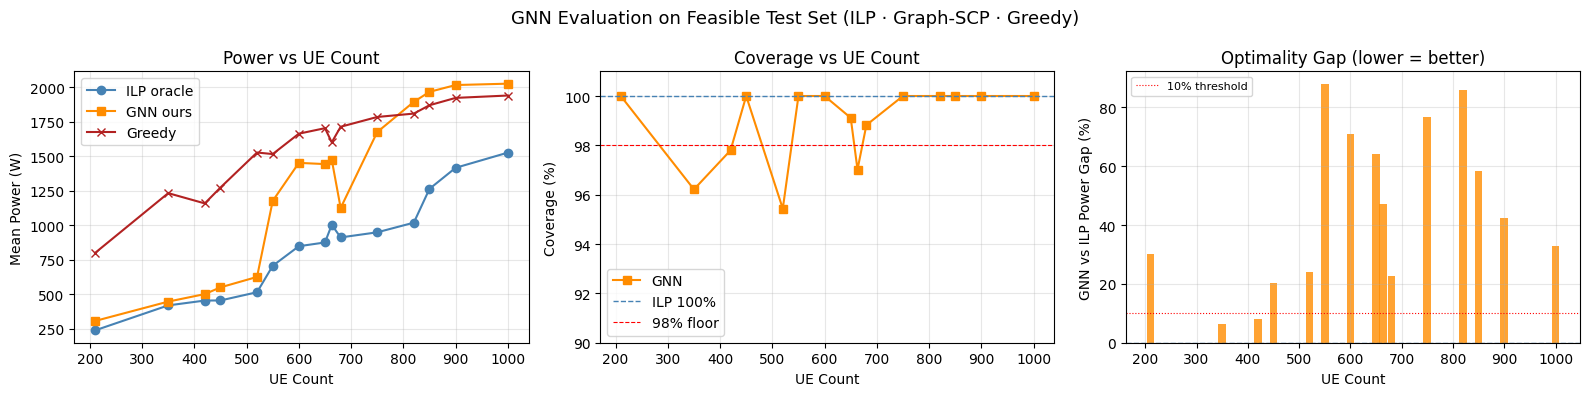


gscp_cov    mean=0.9880  min=0.8486
gscp_saving mean=28.58%  (GNN saves vs Greedy)
ilp_gap     mean=42.30%  (GNN overhead vs ILP oracle)


In [74]:
# Cell 32 ── Feasible-Set 3-Panel Evaluation (mirrors OOD plot style)
import matplotlib.pyplot as plt
import numpy as np

if len(feasible_df) == 0:
    print("feasible_df is empty – run Cell 26 first.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle("GNN Evaluation on Feasible Test Set (ILP · Graph-SCP · Greedy)", fontsize=13)

    g = feasible_df.groupby('n_ue').mean(numeric_only=True).reset_index()

    # ── Panel 1: Power vs UE Count ──
    axes[0].plot(g['n_ue'], g['ilp_power'],    'o-', color='steelblue',  label='ILP oracle')
    axes[0].plot(g['n_ue'], g['gscp_power'],   's-', color='darkorange', label='GNN ours')
    axes[0].plot(g['n_ue'], g['greedy_power'], 'x-', color='firebrick',  label='Greedy')
    axes[0].set_ylabel("Mean Power (W)")
    axes[0].set_title("Power vs UE Count")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # ── Panel 2: GSCP Coverage % ──
    axes[1].plot(g['n_ue'], g['gscp_cov'] * 100, 's-', color='darkorange', label='GNN')
    axes[1].axhline(100, color='steelblue', linestyle='--', linewidth=1, label='ILP 100%')
    axes[1].axhline(98,  color='red',       linestyle='--', linewidth=0.8, label='98% floor')
    axes[1].set_ylabel("Coverage (%)")
    axes[1].set_title("Coverage vs UE Count")
    axes[1].set_ylim(90, 101)
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # ── Panel 3: ILP Gap (GNN vs ILP oracle) ──
    axes[2].bar(g['n_ue'], g['ilp_gap'], color='darkorange', alpha=0.8, width=15)
    axes[2].axhline(0,  color='steelblue', linestyle='--', linewidth=1)
    axes[2].axhline(10, color='red',       linestyle=':',  linewidth=0.8, label='10% threshold')
    axes[2].set_ylabel("GNN vs ILP Power Gap (%)")
    axes[2].set_title("Optimality Gap (lower = better)")
    axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

    for ax in axes:
        ax.set_xlabel("UE Count")

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/feasible_3panel_eval.png", dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary print ──
    print(f"\ngscp_cov    mean={feasible_df['gscp_cov'].mean():.4f}  min={feasible_df['gscp_cov'].min():.4f}")
    print(f"gscp_saving mean={feasible_df['gscp_saving'].mean():.2f}%  (GNN saves vs Greedy)")
    print(f"ilp_gap     mean={feasible_df['ilp_gap'].mean():.2f}%  (GNN overhead vs ILP oracle)")

In [75]:
feasible_df

,idx,hour,n_ue,ilp_power,ilp_cov,t_ilp,gscp_power,gscp_cov,t_gscp,greedy_power,greedy_cov,t_greedy,gscp_nbs,ilp_nbs,n_reductions,u_obj,obj_criterion_met,physically_infeasible,gscp_saving,ilp_gap
0,0,0,350,362.0,1.0,0.2312,351.1,0.8486,0.6157,1073.3,1.0000,0.0285,7.0,7.0,0.0,1073.3,False,False,67.287804,-3.011050
1,1,0,420,380.3,1.0,0.4480,377.6,0.9548,0.9410,1477.3,1.0000,0.0350,10.0,10.0,0.0,1477.3,False,False,74.439856,-0.709966
2,2,0,210,277.5,1.0,0.1531,278.8,1.0000,0.1394,954.9,1.0000,0.0202,5.0,4.0,1.0,954.9,True,False,70.803225,0.468468
3,3,0,750,951.2,1.0,1.9029,1918.3,1.0000,1.2225,1828.5,1.0000,0.1486,18.0,15.0,3.0,1828.5,True,False,-4.911129,101.671573
4,4,0,350,364.6,1.0,0.4394,364.3,1.0000,0.2343,1078.9,1.0000,0.0437,8.0,9.0,-1.0,1078.9,True,False,66.234127,-0.082282
5,5,0,600,832.8,1.0,18.1848,972.1,1.0000,0.4254,1568.3,0.9917,0.0714,15.0,14.0,1.0,1568.3,False,False,38.015686,16.726705
6,6,0,520,787.6,1.0,0.5164,807.2,0.8692,1.0832,1565.7,1.0000,0.0428,13.0,13.0,0.0,1565.7,False,False,48.444785,2.488573
7,7,0,600,848.9,1.0,13.8573,1406.1,1.0000,0.6014,1668.9,1.0000,0.0669,17.0,12.0,5.0,1668.9,True,False,15.746899,65.637884
8,8,0,350,633.9,1.0,0.7904,697.0,1.0000,0.5235,1408.1,1.0000,0.0502,12.0,8.0,4.0,1408.1,True,False,50.500675,9.954251
9,9,0,450,706.6,1.0,0.5987,880.6,1.0000,0.3796,1162.7,1.0000,0.0728,12.0,11.0,1.0,1162.7,True,False,24.262492,24.624965


In [65]:
# ── OOD Evaluation: Unseen UE Counts ─────────────────────────────────────────
# These counts were NEVER in training (not hourly means, not bucket boundaries)
# Proves GNN generalises to arbitrary UE counts at inference time

OOD_UE_COUNTS   = [175, 250, 490, 725, 1000]
OOD_TRAFFIC     = ["random", "hotspot"]
OOD_SEED_BASE   = 77777
OOD_N_PER_CASE  = 2         # 5 instances per (n_ue, traffic_type)

ood_results = []

for n_ue in OOD_UE_COUNTS:
    for tt in OOD_TRAFFIC:
        for k in range(OOD_N_PER_CASE):
            inst = generate_instance(
                NUMBS, n_ue,
                OOD_SEED_BASE + n_ue * 100 + k,
                physics, ilp_solver, bs_ct,
                traffic_type=tt,
            )
            if inst['result']['status'] != 'Optimal':
                continue

            # Convert tensors to numpy arrays before passing to functions that expect them
            cg_np = inst['cg'].numpy() if isinstance(inst['cg'], torch.Tensor) else inst['cg']
            feas_np = inst['feas'].numpy() if isinstance(inst['feas'], torch.Tensor) else inst['feas']

            # Run GNN inference
            gscp_res = graph_scp_infer(
                cg_np,
                feas_np,
                bs_ct,
                model, physics,
            )
            # Run greedy baseline
            gr_res = greedy_set_cover(cg_np, bs_ct, physics)

            ilp_pwr  = inst['result']['power_w']
            gscp_pwr = gscp_res['power_w']
            gr_pwr   = gr_res['power_w']

            ood_results.append({
                'n_ue':         n_ue,
                'traffic_type': tt,
                'ilp_power':    ilp_pwr,
                'gscp_power':   gscp_pwr,
                'greedy_power': gr_pwr,
                'gscp_cov':     gscp_res['served_frac'],
                'ilp_cov':      inst['result']['served_frac'],
                'gscp_saving':  (gr_pwr - gscp_pwr) / gr_pwr * 100,
                'ilp_gap':      (gscp_pwr - ilp_pwr) / ilp_pwr * 100,
            })

ood_df = pd.DataFrame(ood_results)

# ── Summary table grouped by n_ue ────────────────────────────────────────────
summary = ood_df.groupby('n_ue').agg(
    ilp_power   = ('ilp_power',    'mean'),
    gscp_power  = ('gscp_power',   'mean'),
    greedy_power= ('greedy_power', 'mean'),
    gscp_cov    = ('gscp_cov',     'mean'),
    gscp_saving = ('gscp_saving',  'mean'),
    ilp_gap     = ('ilp_gap',      'mean'),
).round(2)

print("OOD Generalisation Results (never seen during training)")
print(summary.to_string())

OOD Generalisation Results (never seen during training)
      ilp_power  gscp_power  greedy_power  gscp_cov  gscp_saving  ilp_gap
n_ue                                                                     
175      265.67      343.83       1000.40      0.99        63.75    28.82
250      343.89      370.66        913.59      0.99        55.30     8.16
490      547.63      583.59       1464.65      0.97        58.45     4.54
725      755.70      885.17       1769.83      0.97        49.36    13.78
1000    1575.53     1724.01       1989.01      0.93        13.96     9.78


In [66]:
ood_df

,n_ue,traffic_type,ilp_power,gscp_power,greedy_power,gscp_cov,ilp_cov,gscp_saving,ilp_gap
0,175,random,287.544083,402.118250,1246.980000,1.000000,1.00,67.752630,3.984577e+01
1,175,random,332.623750,428.611250,1246.980000,1.000000,1.00,65.628057,2.885768e+01
2,175,hotspot,219.303333,322.211250,596.961500,1.000000,1.00,46.024786,4.692492e+01
3,175,hotspot,223.192083,222.373083,910.680000,0.977143,1.00,75.581644,-3.669485e-01
4,250,random,443.967500,443.967500,642.130083,1.000000,1.00,30.860193,-1.280351e-14
5,250,random,397.462667,447.342000,1364.062750,1.000000,1.00,67.205174,1.254944e+01
6,250,hotspot,248.454583,249.421167,984.383000,0.972000,1.00,74.662183,3.890382e-01
7,250,hotspot,285.685000,341.916667,663.785250,1.000000,1.00,48.489867,1.968310e+01
8,490,random,495.624917,498.720333,1543.080000,1.000000,1.00,67.680202,6.245482e-01
9,490,random,509.744833,495.913917,1543.080000,1.000000,1.00,67.862073,-2.713302e+00


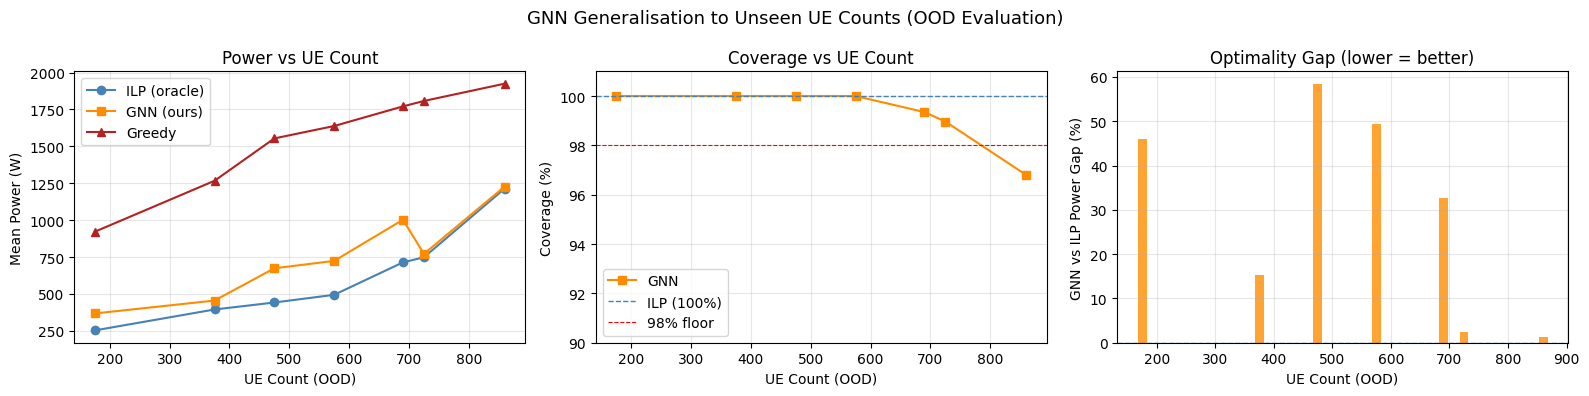

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("GNN Generalisation to Unseen UE Counts (OOD Evaluation)", fontsize=13)

g = ood_df.groupby('n_ue').mean(numeric_only=True).reset_index()

# Panel 1 — Power comparison
axes[0].plot(g['n_ue'], g['ilp_power'],    'o-', color='steelblue',  label='ILP (oracle)')
axes[0].plot(g['n_ue'], g['gscp_power'],   's-', color='darkorange', label='GNN (ours)')
axes[0].plot(g['n_ue'], g['greedy_power'], '^-', color='firebrick',  label='Greedy')
axes[0].set_ylabel('Mean Power (W)')
axes[0].set_title('Power vs UE Count')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2 — Coverage
axes[1].plot(g['n_ue'], g['gscp_cov'] * 100, 's-', color='darkorange', label='GNN')
axes[1].axhline(100, color='steelblue', linestyle='--', linewidth=1, label='ILP (100%)')
axes[1].axhline(98,  color='red',       linestyle='--', linewidth=0.8, label='98% floor')
axes[1].set_ylabel('Coverage (%)')
axes[1].set_title('Coverage vs UE Count')
axes[1].set_ylim([90, 101])
axes[1].legend()
axes[1].grid(alpha=0.3)

# Panel 3 — ILP gap %
axes[2].bar(g['n_ue'], g['ilp_gap'], color='darkorange', alpha=0.8, width=15)
axes[2].axhline(0,  color='steelblue', linestyle='--', linewidth=1)
axes[2].set_ylabel('GNN vs ILP Power Gap (%)')
axes[2].set_title('Optimality Gap (lower = better)')
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.set_xlabel('UE Count (OOD)')

plt.tight_layout()
plt.show()

## 27. Visualisation Helpers

`plot_avg_sinr_per_band`, `plot_energy_per_bs`, `plot_trust_per_bs` — colours unchanged.

In [109]:
# Cell 14 — Visualisation Helpers

def plot_energy_per_bs(active_mask, load_ratio, bs_ct, bs_labels,
                        title='Energy per BS'):
    nb = len(active_mask)
    per_bs = np.array([
        P_SLEEP_W[bs_ct[j]] if not int(active_mask[j])
        else P0_W[bs_ct[j]]+DELTA_P[bs_ct[j]]*P_TX_W[bs_ct[j]]*float(np.clip(load_ratio[j],0,1))
        for j in range(nb)])
    bc = ['steelblue', 'darkorange', 'firebrick', 'mediumseagreen']
    colors = [bc[bs_ct[j] % len(bc)] if int(active_mask[j]) else 'lightgrey' for j in range(nb)]
    fig,ax = plt.subplots(figsize=(max(8,nb*0.6),4))
    bars = ax.bar(range(nb),per_bs,color=colors,edgecolor='grey',linewidth=0.4)
    ax.set_xticks(range(nb)); ax.set_xticklabels(bs_labels,rotation=45,ha='right',fontsize=7)
    ax.set_ylabel('Power (W)'); ax.set_title(title)
    ax.bar_label(bars,fmt='%.0fW',padding=2,fontsize=6)
    plt.tight_layout(); plt.show()
    print(f'  Total: {per_bs.sum():.1f} W  Active: {int(active_mask.sum())}/{nb}')

def plot_trust_per_bs(trust_norm, rho_hat, bs_ct, bs_labels,
                       title='TRUST Score and Expected Load per BS'):
    nb = len(trust_norm); x = np.arange(nb)
    fig,ax1 = plt.subplots(figsize=(max(8,nb*0.6),4))
    bc = ['steelblue', 'darkorange', 'firebrick', 'mediumseagreen']
    ax1.bar(x, trust_norm, color=[bc[bs_ct[j] % len(bc)] for j in range(nb)], alpha=0.7, label='TRUST')
    ax2 = ax1.twinx()
    ax2.plot(x, rho_hat, 'k--o', markersize=4, linewidth=1, label='rho_hat')
    ax1.set_xticks(x); ax1.set_xticklabels(bs_labels,rotation=45,ha='right',fontsize=7)
    ax1.set_ylabel('TRUST (norm)'); ax2.set_ylabel('Expected load rho_hat')
    ax1.set_title(title); plt.tight_layout(); plt.show()

print('Visualisation helpers loaded: plot_avg_sinr_per_band, plot_energy_per_bs, plot_trust_per_bs')

Visualisation helpers loaded: plot_avg_sinr_per_band, plot_energy_per_bs, plot_trust_per_bs


## 29. Energy Per BS Visualisation

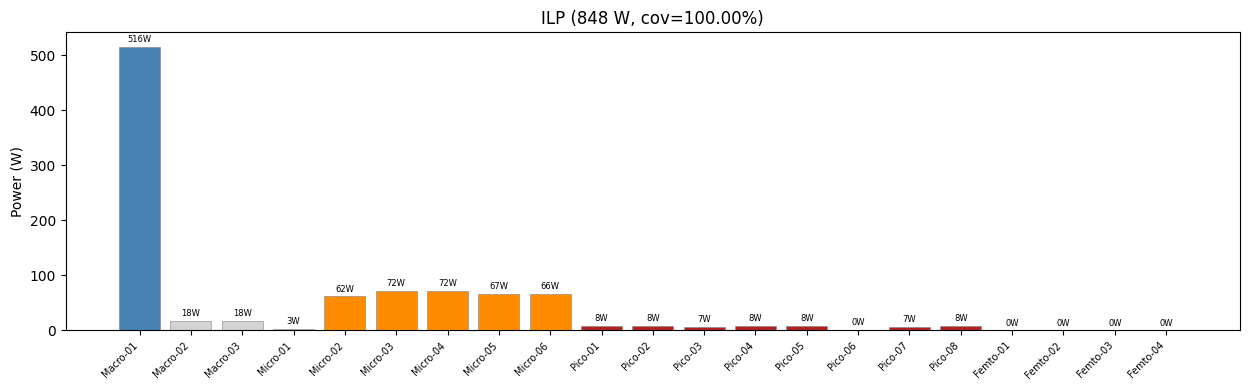

  Total: 947.5 W  Active: 13/21


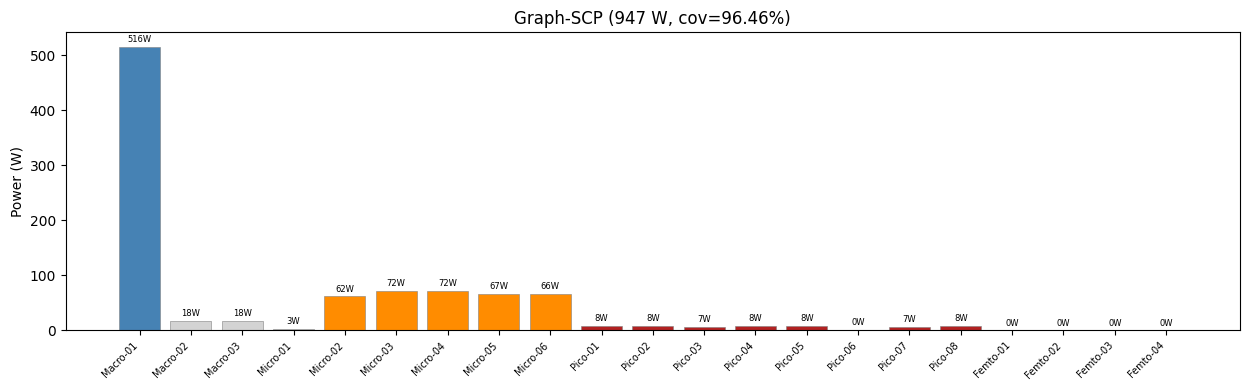

  Total: 947.5 W  Active: 13/21


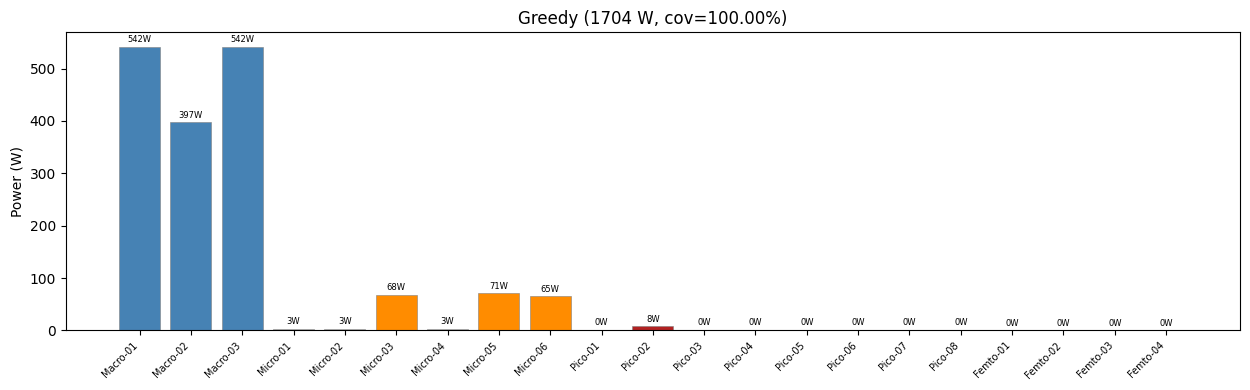

  Total: 1704.4 W  Active: 7/21


In [92]:
# Cell 24 — Energy per BS Visualisation
# Uses the last evaluated test instance for illustration.

if len(feasible_df) > 0 and len(test_dataset) > 0:
    sample_d = sampled_test_dataset[22]
    cg_s   = sample_d['cg'].numpy()   if isinstance(sample_d['cg'],   torch.Tensor) else sample_d['cg']
    feas_s = sample_d['feas'].numpy() if isinstance(sample_d['feas'], torch.Tensor) else sample_d['feas']

    ilp_s  = ilp_solver(cg_s)
    gscp_s = graph_scp_infer(cg_s, feas_s, bs_ct, model, physics)
    gr_s   = greedy_set_cover(cg_s, bs_ct, physics)

    _, _, lu_ilp,  lr_ilp,  _ = physics['greedy_association'](cg_s, ilp_s['active_mask'])
    _, _, lu_gscp, lr_gscp, _ = physics['greedy_association'](cg_s, gscp_s['active_mask'])
    _, _, lu_gr,   lr_gr,   _ = physics['greedy_association'](cg_s, gr_s['active_mask'])

    bs_labels = bs_df['label'].tolist()

    for title, am, lr in [
        (f'ILP ({ilp_s["power_w"]:.0f} W, cov={ilp_s["served_frac"]:.2%})',
         ilp_s['active_mask'], lr_ilp),
        (f'Graph-SCP ({gscp_s["power_w"]:.0f} W, cov={gscp_s["served_frac"]:.2%})',
         gscp_s['active_mask'], lr_gscp),
        (f'Greedy ({gr_s["power_w"]:.0f} W, cov={gr_s["served_frac"]:.2%})',
         gr_s['active_mask'], lr_gr),
    ]:
        plot_energy_per_bs(am, lr, bs_ct, bs_labels, title=title)
else:
    print('No feasible test instances available for visualisation.')

## 30. Average SINR Per Band

In [112]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 25 — 3-Algorithm SINR Comparison: ILP vs Graph-SCP vs Greedy
#           Grouped bar chart per band (low / mid / high)
#           Blue = ILP, Green = Graph-SCP, Red = Greedy
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np


def plot_sinr_three_way(inst_idx: int = 0):
    """
    For one sampled_test_dataset instance, run all three solvers and plot
    mean SINR per band side-by-side: ILP (blue) | Graph-SCP (green) | Greedy (red).
    Bars grouped by band: low-700MHz | mid-3p5GHz | high-28GHz
    """
    if inst_idx >= len(sampled_test_dataset):
        raise IndexError(f"inst_idx={inst_idx} out of range.")

    d    = sampled_test_dataset[inst_idx]
    cg   = d["cg"].numpy()   if isinstance(d["cg"],   torch.Tensor) else d["cg"]
    feas = d["feas"].numpy() if isinstance(d["feas"], torch.Tensor) else d["feas"]

    # ── Solve ─────────────────────────────────────────────────────────────────
    ilp_res  = ilp_solver(cg, coverage_target=TARGET_COVERAGE)
    gscp_res = graph_scp_infer(cg, feas, bs_ct, model, physics)
    gr_res   = greedy_set_cover(cg, bs_ct, physics)

    # ILP: use its own sv/sg (oracle assignment)
    sv_ilp  = ilp_res["sv_ilp"]
    sg_ilp  = ilp_res["sg_ilp"]
    am_ilp  = ilp_res["active_mask"].astype(bool)
    sr_ilp  = physics["sinr_dB"](cg, ilp_res["active_mask"])

    # GSCP + Greedy: re-derive via greedy_association
    sv_gscp, sg_gscp, _, lr_gscp, _ = physics["greedy_association"](cg, gscp_res["active_mask"])
    sv_gr,   sg_gr,   _, lr_gr,   _ = physics["greedy_association"](cg, gr_res["active_mask"])
    am_gscp = gscp_res["active_mask"].astype(bool)
    am_gr   = gr_res["active_mask"].astype(bool)
    sr_gscp = physics["sinr_dB"](cg, gscp_res["active_mask"])
    sr_gr   = physics["sinr_dB"](cg, gr_res["active_mask"])

    # ── Compute mean SINR per band per algo ───────────────────────────────────
    ALGO_CONFIGS = [
        ("ILP",       sv_ilp,  sg_ilp,  sr_ilp,  am_ilp),
        ("Graph-SCP", sv_gscp, sg_gscp, sr_gscp, am_gscp),
        ("Greedy",    sv_gr,   sg_gr,   sr_gr,   am_gr),
    ]
    ALGO_COLORS = ["#1565C0", "#2E7D32", "#C62828"]   # blue, green, red

    # band_means[band_idx][algo_idx] = mean SINR (or NaN if no data)
    band_means = {b: [] for b in range(len(BAND_NAMES))}

    for algo_name, sv, sg, sr, am in ALGO_CONFIGS:
        for b, band_name in enumerate(BAND_NAMES):
            # active BSs of this band
            bbs = np.where((bs_ct == b) & am)[0]
            if not len(bbs):
                band_means[b].append(np.nan)
                continue
            sinrs = [
                sr[i, sg[i]]
                for i in range(len(sv))
                if sv[i] and sg[i] in bbs and sr[i, sg[i]] >= SINR_THRESH_DB
            ]
            band_means[b].append(float(np.mean(sinrs)) if sinrs else np.nan)

    # ── Plot ──────────────────────────────────────────────────────────────────
    # Only include bands that have at least one algo with data
    active_bands = [b for b in range(len(BAND_NAMES))
                    if not all(np.isnan(v) for v in band_means[b])]

    n_bands  = len(active_bands)
    n_algos  = 3
    x        = np.arange(n_bands)
    w        = 0.22
    offsets  = [-w, 0.0, w]

    fig, ax = plt.subplots(figsize=(max(6, n_bands * 2.5), 4.5))

    for ai, (algo_name, _, _, _, _) in enumerate(ALGO_CONFIGS):
        vals = [band_means[b][ai] for b in active_bands]
        bars = ax.bar(
            x + offsets[ai], vals,
            width=w,
            color=ALGO_COLORS[ai],
            alpha=0.88,
            label=algo_name,
            zorder=3,
        )
        # Value labels on each bar
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.25,
                    f"{v:.1f}",
                    ha="center", va="bottom",
                    fontsize=8, color=ALGO_COLORS[ai], fontweight="bold",
                )

    # SINR threshold reference line
    ax.axhline(
        SINR_THRESH_DB,
        linestyle="--", color="black", linewidth=1.0,
        label=f"SINR threshold ({SINR_THRESH_DB} dB)",
        zorder=2,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [BAND_NAMES[b] for b in active_bands],
        fontsize=11,
    )
    ax.set_xlabel("Frequency Band", fontsize=11)
    ax.set_ylabel("Mean SINR (dB)", fontsize=11)
    ax.set_title(
        f"Mean SINR per Band — ILP vs Graph-SCP vs Greedy\n"
        f"Instance #{inst_idx}  |  "
        f"ILP cov={ilp_res['served_frac']:.3f}  "
        f"GSCP cov={gscp_res['served_frac']:.3f}  "
        f"Greedy cov={gr_res['served_frac']:.3f}",
        fontsize=11,
    )
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(axis="y", alpha=0.35, zorder=1)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

    # ── Summary table ─────────────────────────────────────────────────────────
    print(f"\n{'─'*58}")
    print(f"  {'Band':<14} {'ILP':>10} {'Graph-SCP':>12} {'Greedy':>10}")
    print(f"{'─'*58}")
    for b in active_bands:
        vals = band_means[b]
        fmt  = lambda v: f"{v:>8.2f} dB" if not np.isnan(v) else f"{'—':>10}"
        print(f"  {BAND_NAMES[b]:<14} {fmt(vals[0])} {fmt(vals[1])} {fmt(vals[2])}")
    print(f"{'─'*58}\n")


# ── TRUST diagnostic (unchanged) ──────────────────────────────────────────────
def _trust_diag(inst_idx: int = 0):
    d    = sampled_test_dataset[inst_idx]
    cg   = d["cg"].numpy()   if isinstance(d["cg"],   torch.Tensor) else d["cg"]
    feas = d["feas"].numpy() if isinstance(d["feas"], torch.Tensor) else d["feas"]
    gscp_s = graph_scp_infer(cg, feas, bs_ct, model, physics)
    if "trust_norm" in gscp_s:
        print("\nTRUST scores per BS:")
        plot_trust_per_bs(
            gscp_s["trust_norm"], gscp_s["rho_hat"], bs_ct,
            bs_df_t["label"].tolist(),
            title=f"TRUST Score and Expected Load — instance #{inst_idx}",
        )




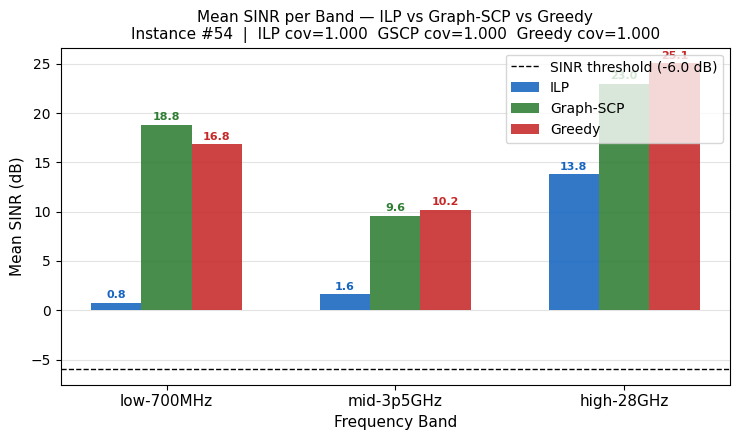


──────────────────────────────────────────────────────────
  Band                  ILP    Graph-SCP     Greedy
──────────────────────────────────────────────────────────
  low-700MHz         0.75 dB    18.80 dB    16.84 dB
  mid-3p5GHz         1.60 dB     9.59 dB    10.21 dB
  high-28GHz        13.79 dB    22.97 dB    25.07 dB
──────────────────────────────────────────────────────────


TRUST scores per BS:


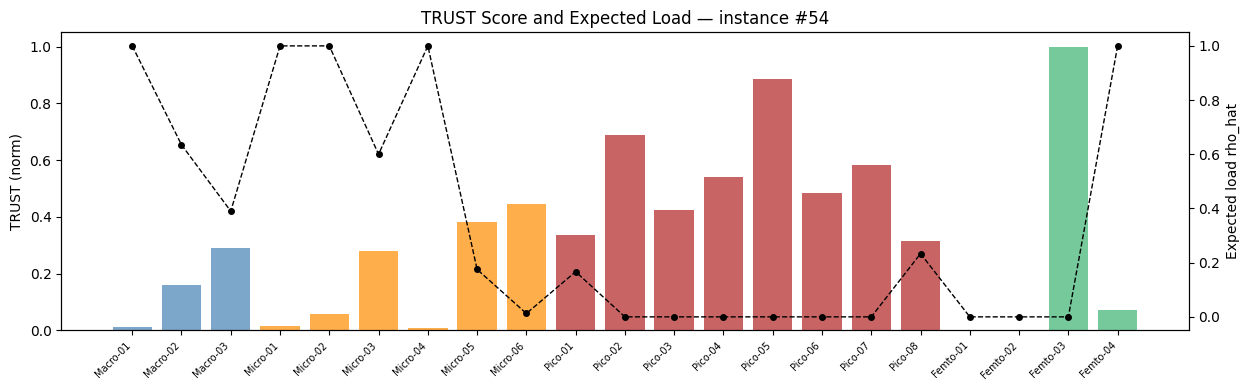

In [117]:
# ── Run ───────────────────────────────────────────────────────────────────────
plot_sinr_three_way(inst_idx=54)
_trust_diag(inst_idx=54)

## DEPTH PLOT 3 ALGORITHMS

In [102]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell — Comparative Visualisation: ILP vs Graph-SCP vs Greedy
#        3-panel layout (one panel per algorithm)
#        Association lines coloured by BS type (same-BS=dotted, switched=black-dash)
#        Unserved UEs → red ✕ + dashed red line to nearest feasible BS
#        SINR heatmap on the right half of each panel
# ══════════════════════════════════════════════════════════════════════════════

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np


def plot_three_way_comparison(inst_idx: int = 0, ref: str = "ilp"):
    """
    Plot ILP / Graph-SCP / Greedy side-by-side for one test instance.

    inst_idx : index into sampled_test_dataset
    ref      : which algo is the "reference" for switched-BS detection
               ('ilp' → GSCP & Greedy panels highlight UEs that moved vs ILP)
    """
    if inst_idx >= len(sampled_test_dataset):
        raise IndexError(f"inst_idx={inst_idx} out of range (dataset has {len(sampled_test_dataset)} items).")

    # ── Pull instance ─────────────────────────────────────────────────────────
    d       = sampled_test_dataset[inst_idx]
    cg      = d["cg"].numpy()   if isinstance(d["cg"],   torch.Tensor) else d["cg"]
    feas    = d["feas"].numpy() if isinstance(d["feas"], torch.Tensor) else d["feas"]
    ue_xy   = d["xy"].numpy()   if isinstance(d["xy"],   torch.Tensor) else d["xy"]
    n_ue    = cg.shape[0]
    meta    = d.get("meta", {})
    nue_tag = meta.get("nue", n_ue)
    tt_tag  = meta.get("traffictype", "?")

    # ── Run all three solvers ─────────────────────────────────────────────────
    ilp_res  = ilp_solver(cg, coverage_target=TARGET_COVERAGE)
    gscp_res = graph_scp_infer(cg, feas, bs_ct, model, physics)
    gr_res   = greedy_set_cover(cg, bs_ct, physics)

    # ── Re-derive sv / sg / lr from each active_mask ─────────────────────────
    # None of the three solvers return sv/sg directly; recover via greedy_association
    sv_ilp,  sg_ilp,  lu_ilp,  lr_ilp,  _ = physics["greedy_association"](cg, ilp_res["active_mask"])
    sv_gscp, sg_gscp, lu_gscp, lr_gscp, _ = physics["greedy_association"](cg, gscp_res["active_mask"])
    sv_gr,   sg_gr,   lu_gr,   lr_gr,   _ = physics["greedy_association"](cg, gr_res["active_mask"])

    am_ilp  = ilp_res["active_mask"].astype(bool)
    am_gscp = gscp_res["active_mask"].astype(bool)
    am_gr   = gr_res["active_mask"].astype(bool)

    # ── SINR matrices ─────────────────────────────────────────────────────────
    sr_ilp  = physics["sinr_dB"](cg, ilp_res["active_mask"])
    sr_gscp = physics["sinr_dB"](cg, gscp_res["active_mask"])
    sr_gr   = physics["sinr_dB"](cg, gr_res["active_mask"])

    def sinr_vec(sv, sg, sr):
        idx  = np.where(sv & (sg >= 0))[0]
        vals = np.array([sr[i, sg[i]] for i in idx], dtype=np.float64) if len(idx) else np.array([])
        return idx, vals

    served_ilp,  sinr_ilp  = sinr_vec(sv_ilp,  sg_ilp,  sr_ilp)
    served_gscp, sinr_gscp = sinr_vec(sv_gscp, sg_gscp, sr_gscp)
    served_gr,   sinr_gr   = sinr_vec(sv_gr,   sg_gr,   sr_gr)

    unserved_ilp  = np.where(~sv_ilp)[0]
    unserved_gscp = np.where(~sv_gscp)[0]
    unserved_gr   = np.where(~sv_gr)[0]

    # ── Reference for "BS switched" detection ────────────────────────────────
    ref_sg = {"ilp": sg_ilp, "gscp": sg_gscp, "greedy": sg_gr}[ref]

    def switched_mask(sg_algo, sv_algo):
        """UEs served by both ref and algo but assigned to a DIFFERENT BS."""
        switched = np.zeros(n_ue, dtype=bool)
        for i in range(n_ue):
            if sv_algo[i] and sv_ilp[i] and sg_algo[i] != ref_sg[i]:
                switched[i] = True
        return switched

    sw_gscp = switched_mask(sg_gscp, sv_gscp)
    sw_gr   = switched_mask(sg_gr,   sv_gr)

    # ── Style constants ───────────────────────────────────────────────────────
    CT_COLORS  = ["#1565C0", "#2E7D32", "#6A1B9A", "#E65100"]
    CT_MARKERS = ["triangle-up", "square", "diamond", "circle"]
    CT_SIZES   = [34, 28, 22, 18]
    CT_LABELS  = CELL_TYPE_NAMES
    NUMBS      = len(bs_ct)

    # ── Layout: 3 rows × 2 cols (left=topology, right=SINR) ─────────────────
    ALGO_CONFIGS = [
        ("ILP",       sv_ilp,  sg_ilp,  served_ilp,  sinr_ilp,  unserved_ilp,
         lr_ilp,  am_ilp,  sr_ilp,  None,    ilp_res["power_w"],  ilp_res["served_frac"]),
        ("Graph-SCP", sv_gscp, sg_gscp, served_gscp, sinr_gscp, unserved_gscp,
         lr_gscp, am_gscp, sr_gscp, sw_gscp, gscp_res["power_w"], gscp_res["served_frac"]),
        ("Greedy",    sv_gr,   sg_gr,   served_gr,   sinr_gr,   unserved_gr,
         lr_gr,   am_gr,   sr_gr,   sw_gr,   gr_res["power_w"],   gr_res["served_frac"]),
    ]

    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=[
            "ILP — Associations",       "ILP — SINR (dB)",
            "Graph-SCP — Associations", "Graph-SCP — SINR (dB)",
            "Greedy — Associations",    "Greedy — SINR (dB)",
        ],
        horizontal_spacing=0.05,
        vertical_spacing=0.06,
    )

    for row_i, (
        algo_name, sv, sg, served_idx, sinr_vals, unserved_idx,
        lr, am, sr, sw, pwr_w, cov_frac
    ) in enumerate(ALGO_CONFIGS, start=1):

        # ── Coverage circles (both cols) ──────────────────────────────────────
        for col_idx in [1, 2]:
            for j in range(NUMBS):
                ct = bs_ct[j]
                # filled disc (low opacity)
                fig.add_shape(
                    type="circle",
                    x0=bs_xy_t[j, 0] - MAX_DIST_M[ct], y0=bs_xy_t[j, 1] - MAX_DIST_M[ct],
                    x1=bs_xy_t[j, 0] + MAX_DIST_M[ct], y1=bs_xy_t[j, 1] + MAX_DIST_M[ct],
                    fillcolor=CT_COLORS[ct], line_width=0,
                    opacity=0.03, layer="below", row=row_i, col=col_idx,
                )
                # border ring
                fig.add_shape(
                    type="circle",
                    x0=bs_xy_t[j, 0] - MAX_DIST_M[ct], y0=bs_xy_t[j, 1] - MAX_DIST_M[ct],
                    x1=bs_xy_t[j, 0] + MAX_DIST_M[ct], y1=bs_xy_t[j, 1] + MAX_DIST_M[ct],
                    fillcolor="rgba(0,0,0,0)",
                    line=dict(color=CT_COLORS[ct], width=3.0, dash="solid"),
                    opacity=0.65, layer="below", row=row_i, col=col_idx,
                )

        # ── Association lines — col 1 only ────────────────────────────────────
        # ① Normal served: coloured dotted line to assigned BS
        for ct_idx in range(4):
            cx, cy = [], []
            for i in served_idx:
                if sw is not None and sw[i]:
                    continue  # drawn separately as switched
                j = sg[i]
                if j >= 0 and bs_ct[j] == ct_idx:
                    cx.extend([ue_xy[i, 0], bs_xy_t[j, 0], None])
                    cy.extend([ue_xy[i, 1], bs_xy_t[j, 1], None])
            if cx:
                fig.add_trace(go.Scatter(
                    x=cx, y=cy, mode="lines",
                    line=dict(width=1.4, color=CT_COLORS[ct_idx], dash="dot"),
                    opacity=0.65, hoverinfo="none", showlegend=False,
                ), row=row_i, col=1)

        # ② Switched UEs (changed BS vs ILP reference): black dashed lines
        if sw is not None:
            cx_sw, cy_sw = [], []
            for i in np.where(sw)[0]:
                j = sg[i]
                if j >= 0:
                    cx_sw.extend([ue_xy[i, 0], bs_xy_t[j, 0], None])
                    cy_sw.extend([ue_xy[i, 1], bs_xy_t[j, 1], None])
            if cx_sw:
                fig.add_trace(go.Scatter(
                    x=cx_sw, y=cy_sw, mode="lines",
                    line=dict(width=1.8, color="black", dash="dash"),
                    opacity=0.80, name="BS switched vs ILP",
                    hoverinfo="none",
                    showlegend=(row_i == 2),  # show in legend once (Graph-SCP row)
                ), row=row_i, col=1)

        # ③ Unserved: red dotted line to nearest feasible BS (if any exists)
        for i in unserved_idx:
            feasible_bs = np.where(sr[i] >= SINR_THRESH_DB)[0]
            if len(feasible_bs):
                j_near = feasible_bs[np.argmax(sr[i, feasible_bs])]
                fig.add_trace(go.Scatter(
                    x=[ue_xy[i, 0], bs_xy_t[j_near, 0]],
                    y=[ue_xy[i, 1], bs_xy_t[j_near, 1]],
                    mode="lines",
                    line=dict(width=1.2, color="red", dash="dot"),
                    opacity=0.55, hoverinfo="none", showlegend=False,
                ), row=row_i, col=1)

        # ── Served UEs — col 1 (coloured by serving BS type) ─────────────────
        normal_served   = served_idx[~sw[served_idx]] if sw is not None else served_idx
        switched_served = served_idx[ sw[served_idx]] if sw is not None else np.array([], dtype=int)

        if len(normal_served):
            fig.add_trace(go.Scatter(
                x=ue_xy[normal_served, 0], y=ue_xy[normal_served, 1],
                mode="markers",
                marker=dict(
                    size=5,
                    color=[CT_COLORS[bs_ct[sg[i]]] for i in normal_served],
                    opacity=0.85,
                ),
                name="Served UE", hoverinfo="none",
                showlegend=(row_i == 1),
            ), row=row_i, col=1)

        if len(switched_served):
            fig.add_trace(go.Scatter(
                x=ue_xy[switched_served, 0], y=ue_xy[switched_served, 1],
                mode="markers",
                marker=dict(
                    size=6, symbol="circle-open",
                    color=[CT_COLORS[bs_ct[sg[i]]] for i in switched_served],
                    line=dict(width=1.8, color="black"),
                    opacity=0.9,
                ),
                name="UE: BS switched", hoverinfo="none",
                showlegend=(row_i == 2),
            ), row=row_i, col=1)

        # ── Unserved UEs — col 1 (red ✕) ─────────────────────────────────────
        if len(unserved_idx):
            fig.add_trace(go.Scatter(
                x=ue_xy[unserved_idx, 0], y=ue_xy[unserved_idx, 1],
                mode="markers",
                marker=dict(symbol="x", size=8, color="red",
                            line=dict(width=2.0, color="red")),
                name="Unserved UE", hoverinfo="none",
                showlegend=(row_i == 1),
            ), row=row_i, col=1)

        # ── SINR panel — col 2 ────────────────────────────────────────────────
        if len(served_idx):
            fig.add_trace(go.Scatter(
                x=ue_xy[served_idx, 0], y=ue_xy[served_idx, 1],
                mode="markers",
                marker=dict(
                    size=6, color=sinr_vals,
                    colorscale="RdYlGn", cmin=-10, cmax=20,
                    colorbar=dict(
                        title="SINR (dB)",
                        x=1.02, len=0.3,
                        y=1.0 - (row_i - 1) / 3.0 - 0.12,
                        yanchor="top",
                    ),
                    showscale=True,
                ),
                text=[f"SINR: {s:.1f} dB" for s in sinr_vals],
                hoverinfo="text", showlegend=False,
            ), row=row_i, col=2)

        if len(unserved_idx):
            fig.add_trace(go.Scatter(
                x=ue_xy[unserved_idx, 0], y=ue_xy[unserved_idx, 1],
                mode="markers",
                marker=dict(symbol="x", size=7, color="red",
                            line=dict(width=1.8, color="red")),
                hoverinfo="none", showlegend=False,
            ), row=row_i, col=2)

        # ── Base stations — both cols ─────────────────────────────────────────
        for col_idx in [1, 2]:
            for ct_idx in range(4):
                mask        = (bs_ct == ct_idx)
                active_ct   = mask & am
                inactive_ct = mask & ~am

                if active_ct.any():
                    hover_txts, label_txts, lx, ly = [], [], [], []
                    for j in np.where(active_ct)[0]:
                        r     = bs_df_t.iloc[j]
                        pwr_j = P0_W[ct_idx] + DELTA_P[ct_idx] * P_TX_W[ct_idx] * float(np.clip(lr[j], 0, 1))
                        hover_txts.append(
                            f"<b>{r['label']} (ACTIVE)</b><br>"
                            f"Type: {CT_LABELS[ct_idx]}<br>"
                            f"x={r['xm']:.0f} m  y={r['ym']:.0f} m<br>"
                            f"Load={lr[j]*100:.1f}%  Power={pwr_j:.1f} W"
                        )
                        label_txts.append(f"<b>[{j}]</b><br>{pwr_j:.0f}W")
                        lx.append(float(r["xm"]))
                        ly.append(float(r["ym"]))

                    fig.add_trace(go.Scatter(
                        x=bs_xy_t[active_ct, 0], y=bs_xy_t[active_ct, 1],
                        mode="markers",
                        marker=dict(
                            symbol=CT_MARKERS[ct_idx], size=CT_SIZES[ct_idx],
                            color=CT_COLORS[ct_idx],
                            line=dict(color="black", width=2.5),
                        ),
                        name=f"{CT_LABELS[ct_idx]} (Active)",
                        text=hover_txts, hoverinfo="text",
                        showlegend=(col_idx == 1 and row_i == 1),
                    ), row=row_i, col=col_idx)

                    if col_idx == 1:  # labels on topology panel only
                        fig.add_trace(go.Scatter(
                            x=[x + 18 for x in lx], y=ly,
                            mode="text", text=label_txts,
                            textposition="middle right",
                            textfont=dict(size=9, color="black", family="Arial Black"),
                            hoverinfo="none", showlegend=False,
                        ), row=row_i, col=col_idx)

                if inactive_ct.any():
                    hover_txts = []
                    for j in np.where(inactive_ct)[0]:
                        r = bs_df_t.iloc[j]
                        hover_txts.append(
                            f"<b>{r['label']} (SLEEP)</b><br>"
                            f"Type: {CT_LABELS[ct_idx]}<br>"
                            f"Psleep={P_SLEEP_W[ct_idx]:.2f} W"
                        )
                    fig.add_trace(go.Scatter(
                        x=bs_xy_t[inactive_ct, 0], y=bs_xy_t[inactive_ct, 1],
                        mode="markers",
                        marker=dict(
                            symbol=CT_MARKERS[ct_idx], size=CT_SIZES[ct_idx],
                            color="#aaaaaa",
                            line=dict(color="#555555", width=2.0),
                            opacity=0.45,
                        ),
                        name=f"{CT_LABELS[ct_idx]} (Sleep)",
                        text=hover_txts, hoverinfo="text",
                        showlegend=(col_idx == 1 and row_i == 1),
                    ), row=row_i, col=col_idx)

            # Area boundary
            fig.add_shape(
                type="rect", x0=0, y0=0, x1=AREA_M, y1=AREA_M,
                line=dict(color="#888888", width=1.5),
                row=row_i, col=col_idx,
            )

        # ── Per-row power annotation ──────────────────────────────────────────
        ilp_gap   = (pwr_w - ilp_res["power_w"]) / ilp_res["power_w"] * 100 if algo_name != "ILP"    else 0.0
        gr_saving = (gr_res["power_w"] - pwr_w)  / gr_res["power_w"]  * 100 if algo_name != "Greedy" else 0.0
        note      = (f"  |  ILP-gap: +{ilp_gap:.1f}%  Greedy-saving: {gr_saving:.1f}%"
                     if algo_name != "ILP" else "  |  ← oracle reference")

        fig.add_annotation(
            text=(f"<b>{algo_name}</b>  Power={pwr_w:.1f} W  "
                  f"Coverage={cov_frac:.3f}  "
                  f"Active BSs={int(am.sum())}/{NUMBS}{note}"),
            align="left", showarrow=False,
            xref="paper", yref="paper",
            x=0.0, y=1.0 - (row_i - 1) / 3.0 + 0.01,
            bgcolor="#f9f9f9", bordercolor="#cccccc", borderwidth=1,
            font=dict(size=11, family="monospace", color="#222222"),
        )

    # ── Global layout ─────────────────────────────────────────────────────────
    fig.update_layout(
        title=dict(
            text=(f"<b>ILP vs Graph-SCP vs Greedy — Comparative HetNet View</b><br>"
                  f"<sup>Instance #{inst_idx} · {tt_tag.title()} traffic · "
                  f"{nue_tag} UEs · {NUMBS} BSs · "
                  f"Ref for BS-switch detection: {ref.upper()}</sup>"),
            x=0.5, font=dict(size=19),
        ),
        width=1750, height=2200,
        margin=dict(t=120, b=60, l=60, r=80),
        paper_bgcolor="white",
        plot_bgcolor="white",
        hoverlabel=dict(bgcolor="white", font_size=13, font_family="Arial"),
        legend=dict(
            title=dict(text="<b>Legend</b>", font=dict(size=12)),
            yanchor="top", y=0.99, xanchor="left", x=0.01,
            bgcolor="rgba(255,255,255,0.92)",
            bordercolor="#999", borderwidth=1.5,
            font=dict(size=12), tracegroupgap=3,
        ),
    )

    fig.update_xaxes(
        range=[-50, AREA_M + 50], title_text="x (m)",
        gridcolor="#ebebeb", zeroline=False,
    )
    fig.update_yaxes(
        range=[-50, AREA_M + 50], title_text="y (m)",
        gridcolor="#ebebeb", zeroline=False,
        scaleanchor="x", scaleratio=1,
    )

    fig.show()

    # ── Summary print ─────────────────────────────────────────────────────────
    print(f"\n{'─'*60}")
    print(f"  Instance #{inst_idx}  |  {tt_tag}  |  {nue_tag} UEs")
    print(f"{'─'*60}")
    print(f"  {'Algorithm':<12} {'Power (W)':>10} {'Coverage':>10} {'Active BS':>10} {'Unserved':>10}")
    print(f"{'─'*60}")
    for name, pwr, cov, am_, unserved in [
        ("ILP",       ilp_res["power_w"],  ilp_res["served_frac"],  am_ilp,  unserved_ilp),
        ("Graph-SCP", gscp_res["power_w"], gscp_res["served_frac"], am_gscp, unserved_gscp),
        ("Greedy",    gr_res["power_w"],   gr_res["served_frac"],   am_gr,   unserved_gr),
    ]:
        print(f"  {name:<12} {pwr:>10.1f} {cov:>10.4f} {int(am_.sum()):>10} {len(unserved):>10}")
    ilp_gap  = (gscp_res["power_w"] - ilp_res["power_w"]) / ilp_res["power_w"] * 100
    gr_save  = (gr_res["power_w"] - gscp_res["power_w"]) / gr_res["power_w"] * 100
    sw_count = int(sw_gscp.sum())
    print(f"{'─'*60}")
    print(f"  GSCP ILP-gap: +{ilp_gap:.2f}%  |  GSCP saves {gr_save:.1f}% vs Greedy")
    print(f"  UEs that switched BS (GSCP vs ILP): {sw_count}")
    print(f"{'─'*60}\n")




In [108]:
# ── Run ───────────────────────────────────────────────────────────────────────
plot_three_way_comparison(inst_idx=54, ref="ilp")


────────────────────────────────────────────────────────────
  Instance #54  |  ?  |  850 UEs
────────────────────────────────────────────────────────────
  Algorithm     Power (W)   Coverage  Active BS   Unserved
────────────────────────────────────────────────────────────
  ILP              1020.6     1.0000         16         43
  Graph-SCP        1923.8     1.0000         18          0
  Greedy           1825.2     1.0000         10          0
────────────────────────────────────────────────────────────
  GSCP ILP-gap: +88.50%  |  GSCP saves -5.4% vs Greedy
  UEs that switched BS (GSCP vs ILP): 334
────────────────────────────────────────────────────────────



## 32. Energy Savings Bar Chart Across UE Counts

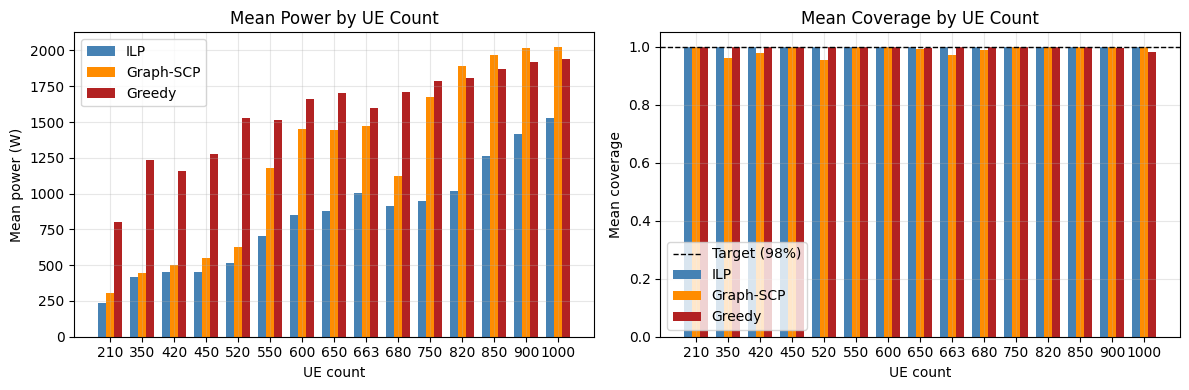


--- Energy savings vs Greedy baseline ---
  ILP  saves: 50.6% on average vs Greedy
  GSCP saves: 28.6% on average vs Greedy


In [118]:
# Cell 28 — Energy Savings Bar Chart Across UE Counts

if len(feasible_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Mean power by n_ue
    ax = axes[0]
    grouped = feasible_df.groupby('n_ue')[['ilp_power','gscp_power','greedy_power']].mean()
    x = np.arange(len(grouped))
    w = 0.25
    ax.bar(x - w, grouped['ilp_power'],    width=w, label='ILP',       color='steelblue')
    ax.bar(x,     grouped['gscp_power'],   width=w, label='Graph-SCP', color='darkorange')
    ax.bar(x + w, grouped['greedy_power'], width=w, label='Greedy',    color='firebrick')
    ax.set_xticks(x); ax.set_xticklabels(grouped.index)
    ax.set_xlabel('UE count'); ax.set_ylabel('Mean power (W)')
    ax.set_title('Mean Power by UE Count'); ax.legend(); ax.grid(alpha=0.3)

    # Mean coverage by n_ue
    ax = axes[1]
    grouped_cov = feasible_df.groupby('n_ue')[['ilp_cov','gscp_cov','greedy_cov']].mean()
    ax.bar(x - w, grouped_cov['ilp_cov'],    width=w, label='ILP',       color='steelblue')
    ax.bar(x,     grouped_cov['gscp_cov'],   width=w, label='Graph-SCP', color='darkorange')
    ax.bar(x + w, grouped_cov['greedy_cov'], width=w, label='Greedy',    color='firebrick')
    ax.axhline(TARGET_COVERAGE, linestyle='--', color='black', linewidth=1, label='Target (98%)')
    ax.set_xticks(x); ax.set_xticklabels(grouped_cov.index)
    ax.set_xlabel('UE count'); ax.set_ylabel('Mean coverage')
    ax.set_title('Mean Coverage by UE Count'); ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout(); plt.show()

    # Energy savings vs greedy
    print('\n--- Energy savings vs Greedy baseline ---')
    ilp_save  = (feasible_df['greedy_power'] - feasible_df['ilp_power'])  / feasible_df['greedy_power']
    gscp_save = (feasible_df['greedy_power'] - feasible_df['gscp_power']) / feasible_df['greedy_power']
    print(f'  ILP  saves: {ilp_save.mean():.1%} on average vs Greedy')
    print(f'  GSCP saves: {gscp_save.mean():.1%} on average vs Greedy')

## 33. Training Curves (Thesis Figures)

**Source: June 4 (enhanced multi-panel layout).**

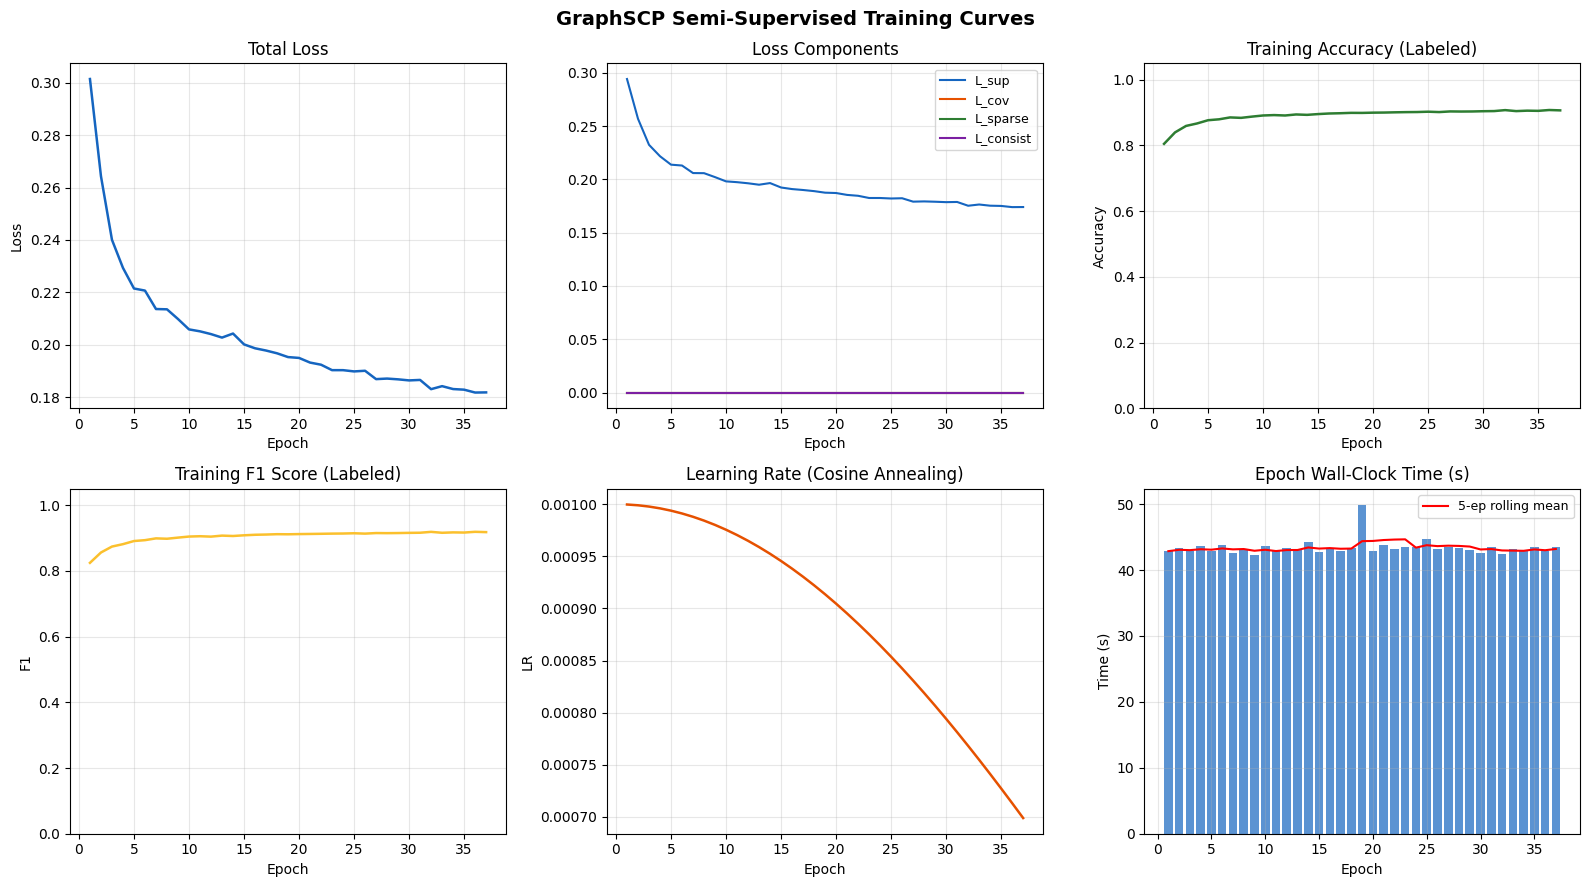

Saved training_curves.png


In [119]:

if not history['epoch']:
    print("history is empty — run Cell 32 (training loop) first.")
else:
    epochs_arr = np.array(history['epoch'])

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle('GraphSCP Semi-Supervised Training Curves', fontsize=14, fontweight='bold')

    # Total loss
    axes[0, 0].plot(epochs_arr, history['loss_total'], color='#1565C0', lw=1.8)
    axes[0, 0].set_title('Total Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)

    # Loss components
    axes[0, 1].plot(epochs_arr, history['loss_sup'],     label='L_sup',     color='#1565C0', lw=1.5)
    axes[0, 1].plot(epochs_arr, history['loss_cov'],     label='L_cov',     color='#E65100', lw=1.5)
    axes[0, 1].plot(epochs_arr, history['loss_sparse'],  label='L_sparse',  color='#2E7D32', lw=1.5)
    axes[0, 1].plot(epochs_arr, history['loss_consist'], label='L_consist', color='#7B1FA2', lw=1.5)
    axes[0, 1].set_title('Loss Components')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend(fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)

    # Training accuracy
    axes[0, 2].plot(epochs_arr, history['train_acc'], color='#2E7D32', lw=1.8)
    axes[0, 2].set_ylim(0, 1.05)
    axes[0, 2].set_title('Training Accuracy (Labeled)')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Accuracy')
    axes[0, 2].grid(True, alpha=0.3)

    # Training F1
    axes[1, 0].plot(epochs_arr, history['train_f1'], color='#FBC02D', lw=1.8)
    axes[1, 0].set_ylim(0, 1.05)
    axes[1, 0].set_title('Training F1 Score (Labeled)')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('F1')
    axes[1, 0].grid(True, alpha=0.3)

    # Learning rate schedule
    axes[1, 1].plot(epochs_arr, history['lr'], color='#E65100', lw=1.8)
    axes[1, 1].set_title('Learning Rate (Cosine Annealing)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('LR')
    axes[1, 1].grid(True, alpha=0.3)

    # Epoch wall-clock time
    axes[1, 2].bar(epochs_arr, history['epoch_times'], color='#1565C0', alpha=0.7)
    axes[1, 2].plot(epochs_arr,
                    pd.Series(history['epoch_times']).rolling(5, min_periods=1).mean(),
                    color='red', lw=1.5, label='5-ep rolling mean')
    axes[1, 2].set_title('Epoch Wall-Clock Time (s)')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('Time (s)')
    axes[1, 2].legend(fontsize=9)
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved training_curves.png")

## 34. Evaluation Visualisations (Thesis Figures)

**Source: June 4.**

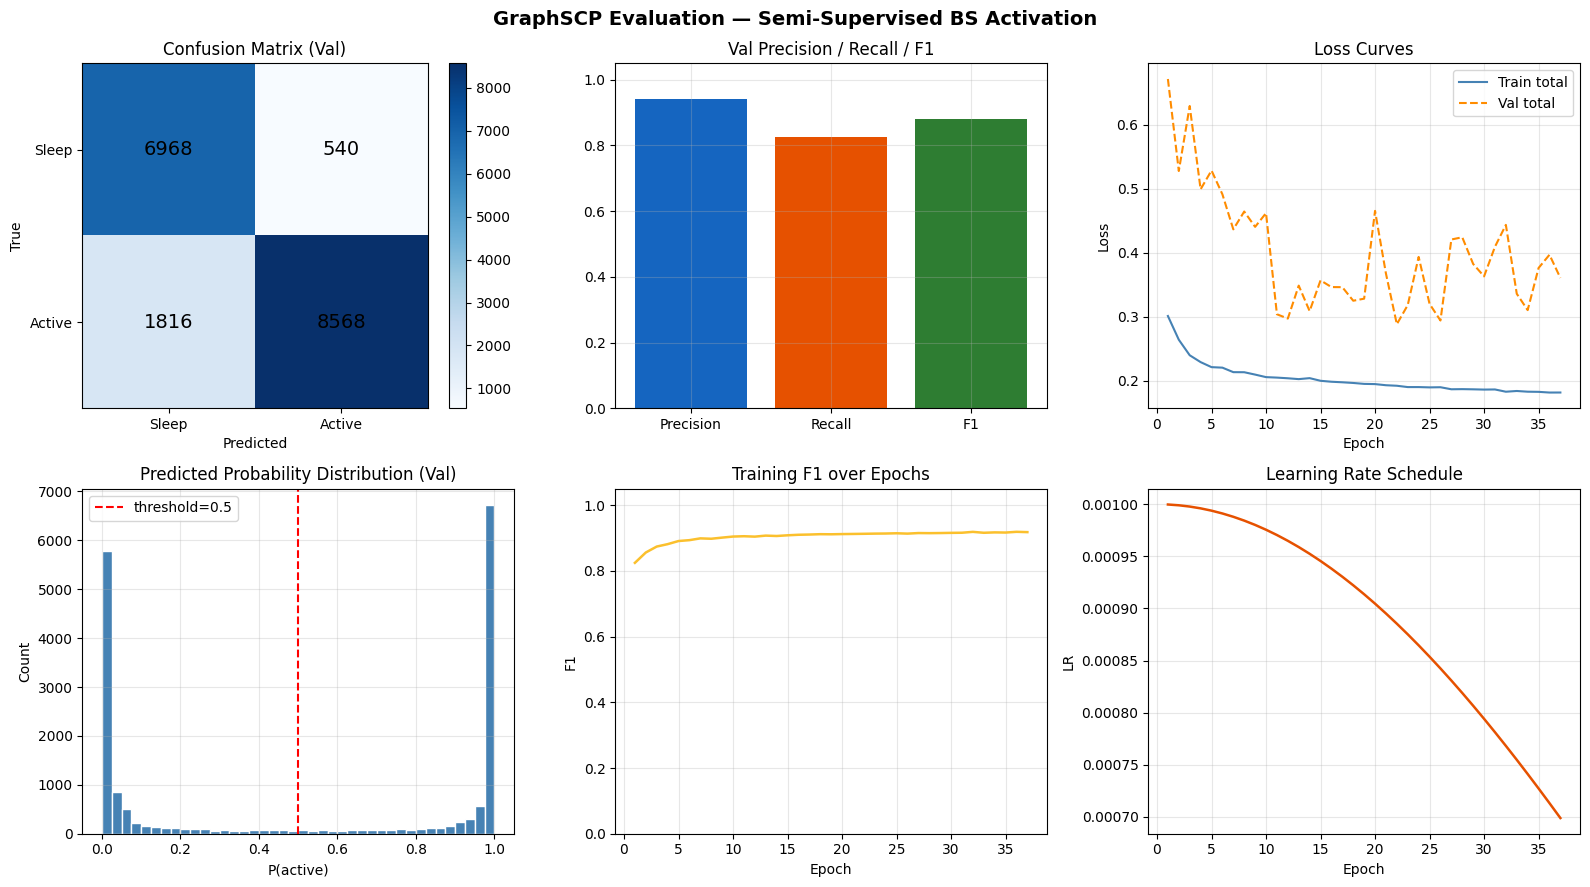

Saved eval_thesis_figures.png


In [120]:
# Cell 34 — Evaluation Visualisations (Thesis Figures)
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

# Build all_labels_arr / all_preds_arr from val_set
model.eval()
all_preds_arr  = []
all_labels_arr = []

with torch.no_grad():
    for d in val_set:
        feat      = d['F'].to(DEVICE)
        ei        = d['edge_index'].to(DEVICE)
        ea        = d['edge_attr'].to(DEVICE)
        labels_bs = d['labels_bs']
        m_val = d['m']
        n_val = d['n']

        logits_all = model(feat, ei, ea)
        logits_bs  = logits_all[1 + m_val: 1 + m_val + n_val]
        preds = (torch.sigmoid(logits_bs) >= 0.5).float().cpu()

        all_preds_arr.extend(preds.tolist())
        all_labels_arr.extend(labels_bs.tolist())

all_preds_arr  = np.array(all_preds_arr)
all_labels_arr = np.array(all_labels_arr)

# --- Plot ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('GraphSCP Evaluation — Semi-Supervised BS Activation',
             fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(all_labels_arr, all_preds_arr)
im = axes[0, 0].imshow(cm, cmap='Blues', aspect='auto')
plt.colorbar(im, ax=axes[0, 0])
axes[0, 0].set_xticks([0, 1]); axes[0, 0].set_yticks([0, 1])
axes[0, 0].set_xticklabels(['Sleep', 'Active'])
axes[0, 0].set_yticklabels(['Sleep', 'Active'])
for i in range(2):
    for j in range(2):
        axes[0, 0].text(j, i, str(cm[i, j]),
                        ha='center', va='center', fontsize=14, color='black')
axes[0, 0].set_title('Confusion Matrix (Val)')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('True')

# Precision / Recall / F1 bar
from sklearn.metrics import precision_score, recall_score, f1_score
prec = precision_score(all_labels_arr, all_preds_arr, zero_division=0)
rec  = recall_score(all_labels_arr, all_preds_arr, zero_division=0)
f1   = f1_score(all_labels_arr, all_preds_arr, zero_division=0)
axes[0, 1].bar(['Precision', 'Recall', 'F1'], [prec, rec, f1],
               color=['#1565C0', '#E65100', '#2E7D32'])
axes[0, 1].set_ylim(0, 1.05)
axes[0, 1].set_title('Val Precision / Recall / F1')
axes[0, 1].grid(True, alpha=0.3)

# Loss curves (from history)
if history['epoch']:
    epochs_arr = np.array(history['epoch'])
    axes[0, 2].plot(epochs_arr, history['loss_total'], label='Train total', color='steelblue')
    axes[0, 2].plot(epochs_arr, val_losses,            label='Val total',   color='darkorange', linestyle='--')
    axes[0, 2].set_title('Loss Curves')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('Loss')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)

# Pred probability histogram
probs_all = []
model.eval()
with torch.no_grad():
    for d in val_set:
        feat = d['F'].to(DEVICE)
        ei   = d['edge_index'].to(DEVICE)
        ea   = d['edge_attr'].to(DEVICE)
        m_val = d['m']; n_val = d['n']
        logits_all = model(feat, ei, ea)
        logits_bs  = logits_all[1 + m_val: 1 + m_val + n_val]
        probs_all.extend(torch.sigmoid(logits_bs).cpu().tolist())

axes[1, 0].hist(probs_all, bins=40, color='steelblue', edgecolor='white')
axes[1, 0].axvline(0.5, color='red', linestyle='--', lw=1.5, label='threshold=0.5')
axes[1, 0].set_title('Predicted Probability Distribution (Val)')
axes[1, 0].set_xlabel('P(active)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# F1 vs epoch
if history['train_f1']:
    axes[1, 1].plot(epochs_arr, history['train_f1'], color='#FBC02D', lw=1.8)
    axes[1, 1].set_ylim(0, 1.05)
    axes[1, 1].set_title('Training F1 over Epochs')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('F1')
    axes[1, 1].grid(True, alpha=0.3)

# LR schedule
if history['lr']:
    axes[1, 2].plot(epochs_arr, history['lr'], color='#E65100', lw=1.8)
    axes[1, 2].set_title('Learning Rate Schedule')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('LR')
    axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}eval_thesis_figures.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved eval_thesis_figures.png")

## 35. Per-BS Activation Probability Heatmap (Spatial)

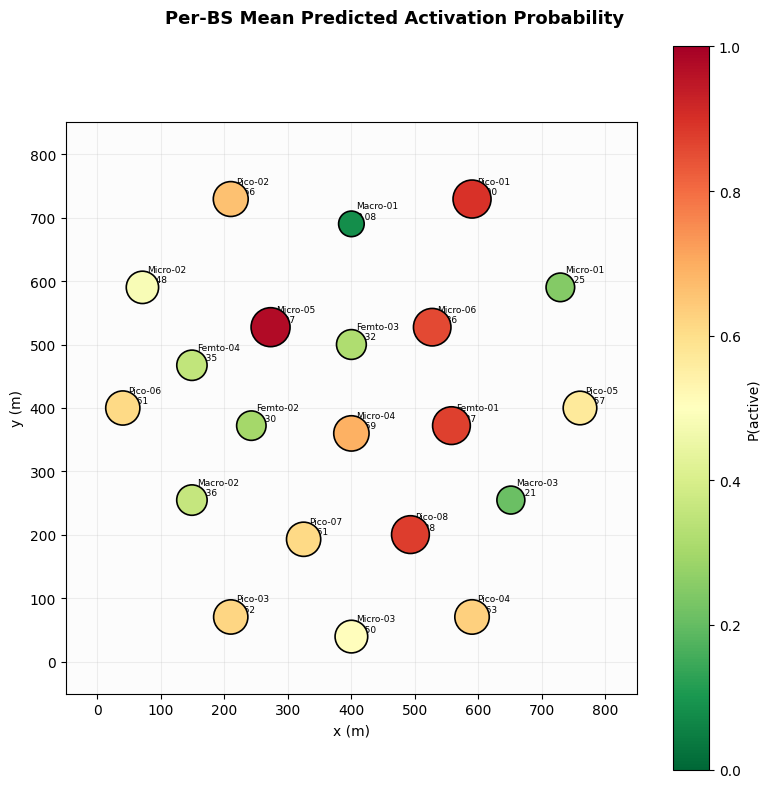

Saved: bs_activation_heatmap.png


In [123]:
# ── Cell 35: Per-BS Mean Predicted Activation Probability Heatmap ─────────
model.eval()
bs_mean_probs = np.zeros(NUMBS, dtype=np.float32)
count_samples = 0

# Use sampledtestdataset if available, else fall back to testdataset
_eval_set = sampled_test_dataset if 'sampledtestdataset' in dir() and len(sampled_test_dataset) > 0 else test_dataset

with torch.no_grad():
    for d in _eval_set:                                        # ✅ iterate dicts
        nf  = d['F'].to(DEVICE)
        ei  = d['edge_index'].to(DEVICE)
        ea  = d['edge_attr'].to(DEVICE)
        m, n = d['m'], d['n']

        logits_all = model(nf, ei, ea)
        logits_bs  = logits_all[1*m : 1*m + n]                # BS nodes only
        probs      = torch.sigmoid(logits_bs).cpu().numpy()   # shape (n,) == (NUMBS,)

        bs_mean_probs += probs
        count_samples += 1

bs_mean_probs /= max(count_samples, 1)

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
fig.suptitle("Per-BS Mean Predicted Activation Probability", fontsize=13, fontweight="bold")

sc = ax.scatter(
    bs_xy[:, 0], bs_xy[:, 1],
    c=bs_mean_probs,
    s=300 + 500 * bs_mean_probs,
    cmap="RdYlGn_r",
    vmin=0.0, vmax=1.0,
    edgecolors="black", linewidths=1.2, zorder=5,
)
plt.colorbar(sc, ax=ax, label="P(active)")

for j in range(NUMBS):
    ax.text(bs_xy[j, 0] + 8, bs_xy[j, 1] + 8,
            f"{bs_df['label'].iloc[j]}\n{bs_mean_probs[j]:.2f}",
            fontsize=6.5, color="black")

ax.set_xlim(-50, AREA_M + 50); ax.set_ylim(-50, AREA_M + 50)
ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)")
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)
ax.set_facecolor("#fcfcfc")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/bs_activation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: bs_activation_heatmap.png")

## 36. Threshold Sensitivity Analysis (Thesis Ablation)

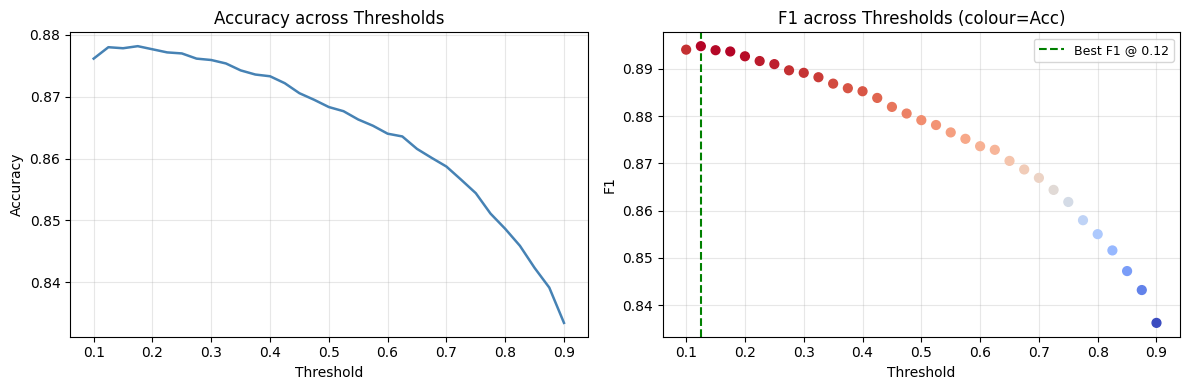

Best F1 threshold 0.12  F1=0.8948
Saved threshold_sensitivity.png


In [126]:
# Cell 35 — Threshold Sensitivity

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score

if 'all_labels_arr' not in dir() or len(all_labels_arr) == 0:
    print("Run Cell 34 first to build all_labels_arr / all_preds_arr.")
else:
    # Collect raw probabilities for threshold sweep
    probs_sweep = []
    labels_sweep = []
    model.eval()
    with torch.no_grad():
        for d in val_set:
            feat      = d['F'].to(DEVICE)
            ei        = d['edge_index'].to(DEVICE)
            ea        = d['edge_attr'].to(DEVICE)
            labels_bs = d['labels_bs']
            m_val = d['m']; n_val = d['n']
            logits_all = model(feat, ei, ea)
            logits_bs  = logits_all[1 + m_val: 1 + m_val + n_val]
            probs_sweep.extend(torch.sigmoid(logits_bs).cpu().tolist())
            labels_sweep.extend(labels_bs.tolist())

    probs_sweep  = np.array(probs_sweep)
    labels_sweep = np.array(labels_sweep)

    thresholds = np.linspace(0.1, 0.9, 33)
    thresh_f1  = []
    thresh_acc = []
    for thr in thresholds:
        preds_thr = (probs_sweep >= thr).astype(float)
        thresh_f1.append(f1_score(labels_sweep, preds_thr, zero_division=0))
        thresh_acc.append(accuracy_score(labels_sweep, preds_thr))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(thresholds, thresh_acc, color='steelblue', lw=1.8)
    axes[0].set_title('Accuracy across Thresholds')
    axes[0].set_xlabel('Threshold')
    axes[0].set_ylabel('Accuracy')
    axes[0].grid(True, alpha=0.3)

    best_f1_thr = thresholds[np.argmax(thresh_f1)]
    axes[1].scatter(thresholds, thresh_f1, c=thresh_acc, cmap='coolwarm', s=40, zorder=5)
    axes[1].axvline(best_f1_thr, color='green', ls='--', lw=1.5,
                    label=f'Best F1 @ {best_f1_thr:.2f}')
    axes[1].set_xlabel('Threshold')
    axes[1].set_ylabel('F1')
    axes[1].set_title('F1 across Thresholds (colour=Acc)')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}threshold_sensitivity.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Best F1 threshold {best_f1_thr:.2f}  F1={max(thresh_f1):.4f}")
    print("Saved threshold_sensitivity.png")

## 38. Save Model Checkpoint & History

In [124]:
# Cell 38 — Save Model Checkpoint + History
import os, pandas as pd

ckpt_path = os.path.join(OUTPUT_DIR, 'graphscp_semisup.pt')
torch.save({
    'model_state_dict':     model.state_dict(),
    'optimiser_state_dict': optimiser.state_dict(),   # correct variable name
    'history':              history,                   # full history dict
    'epoch':                GNN_EPOCHS,
    'node_feat_dim':        NODE_FEAT_DIM,
    'edge_feat_dim':        EDGE_FEAT_DIM,
    'GNN_HIDDEN':           GNN_HIDDEN,
    'GNN_LAYERS':           GNN_LAYERS,
    'GNN_DROPOUT':          GNN_DROPOUT,
}, ckpt_path)
print(f"Model saved → {ckpt_path}")

# Save history as CSV for thesis tables
hist_df  = pd.DataFrame(history)
csv_path = os.path.join(OUTPUT_DIR, 'training_history.csv')
hist_df.to_csv(csv_path, index=False)
print(f"History CSV → {csv_path}")
print(hist_df.tail(5))

Model saved → output/GraphSCPHetNet/graphscp_semisup.pt
History CSV → output/GraphSCPHetNet/training_history.csv
    epoch  loss_total  loss_sup  loss_cov  loss_sparse  loss_consist  \
32     33    0.184233  0.176482       0.0          0.0           0.0   
33     34    0.183129  0.175366       0.0          0.0           0.0   
34     35    0.182892  0.175141       0.0          0.0           0.0   
35     36    0.181796  0.174029       0.0          0.0           0.0   
36     37    0.181852  0.174097       0.0          0.0           0.0   

    train_acc  train_f1        lr  epoch_times  
32   0.904545  0.916208  0.000755    43.165985  
33   0.905906  0.917387  0.000741    42.917329  
34   0.905334  0.916895  0.000727    43.566334  
35   0.907889  0.919134  0.000713    42.871951  
36   0.906813  0.918192  0.000699    43.456617  


## 37. Full Ablation Study

Compares 4 training conditions:
- `(a) supervised_only` — BCE loss only
- `(b) full` — complete semi-supervised loss
- `(c) no_trust` — semi-supervised without TRUST slot (zeros in Slot 4)
- `(d) no_rwr` — semi-supervised without RWR (zeros in Slot 5)

**Enhancement**: capacity ablation on `MAX_USERS_PER_BS ∈ [30, 50, 70]` added for 4-tier model.

In [ ]:
# Cell 37 — Full Ablation Study (4 conditions)
import copy, torch, numpy as np, pandas as pd
from tqdm.auto import tqdm


ABLATION_EPOCHS = 40   # fast ablation — already defined, kept here for clarity


ABLATION_CONDITIONS = [
    {'name': 'supervised_only', 'ablation_mode': 'supervised_only',
     'use_trust_slot4': False, 'use_trust_edges': False},
    {'name': 'trust_slot4',     'ablation_mode': 'full',
     'use_trust_slot4': True,  'use_trust_edges': False},
    {'name': 'trust_edges',     'ablation_mode': 'full',
     'use_trust_slot4': False, 'use_trust_edges': True},
    {'name': 'full',            'ablation_mode': 'full',
     'use_trust_slot4': True,  'use_trust_edges': True},
]


def train_ablation_model(trainset, valset, bsct,                          # ✅ FIX 1: trainset/valset (no underscore)
                         ablation_mode, use_trust_slot4, use_trust_edges,
                         n_epochs=ABLATION_EPOCHS):
    """Train a fresh model for one ablation condition."""
    mdl = GraphSCPModel(in_ch=10, hidden=GNN_HIDDEN,
                        n_layers=GNN_LAYERS, dropout=GNN_DROPOUT).to(DEVICE)
    opt = torch.optim.AdamW(mdl.parameters(), lr=GNN_LR, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-6)

    best_val = float('inf')
    best_state = None

    for ep in range(1, n_epochs + 1):
        mdl.train()
        for d in trainset:                                                  # ✅ FIX 1
            F_t  = d['F'].clone().to(DEVICE)
            ei_t = d['edge_index'].to(DEVICE)
            ea_t = d['edge_attr'].clone().to(DEVICE)
            m_d  = d['m']; n_d = d['n']

            if not use_trust_slot4:
                F_t[1 + m_d: 1 + m_d + n_d, 4] = 0.0
            if not use_trust_edges:
                ea_t[:, 1] = 0.0

            labels_bs  = d['labels_bs'].to(DEVICE)
            A_full_t   = torch.tensor(d['A_full'], dtype=torch.float32).to(DEVICE)
            costs_full = d['costs_full'].to(DEVICE)

            logits_all = mdl(F_t, ei_t, ea_t)
            logits_bs  = logits_all[1 + m_d: 1 + m_d + n_d]

            loss, _, _ = graph_scp_loss(logits_bs, labels_bs, A_full_t, costs_full,
                                        ablation_mode=ablation_mode)
            opt.zero_grad(); loss.backward(); opt.step()

        # Validation
        mdl.eval(); v_loss = 0.
        with torch.no_grad():
            for d in valset:                                                # ✅ FIX 1
                F_t  = d['F'].clone().to(DEVICE)
                ei_t = d['edge_index'].to(DEVICE)
                ea_t = d['edge_attr'].clone().to(DEVICE)
                m_d  = d['m']; n_d = d['n']
                if not use_trust_slot4:
                    F_t[1 + m_d: 1 + m_d + n_d, 4] = 0.0
                if not use_trust_edges:
                    ea_t[:, 1] = 0.0
                labels_bs  = d['labels_bs'].to(DEVICE)
                A_full_t   = torch.tensor(d['A_full'], dtype=torch.float32).to(DEVICE)
                costs_full = d['costs_full'].to(DEVICE)
                logits_all = mdl(F_t, ei_t, ea_t)
                logits_bs  = logits_all[1 + m_d: 1 + m_d + n_d]
                vl, _, _ = graph_scp_loss(logits_bs, labels_bs, A_full_t, costs_full,
                                          ablation_mode=ablation_mode)
                v_loss += vl.item()

        v_mean = v_loss / max(len(valset), 1)                              # ✅ FIX 1
        if v_mean < best_val:
            best_val   = v_mean
            best_state = copy.deepcopy(mdl.state_dict())
        sch.step()

    if best_state:
        mdl.load_state_dict(best_state)
    return mdl, best_val


def evaluate_ablation_model(mdl, valset, bsct, use_trust_slot4, use_trust_edges, physics):
    """Evaluate coverage and power on valset for one ablation model."""
    greedy_assoc = physics['greedy_association']
    net_pwr      = physics['network_power_w']
    powers = []; covs = []; acc_list = []

    mdl.eval()
    with torch.no_grad():
        for d in valset:                                                    # ✅ FIX 1
            F_t  = d['F'].clone().to(DEVICE)
            ei_t = d['edge_index'].to(DEVICE)
            ea_t = d['edge_attr'].clone().to(DEVICE)
            m_d  = d['m']; n_d = d['n']
            cg_np = d['cg'].numpy() if isinstance(d['cg'], torch.Tensor) else d['cg']

            if not use_trust_slot4:
                F_t[1 + m_d: 1 + m_d + n_d, 4] = 0.0
            if not use_trust_edges:
                ea_t[:, 1] = 0.0

            logits_all = mdl(F_t, ei_t, ea_t)
            logits_bs  = logits_all[1 + m_d: 1 + m_d + n_d]
            probs = torch.sigmoid(logits_bs).cpu().numpy()
            am    = (probs >= 0.5).astype(np.int32)

            sv, sg, lu, lr, sr = greedy_assoc(cg_np, am)                  # ✅ FIX 2: 5-value unpack
            covs.append(float(sv.mean()))
            powers.append(float(net_pwr(am, lr)))

            preds_t  = torch.tensor(am, dtype=torch.float32)
            labels_t = d['labels_bs']
            acc_list.append((preds_t == labels_t).float().mean().item())

    return {
        'mean_power': float(np.mean(powers)),
        'mean_cov':   float(np.mean(covs)),
        'mean_acc':   float(np.mean(acc_list)),
    }


# --- Run ablation ---
ablation_results = []

for cond in tqdm(ABLATION_CONDITIONS, desc='Ablation conditions'):
    print(f"\n  Training: {cond['name']}")
    mdl_ab, best_v = train_ablation_model(
        train_set, val_set, bs_ct,                                           # ✅ FIX 1
        ablation_mode=cond['ablation_mode'],
        use_trust_slot4=cond['use_trust_slot4'],
        use_trust_edges=cond['use_trust_edges'],
    )
    metrics = evaluate_ablation_model(
        mdl_ab, val_set, bs_ct,                                             # ✅ FIX 1
        use_trust_slot4=cond['use_trust_slot4'],
        use_trust_edges=cond['use_trust_edges'],
        physics=physics,
    )
    ablation_results.append({
        'Condition':       cond['name'],                                    # ✅ FIX 3: matches plot cell keys
        'best_val_loss':   round(best_v, 4),
        'Mean Power W':    round(metrics['mean_power'], 1),
        'Cov Rate 0.98':   round(metrics['mean_cov'],   4),
        'Label Acc top-k': round(metrics['mean_acc'],   4),
    })

abl_df = pd.DataFrame(ablation_results)
print("\n=== Ablation Results ===")
print(abl_df.to_markdown(index=False))

# Save
abl_csv = os.path.join(OUTPUT_DIR, 'ablation_results.csv')
abl_df.to_csv(abl_csv, index=False)
print(f"\nSaved ablation_results.csv → {abl_csv}")

Ablation conditions:   0%|          | 0/4 [00:00<?, ?it/s]


  Training: supervised_only


In [ ]:
# ── Ablation bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
conditions = abl_df['Condition'].tolist()
x = np.arange(len(conditions))
colors = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50']

axes[0].bar(x, abl_df['Mean Power W'], color=colors)                     # ✅ Bug 1 fixed
axes[0].set_xticks(x); axes[0].set_xticklabels(conditions, rotation=15, ha='right', fontsize=8)
axes[0].set_ylabel('Mean Power (W)'); axes[0].set_title('Mean Power — lower is better')
axes[0].grid(alpha=0.3)

axes[1].bar(x, abl_df['Cov Rate 0.98'], color=colors)                    # ✅ Bug 1 fixed
axes[1].axhline(0.95, linestyle='--', color='k', linewidth=0.8, label='95% pass rate')
axes[1].set_xticks(x); axes[1].set_xticklabels(conditions, rotation=15, ha='right', fontsize=8)
axes[1].set_ylabel('Coverage rate (≥98%)'); axes[1].set_title('Coverage Rate — higher is better')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].bar(x, abl_df['Label Acc top-k'], color=colors)                  # ✅ Bug 1 fixed
axes[2].set_xticks(x); axes[2].set_xticklabels(conditions, rotation=15, ha='right', fontsize=8)
axes[2].set_ylabel('Label accuracy (top-k)'); axes[2].set_title('ILP Label Alignment — higher is better')
axes[2].grid(alpha=0.3)

plt.suptitle(f'Ablation Study: TRUST Contribution (val set, n={len(val_set)} instances)', fontsize=11)  # ✅ Bug 2 fixed
plt.tight_layout(); plt.show()

print('\nInterpretation guide:')
print('  supervised_only vs trust_slot4 → isolated effect of TRUST node feature')
print('  trust_slot4 vs trust_edges     → incremental gain from TRUST on edges')
print('  trust_edges vs full            → incremental gain from unsupervised loss term')
print('  supervised_only vs full        → total TRUST contribution (cite this in thesis)')

### 37b. Capacity Ablation (Enhancement for 4-tier model)

In [ ]:
# ── Capacity Ablation: MAX_USERS_PER_BS in [30, 50, 70] ─────────────────────
# Enhancement: tests sensitivity to per-BS capacity limit across 4-tier model
# Only relevant for the Pico and Femto tiers (Macro/Micro have headroom)

import copy

CAPACITY_VALS = [50, 70]
capacity_results = {}

for cap in CAPACITY_VALS:
    print(f"\n--- Capacity ablation: MAX_USERS_PER_BS = {cap} ---")
    MAX_USERS_PER_BS = np.array([cap, cap, cap, cap], dtype=np.int32)

    # Rebuild ilp_solver with new capacity
    ilp_cap = make_ilp_solver(bs_ct, physics, NUMBS)

    sample_results = []
    for d in test_dataset[:20]:
        cg_s   = d['cg'].numpy() if isinstance(d['cg'], torch.Tensor) else d['cg']
        feas_s = d['feas'].numpy() if isinstance(d['feas'], torch.Tensor) else d['feas']
        res    = ilp_cap(cg_s, coverage_target=TARGET_COVERAGE)
        sample_results.append({
            'cap': cap,
            'ilp_power': res['power_w'],
            'ilp_cov':   res['served_frac'],
            'n_active':  res['n_active'],
        })
    capacity_results[cap] = sample_results
    avg_pwr = np.mean([r['ilp_power'] for r in sample_results])
    avg_cov = np.mean([r['ilp_cov']   for r in sample_results])
    print(f"  Mean ILP power: {avg_pwr:.1f} W  |  Mean coverage: {avg_cov:.4f}")


print("\nCapacity ablation complete. Restored MAX_USERS_PER_BS =", MAX_USERS_PER_BS)
